In [31]:
#cmapss_pipeline/
#│
#├── preprocessing.py        # 전처리 파이프라인
#├── feature_engineering.py  # Rolling feature
#├── hypothesis_test.py      # 통계 가설 검정
#├── models.py               # ML 모델
#├── evaluation.py           # RMSE + NASA Score
#├── visualize.py            # 시각화
#└── main.py                 # 실행

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import ttest_ind
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# 한글 폰트 설정 (Windows 기준)
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 경로 설정 (사용자 환경에 맞게 수정)
DATA_PATH = '../CMAPSSData/'

print("✅ 환경 설정 및 라이브러리 로드 완료")

✅ 환경 설정 및 라이브러리 로드 완료


In [33]:
def load_cmapss_data(data_id='FD001'):
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
    test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
    rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])
    
    return train, test, rul

# 테스트: FD001 로드
df_train, df_test, df_rul = load_cmapss_data('FD001')
print(f"📊 FD001 로드 완료: Train {df_train.shape}, Test {df_test.shape}")

📊 FD001 로드 완료: Train (20631, 26), Test (13096, 26)


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\3170144915.py:4: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\3170144915.py:5: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\3170144915.py:6: SyntaxWarning: invalid escape sequence '\s'
  rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])


In [34]:
# Train RUL 생성 및 Capping
df_train['max_cycle'] = df_train.groupby('unit_nr')['time_cycles'].transform('max')
df_train['RUL'] = (df_train['max_cycle'] - df_train['time_cycles']).clip(upper=125)
df_train.drop(columns=['max_cycle'], inplace=True)
print("✅ Train 데이터 RUL Capping (125) 완료")

✅ Train 데이터 RUL Capping (125) 완료


In [35]:
# FD001에서 변화가 없는 상수 컬럼 리스트 ㅋ
const_cols = ['setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

df_train = df_train.drop(columns=const_cols)
df_test = df_test.drop(columns=const_cols)

print(f"✅ 상수 센서 제거 완료: {const_cols}")

✅ 상수 센서 제거 완료: ['setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']


In [36]:
# Train과 Test 동일하게 적용 ㅋ
for df in [df_train, df_test]:
    df['s_9'] = np.log1p(df['s_9'])
    df['s_14'] = np.log1p(df['s_14'])

print("✅ s_9, s_14 로그 변환 완료")

✅ s_9, s_14 로그 변환 완료


In [37]:
# 스무딩할 센서 리스트 (제거된 것 제외) ㅋ
active_sensors = [c for c in df_train.columns if c.startswith('s_')]
sigma = 2.0

for df in [df_train, df_test]:
    for sensor in active_sensors:
        df[sensor] = df.groupby('unit_nr')[sensor].transform(lambda x: gaussian_filter1d(x, sigma=sigma))

print(f"✅ 가우시안 스무딩 (sigma={sigma}) 적용 완료")

✅ 가우시안 스무딩 (sigma=2.0) 적용 완료


In [38]:
# Scaling 대상 컬럼 (ID, Cycle, RUL 제외한 나머지) ㅋ
features = ['setting_1', 'setting_2'] + active_sensors
scaler = MinMaxScaler()

# ⚠️ 중요: Train 데이터로만 기준(Fit)을 잡고 Test는 변환(Transform)만 합니다! ㅋ
df_TRAIN = df_train[features] = scaler.fit_transform(df_train[features])
df_TEST = df_test[features] = scaler.transform(df_test[features])

print("✅ MinMax 정규화 완료 (Train 기준 적용)")

✅ MinMax 정규화 완료 (Train 기준 적용)


In [39]:
df_train['s_17'].value_counts()

s_17
0.250    6371
0.375    5823
0.125    3475
0.500    2489
0.625    1713
0.750     557
0.000     158
0.875      44
1.000       1
Name: count, dtype: int64

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\387085521.py:16: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\387085521.py:17: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\387085521.py:18: SyntaxWarning: invalid escape sequence '\s'
  rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])


✅ 팀원 스타일 반영 전처리 완료!


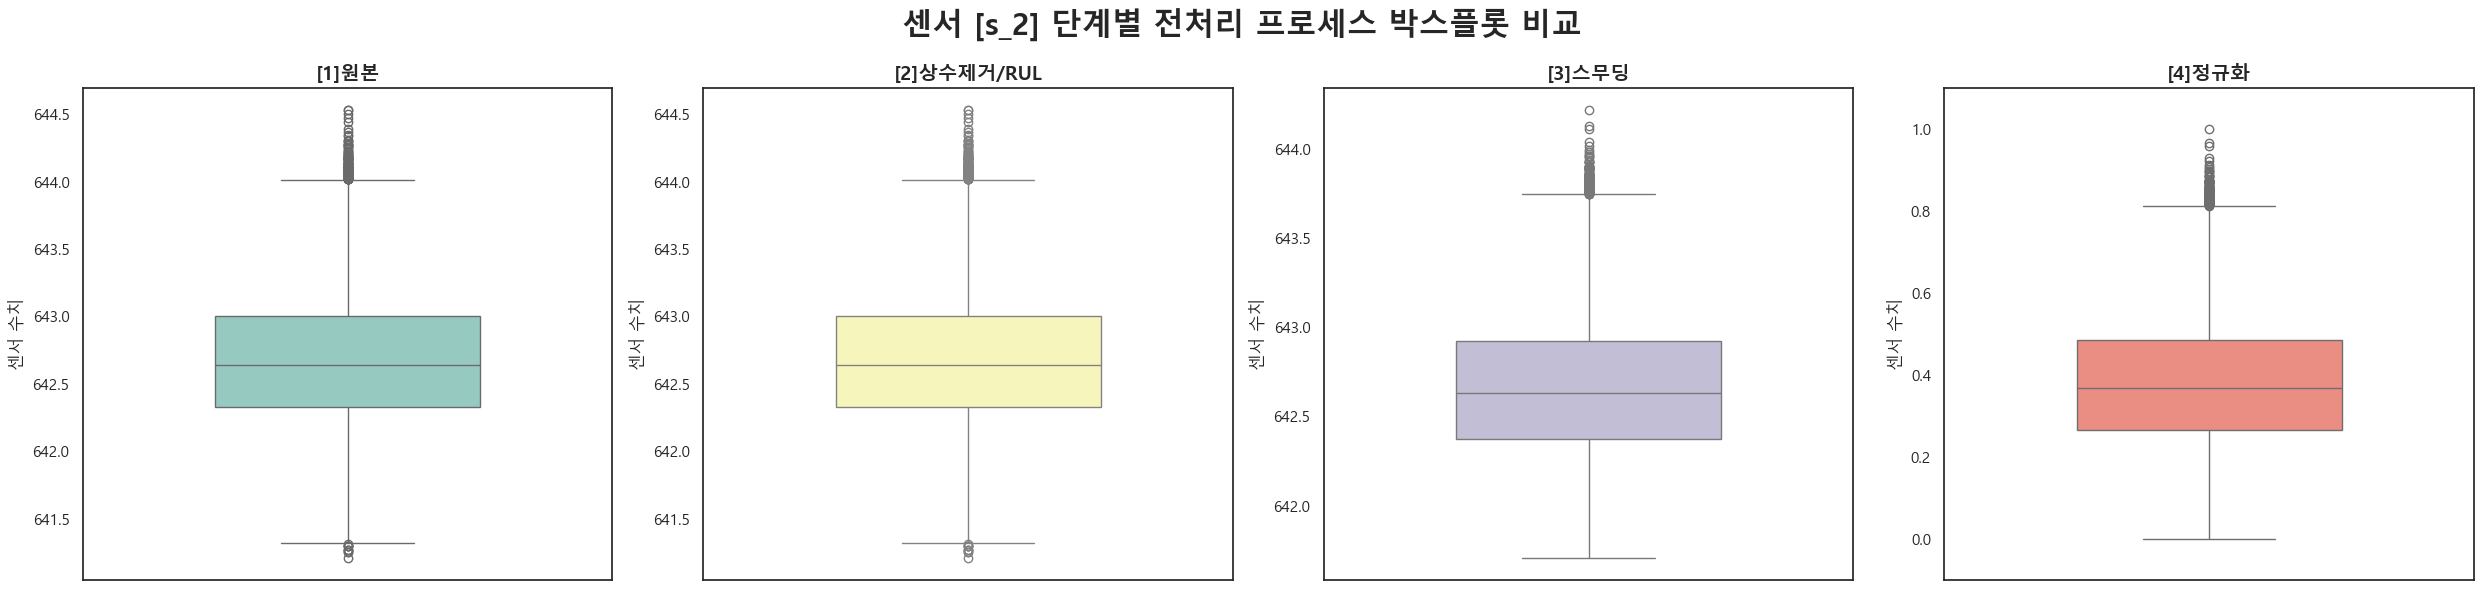

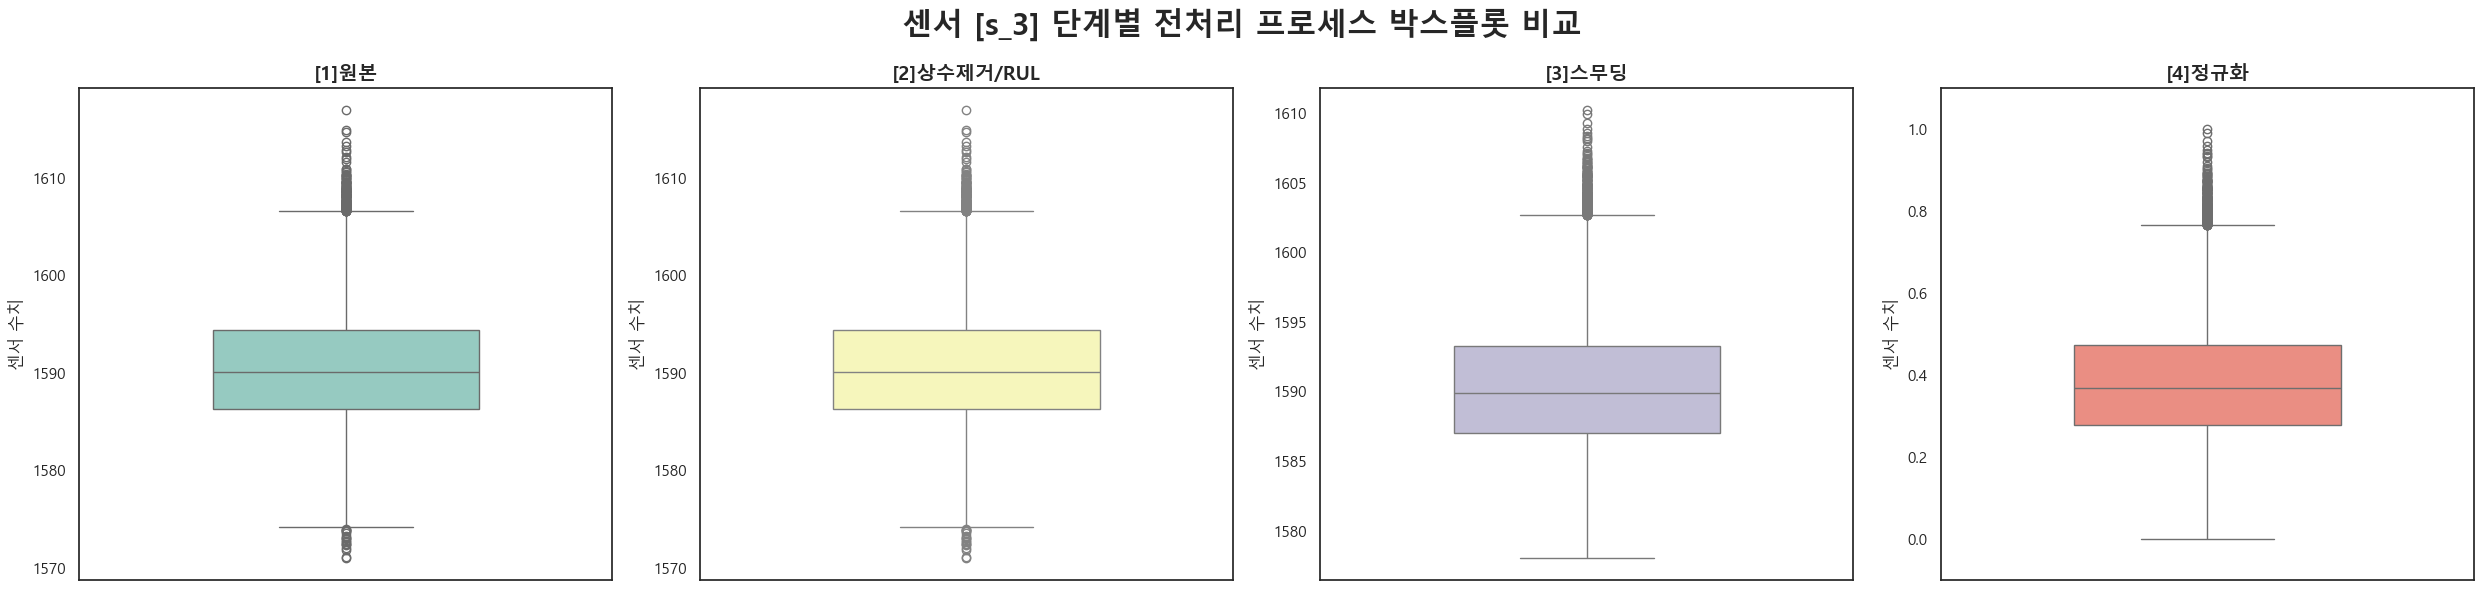

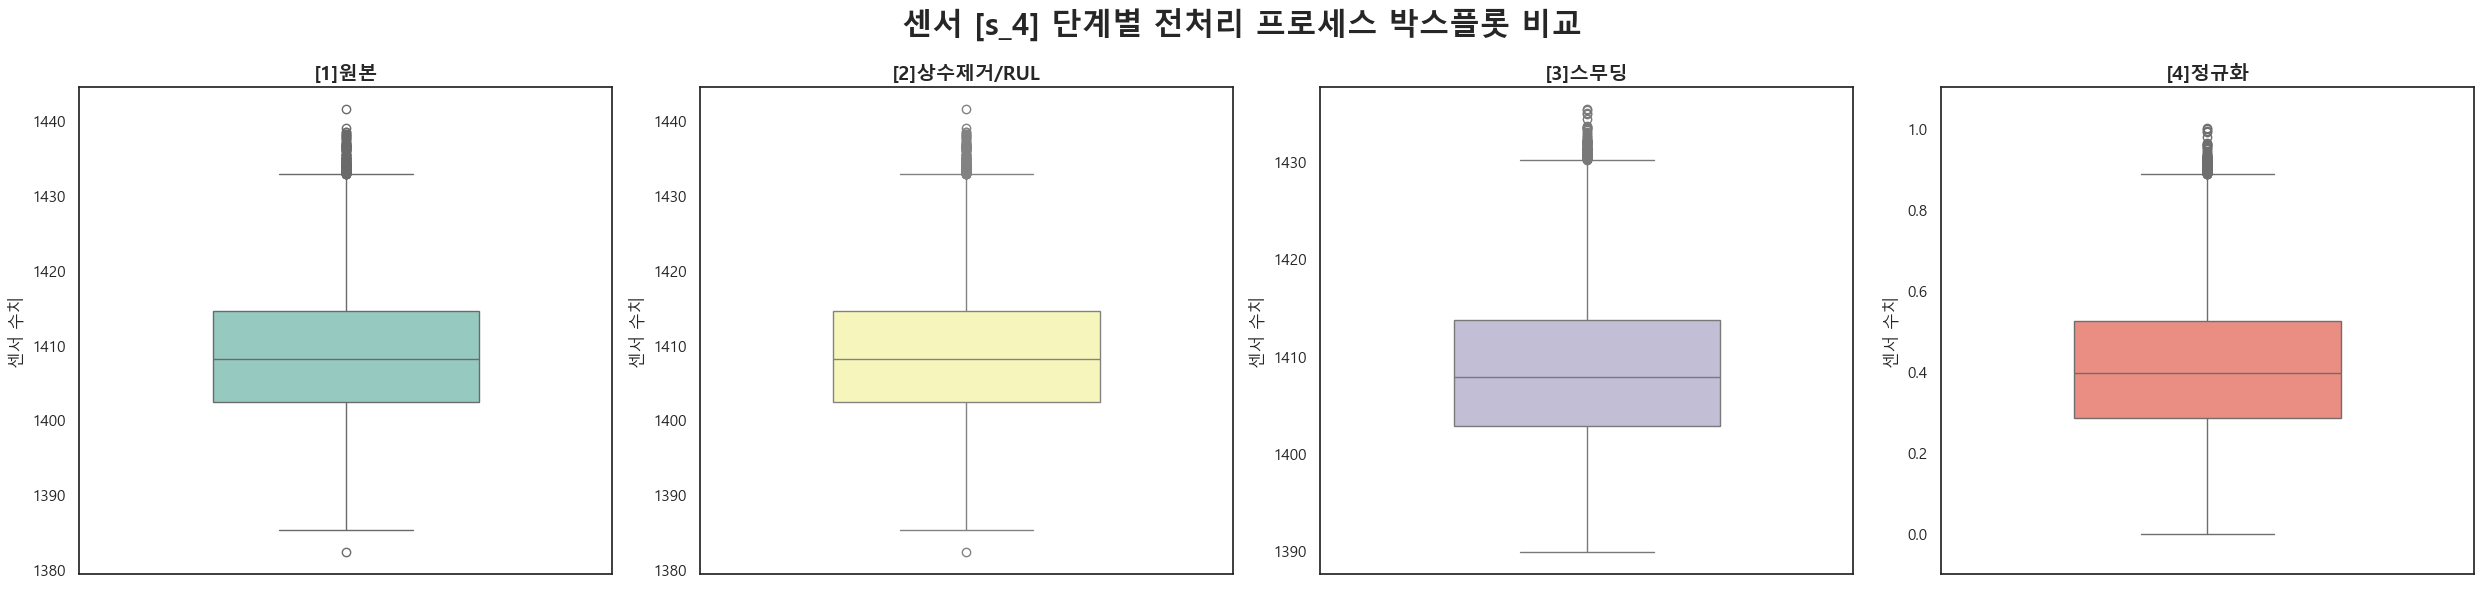

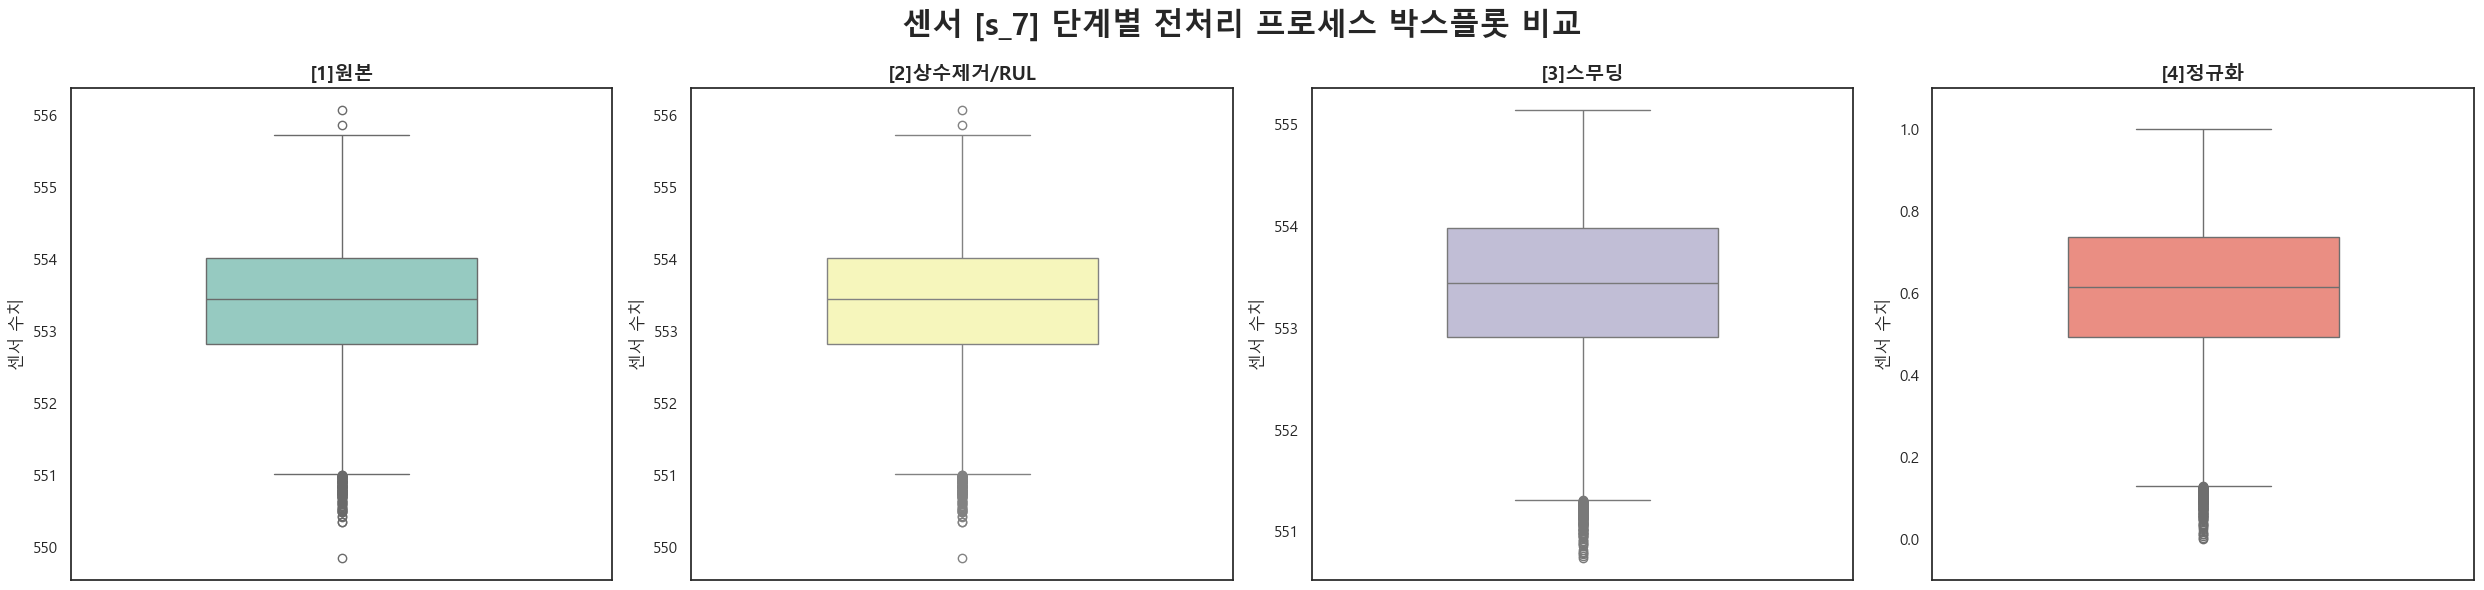

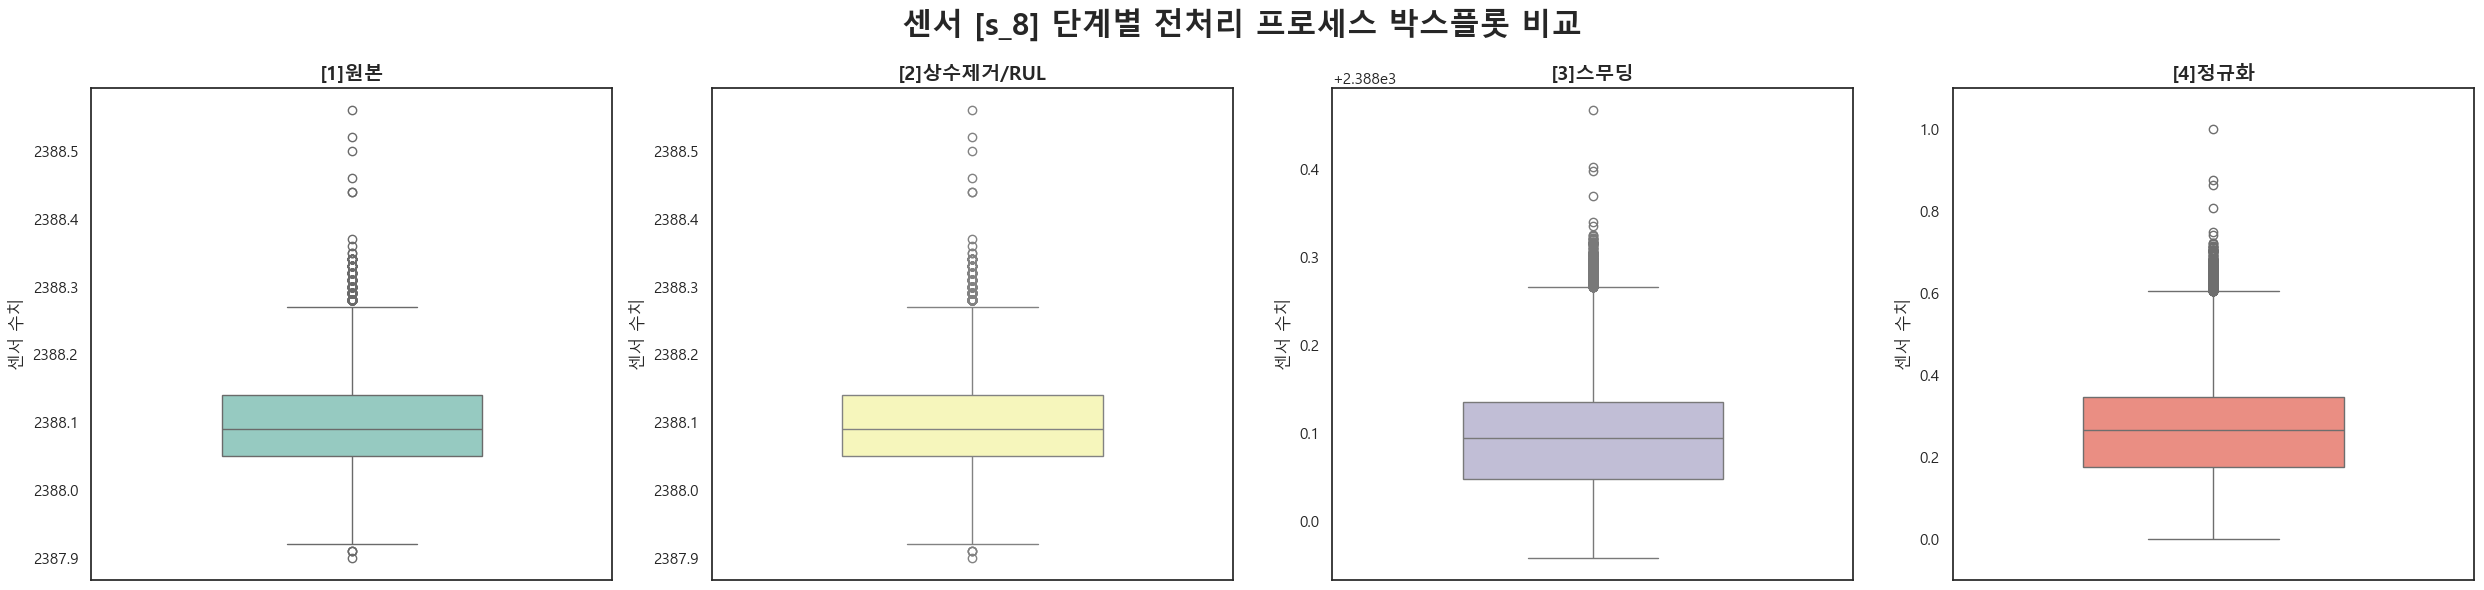

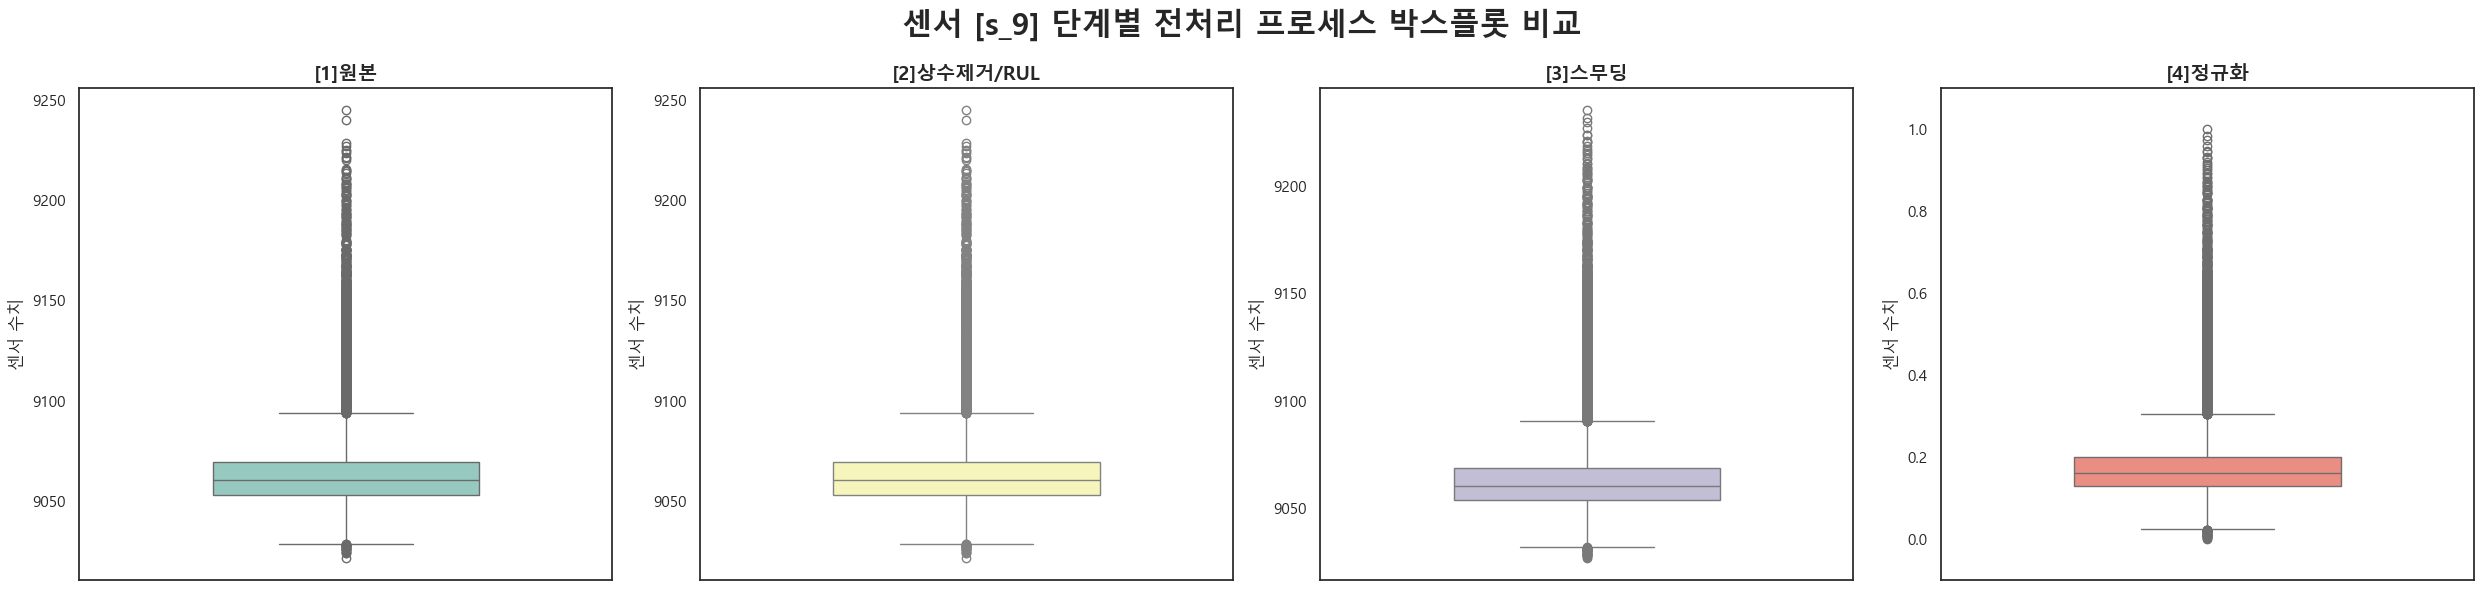

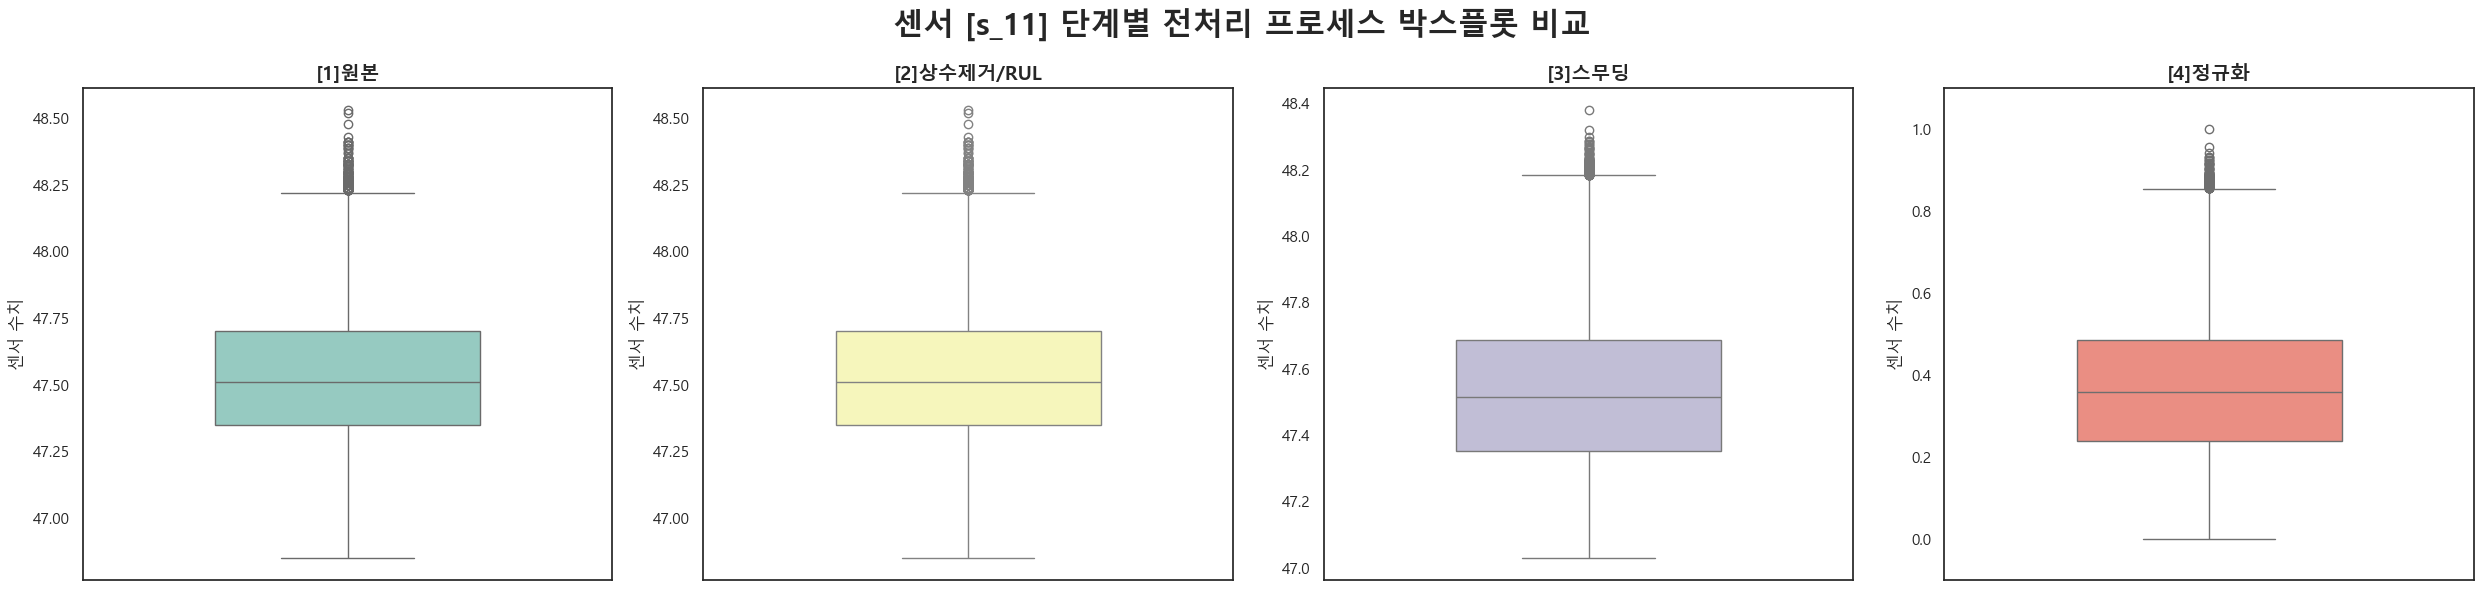

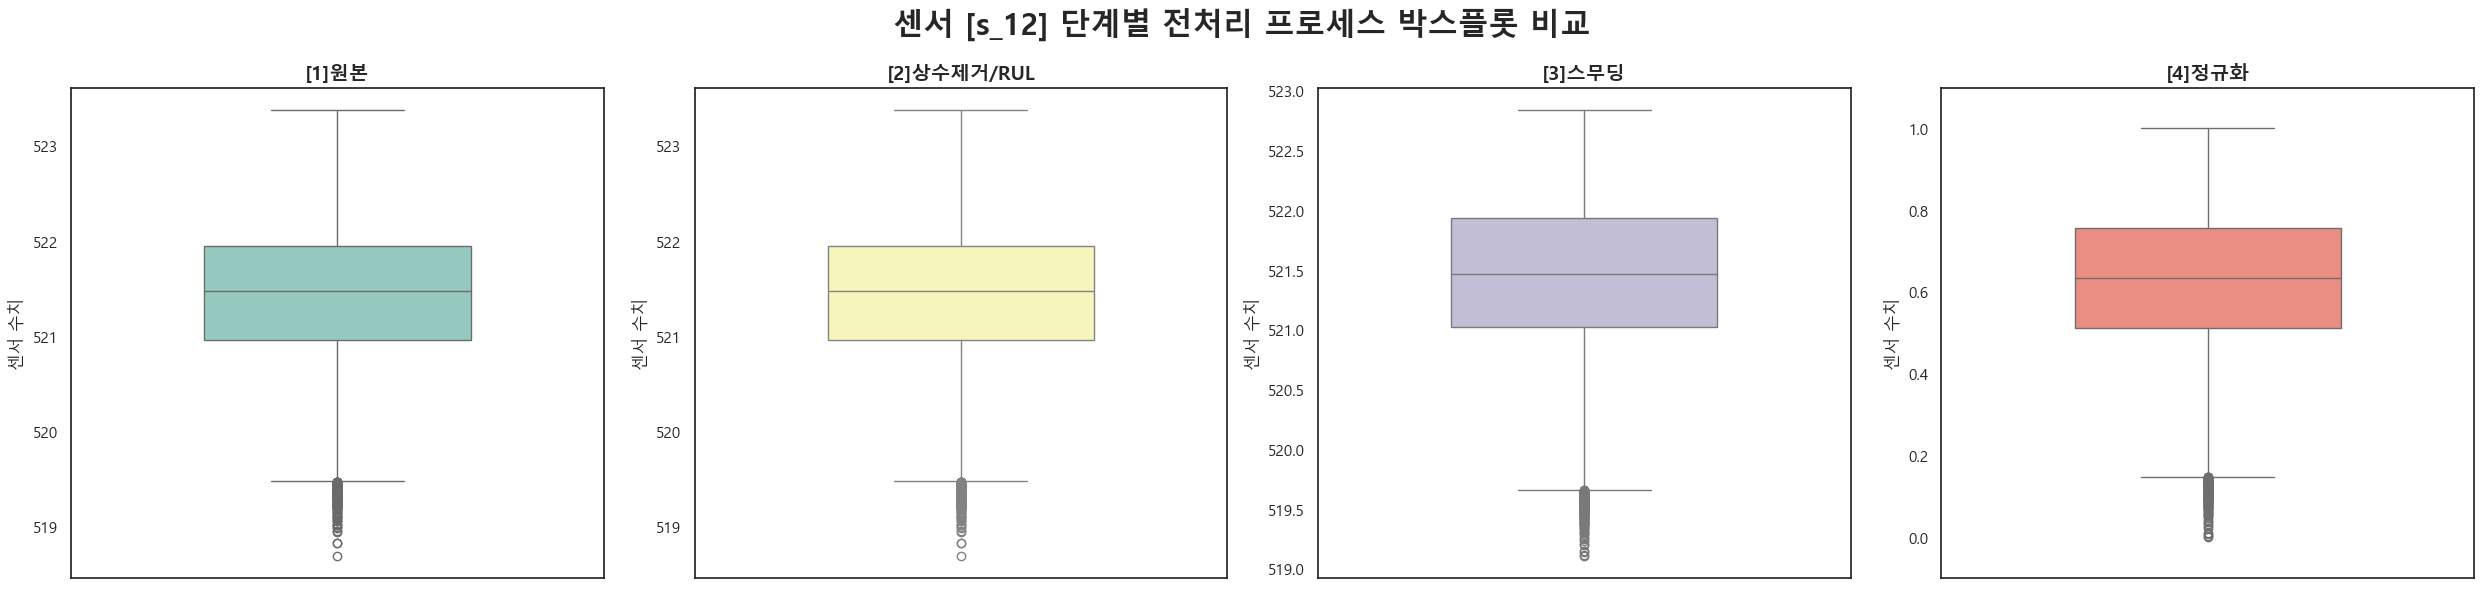

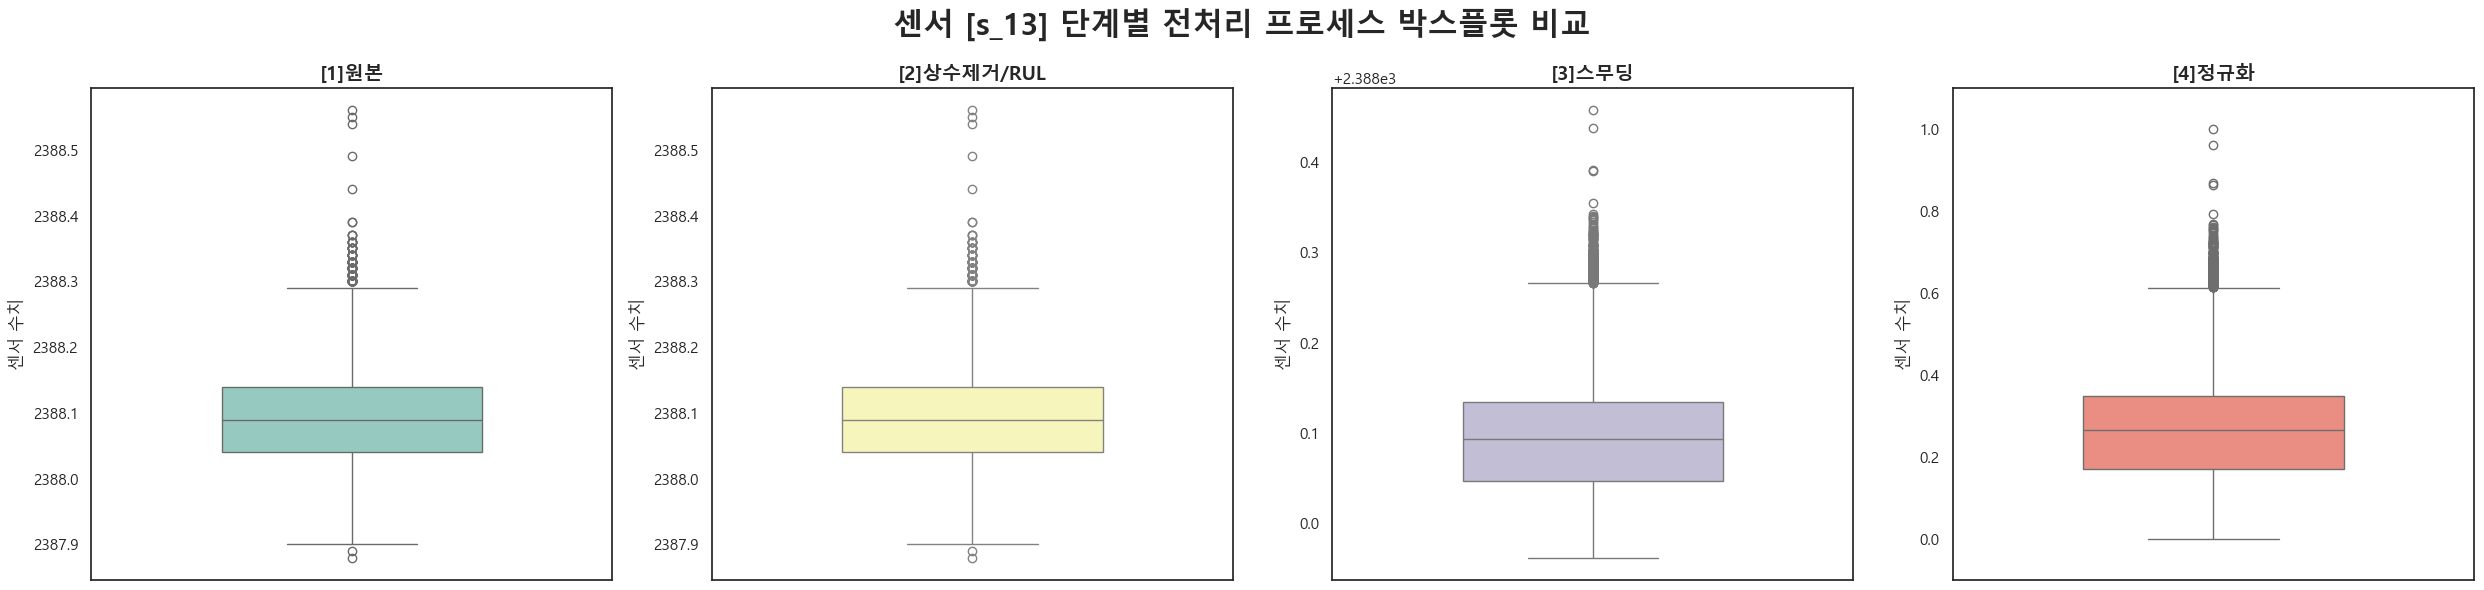

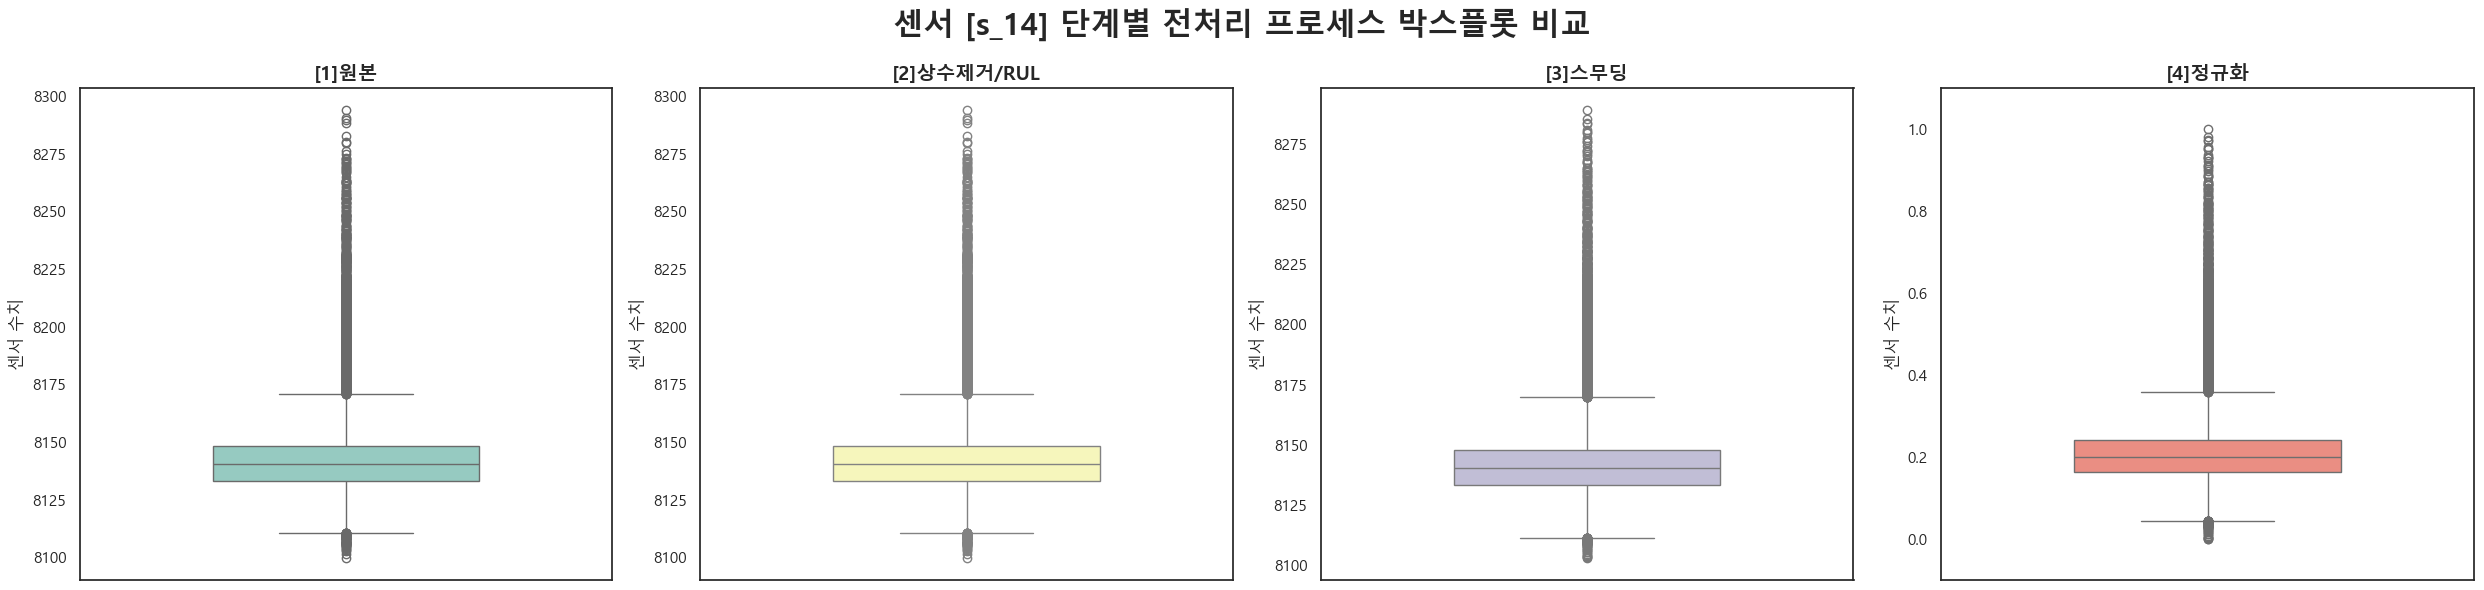

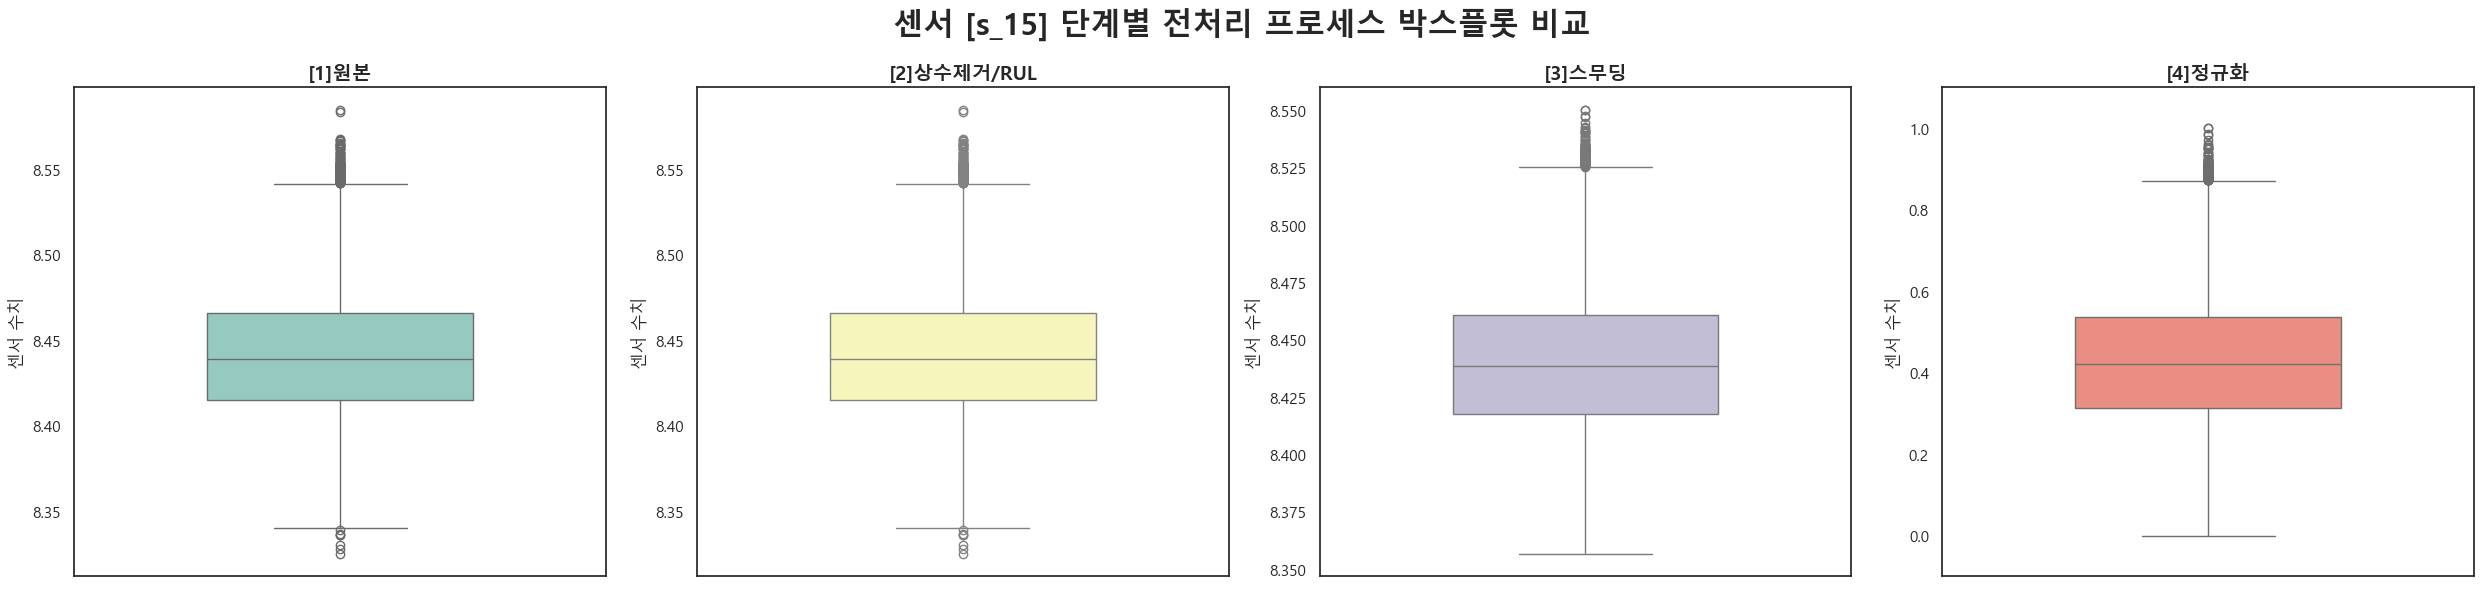

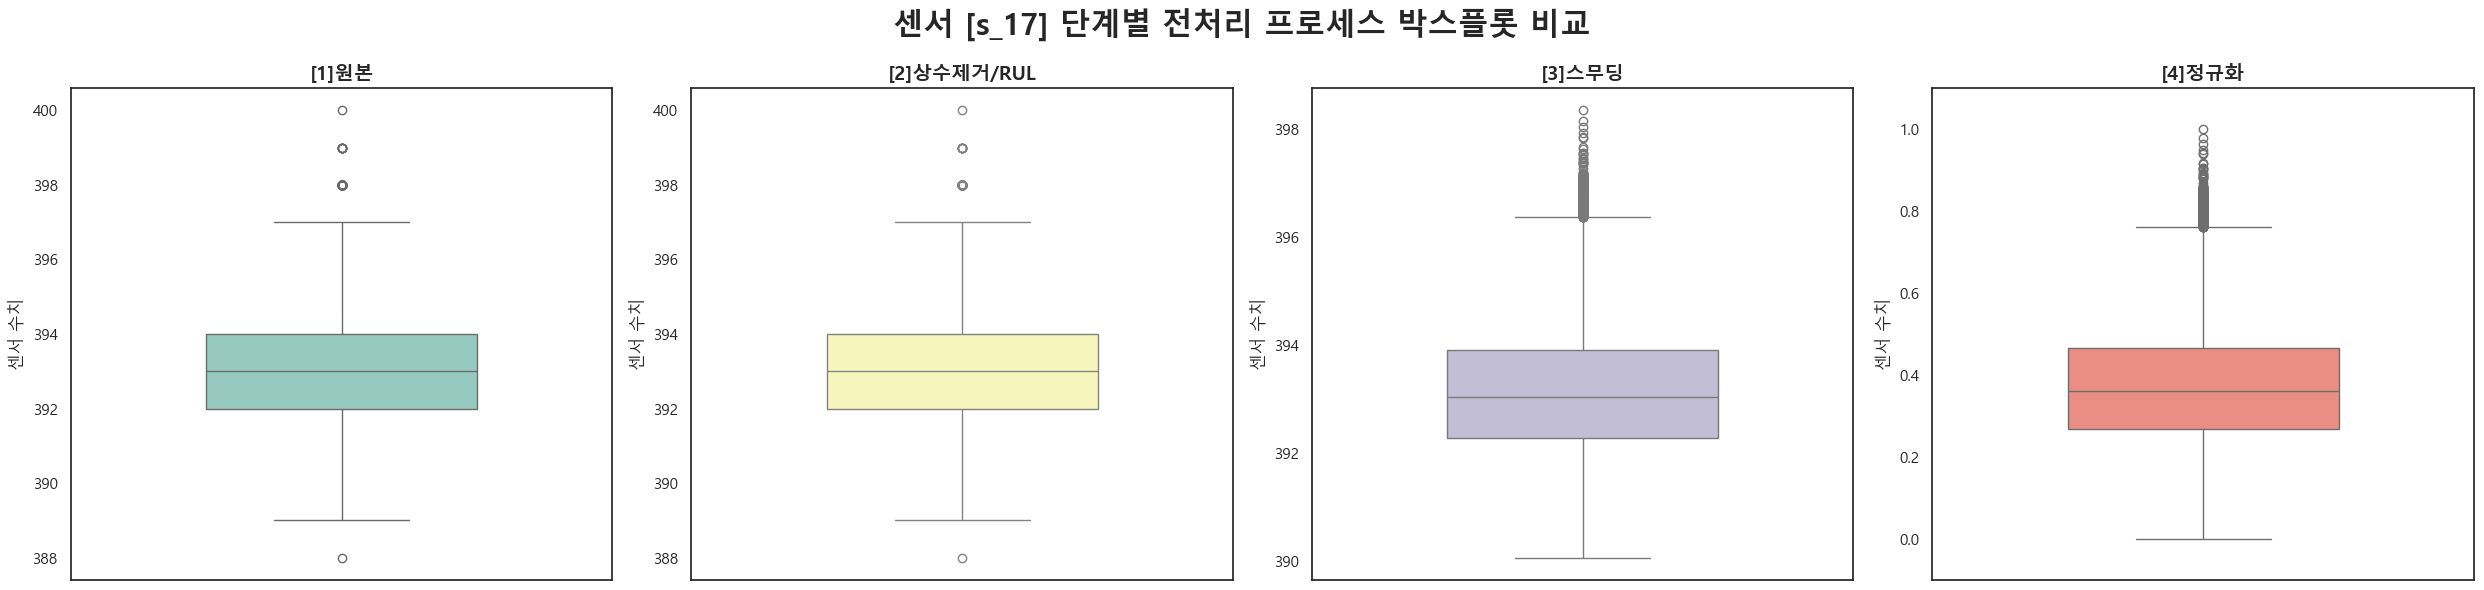

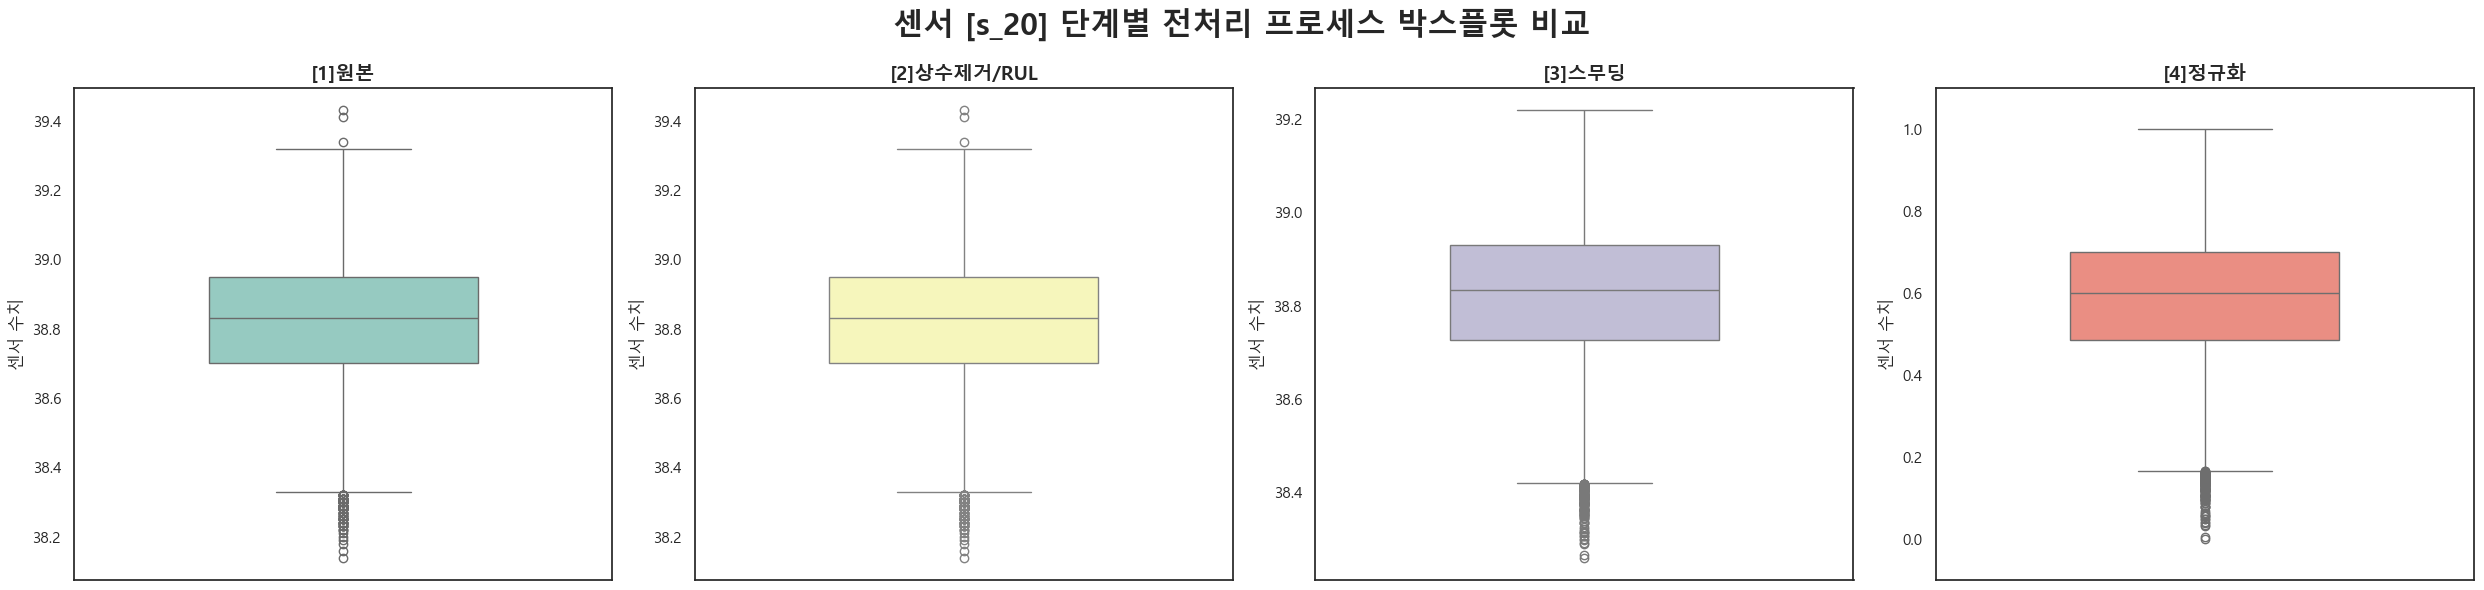

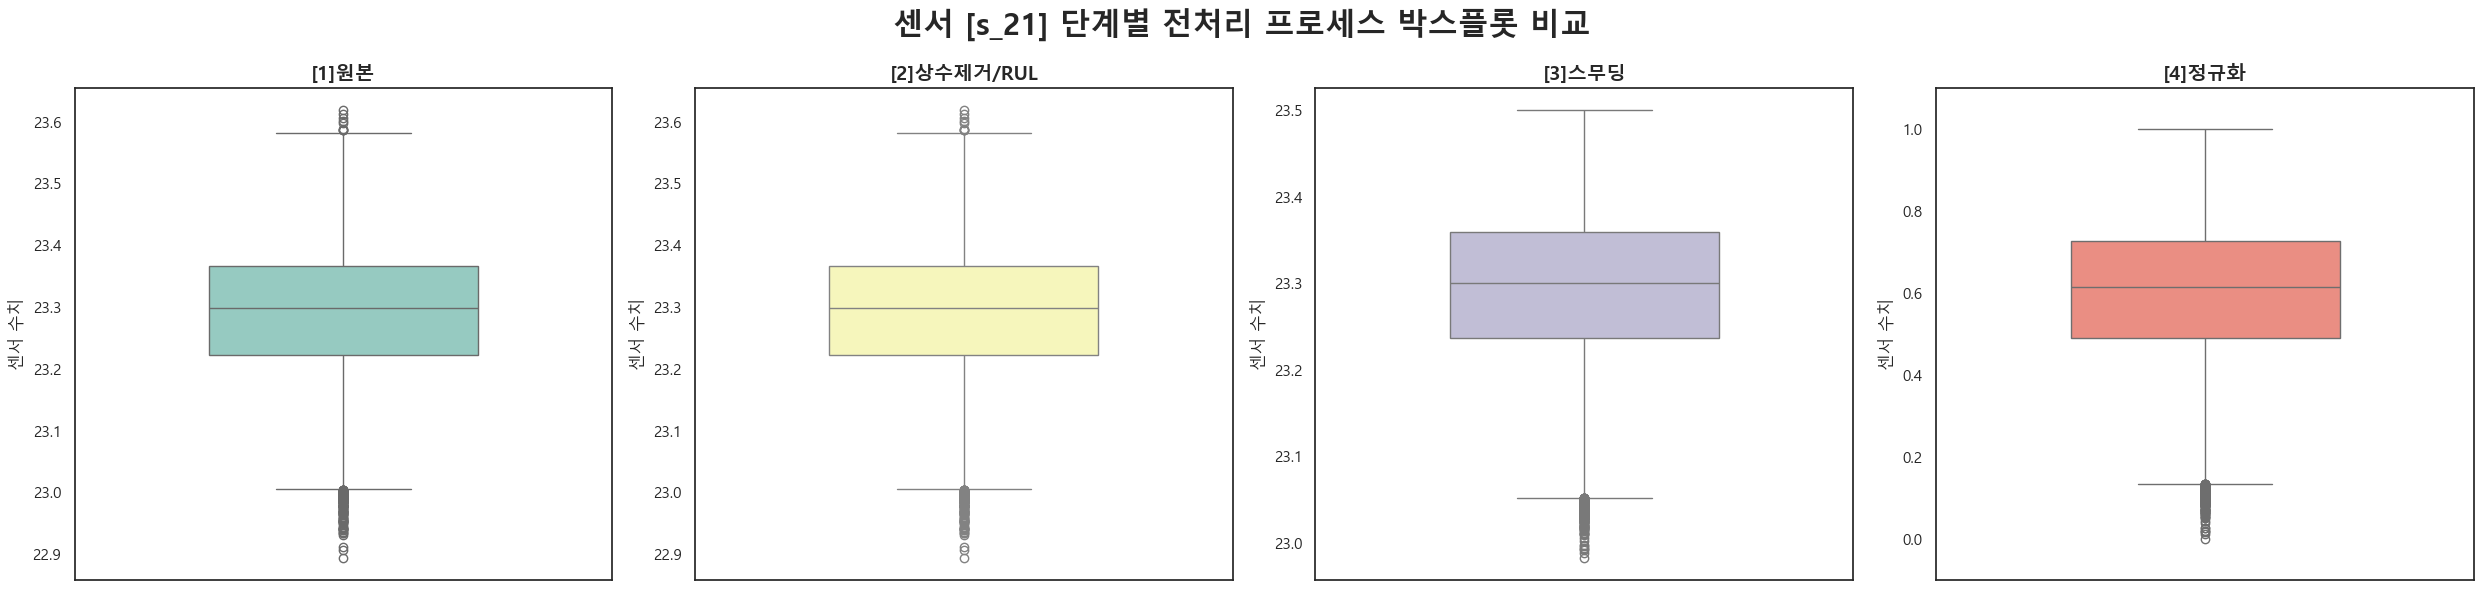

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler

# 1. 환경 설정 및 데이터 로드
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="white", font='Malgun Gothic')

# 데이터 로드 함수 (DATA_PATH는 본인 환경에 맞게 정의되어 있어야 합니다 ㅋ)
def load_cmapss_data(data_id='FD001'):
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
    test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
    rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])
    return train, test, rul

df_train, df_test, df_rul = load_cmapss_data('FD001')

# 단계별 데이터 보관용 리스트 및 센서 설정
steps = []
sensor_names = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

# ---------------------------------------------------------
# [Step 1] 원본 데이터 저장
# ---------------------------------------------------------
steps.append(df_train.copy())

# ---------------------------------------------------------
# [Step 2] 상수 제거 & RUL Capping
# ---------------------------------------------------------
df_train['max_cycle'] = df_train.groupby('unit_nr')['time_cycles'].transform('max')
df_train['RUL'] = (df_train['max_cycle'] - df_train['time_cycles']).clip(upper=125)
df_train.drop(columns=['max_cycle'], inplace=True)

const_cols = ['setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
df_train = df_train.drop(columns=const_cols)
df_test = df_test.drop(columns=const_cols)

steps.append(df_train.copy())

# ---------------------------------------------------------
# [Step 3] 가우시안 스무딩 (팀원 코드 스타일 적용 ㅋ)
# ---------------------------------------------------------
active_sensors = [c for c in df_train.columns if c.startswith('s_')]
GAUSS_SIGMA = 2.0

def apply_gaussian_team_style(df, features, sigma=GAUSS_SIGMA):
    # 팀원 스타일: 정렬 및 인덱스 리셋 ㅋ
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    
    # 팀원 스타일: 루프를 통한 엔진별 처리 ㅋ
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            # 팀원 스타일: mode='nearest' 적용으로 끝단 왜곡 방지 ㅋ
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

df_train = apply_gaussian_team_style(df_train, active_sensors)
df_test = apply_gaussian_team_style(df_test, active_sensors)

steps.append(df_train.copy())

# ---------------------------------------------------------
# [Step 4] MinMax 정규화
# ---------------------------------------------------------
features_to_scale = active_sensors
scaler = MinMaxScaler()

df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

steps.append(df_train.copy())
print("✅ 팀원 스타일 반영 전처리 완료!")

# ==========================================================
# 📊 [시각화] 모든 센서별 4단계 박스플롯 분포 변화 출력
# ==========================================================
step_labels = ['[1]원본', '[2]상수제거/RUL', '[3]스무딩', '[4]정규화']

for sensor in sensor_names:
    fig, axes = plt.subplots(1, 4, figsize=(25, 6))
    for i, df_step in enumerate(steps):
        sns.boxplot(y=df_step[sensor], ax=axes[i], 
                    color=sns.color_palette("Set3", 4)[i], width=0.5)
        
        axes[i].set_title(f'{step_labels[i]}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('센서 수치')
        
        if i == 3: # 마지막 정규화 단계 Y축 고정
            axes[i].set_ylim(-0.1, 1.1)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.suptitle(f'센서 [{sensor}] 단계별 전처리 프로세스 박스플롯 비교', fontsize=22, fontweight='bold')
    plt.show()

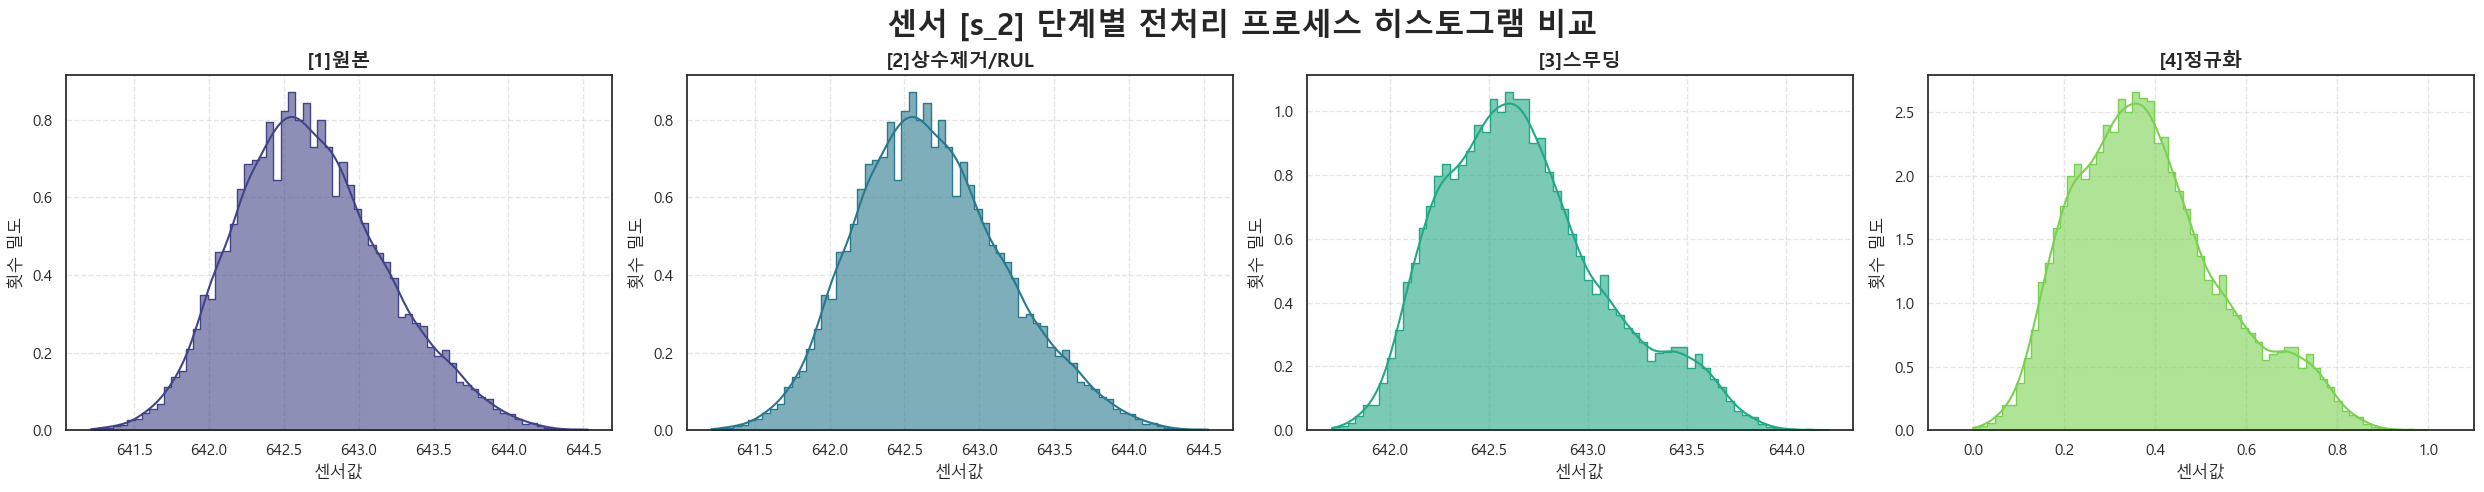

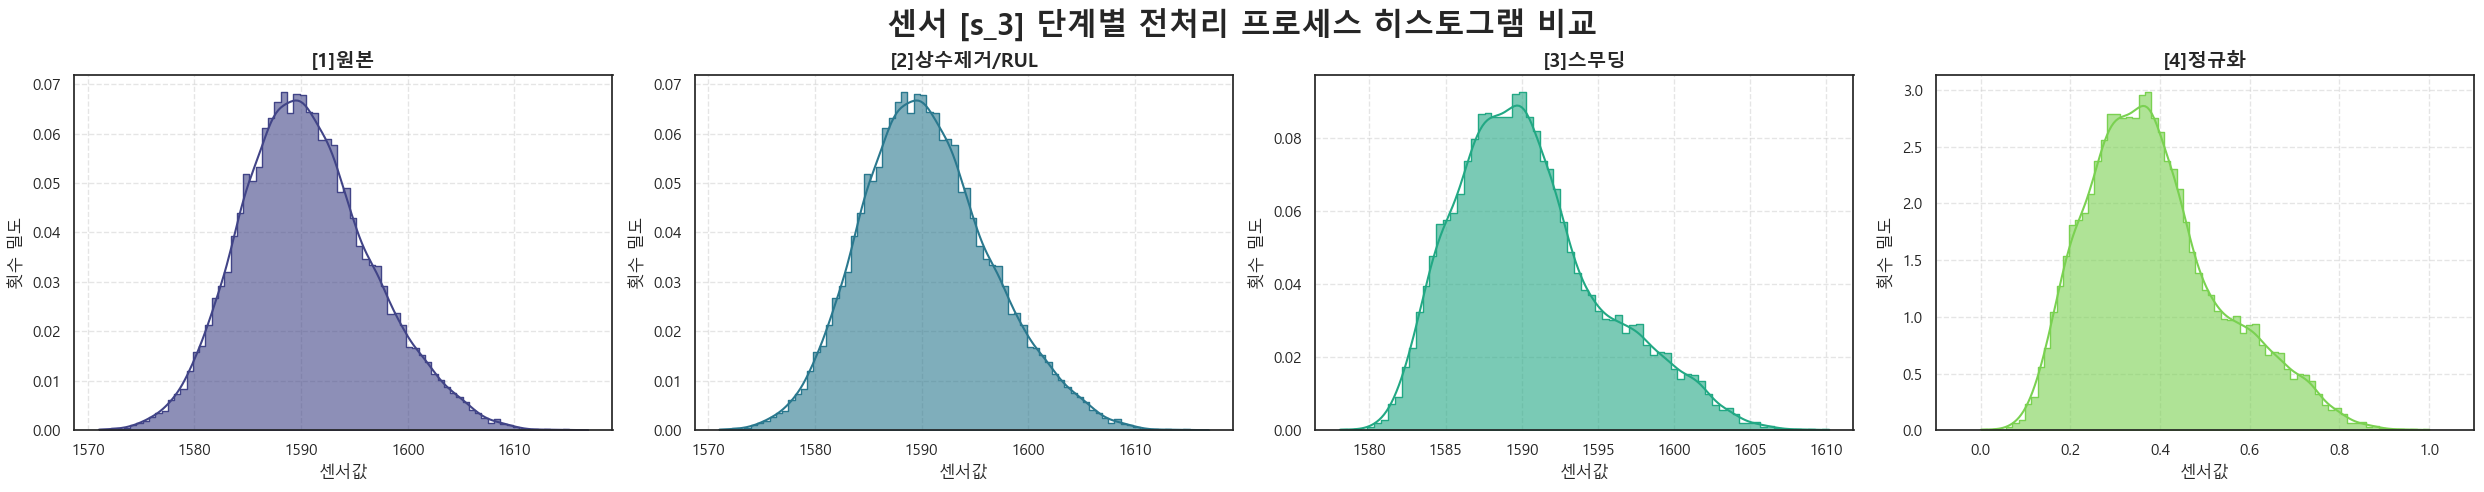

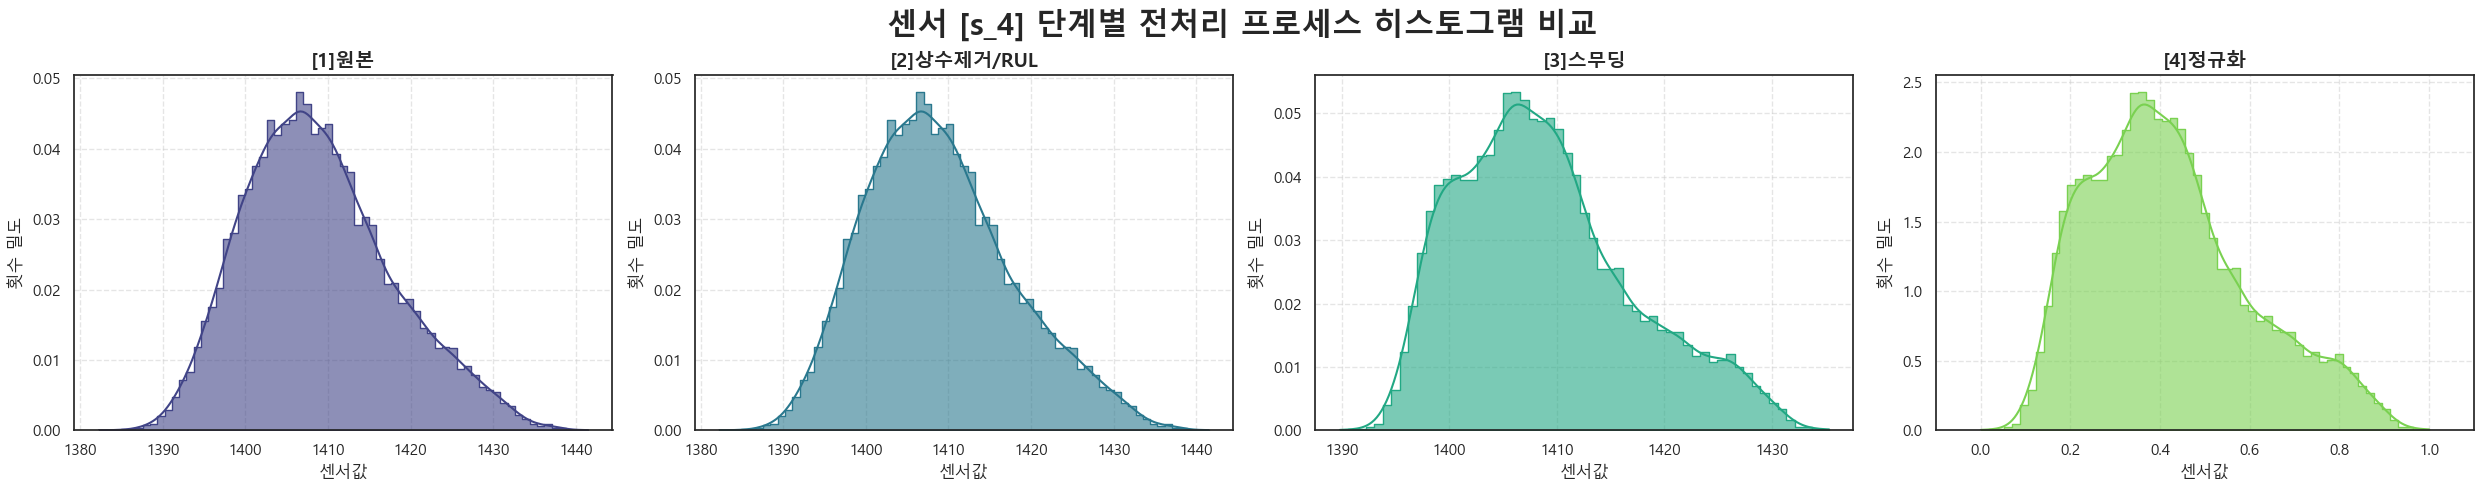

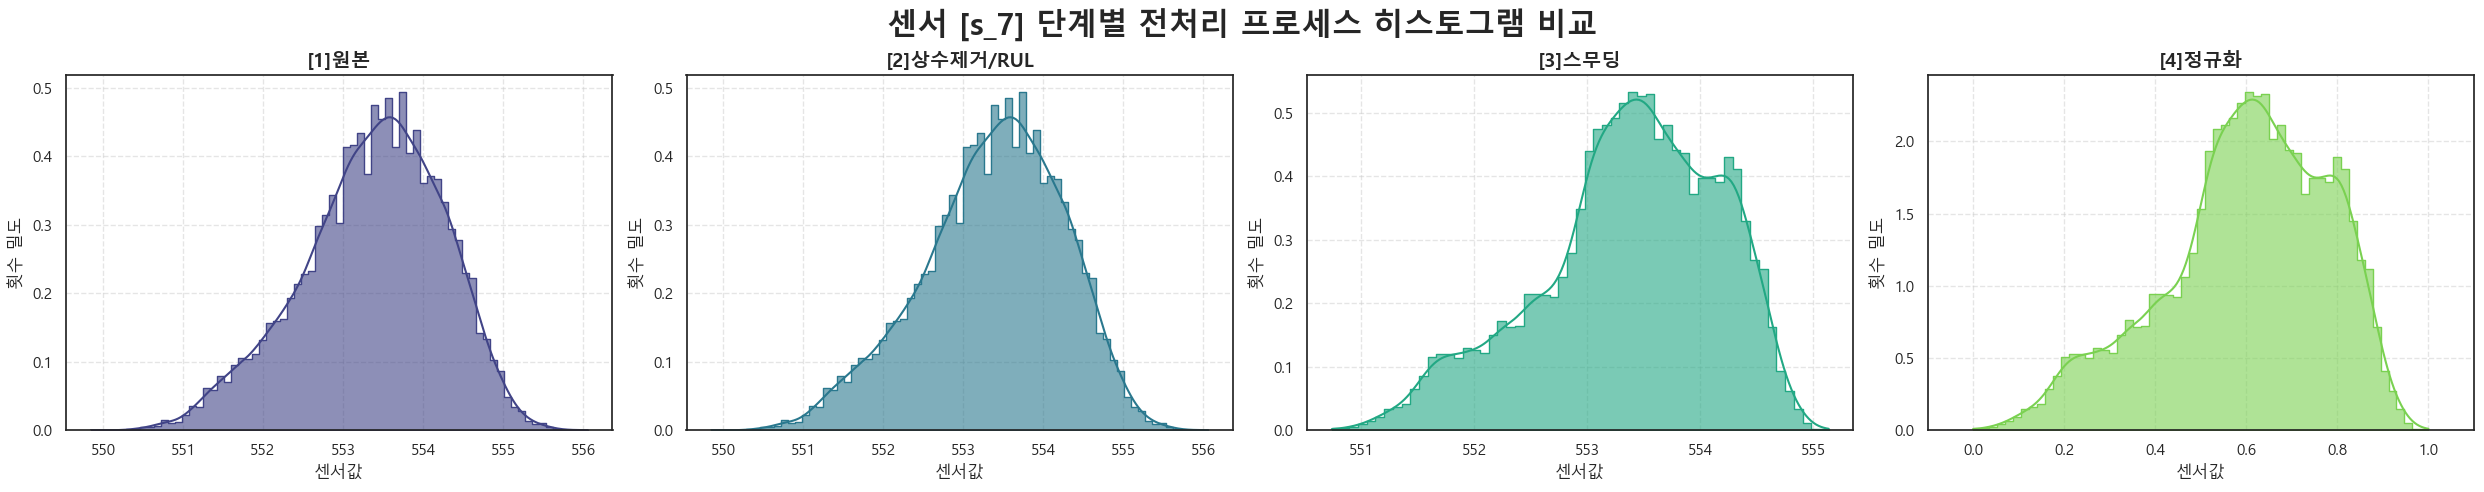

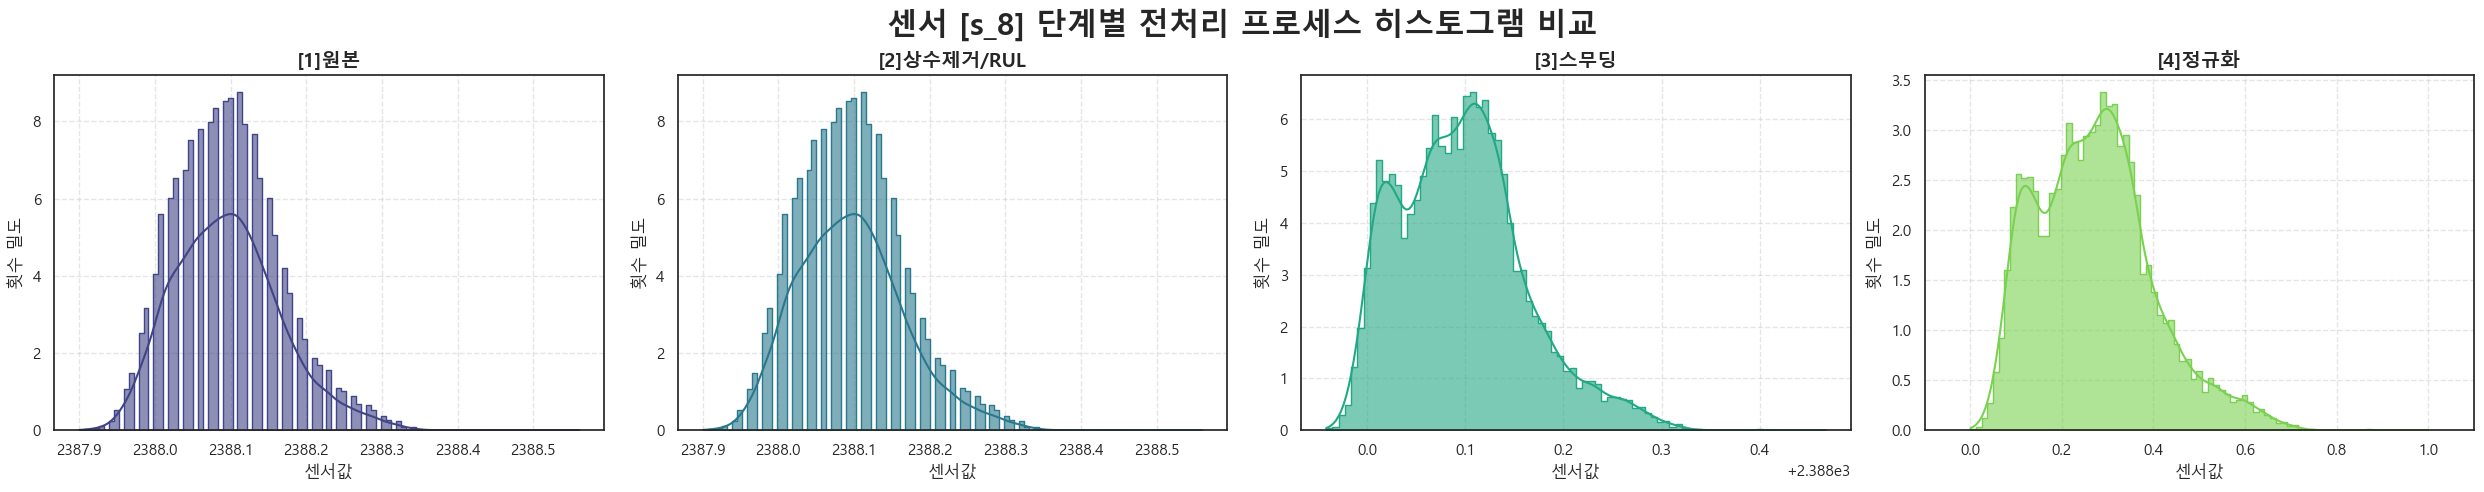

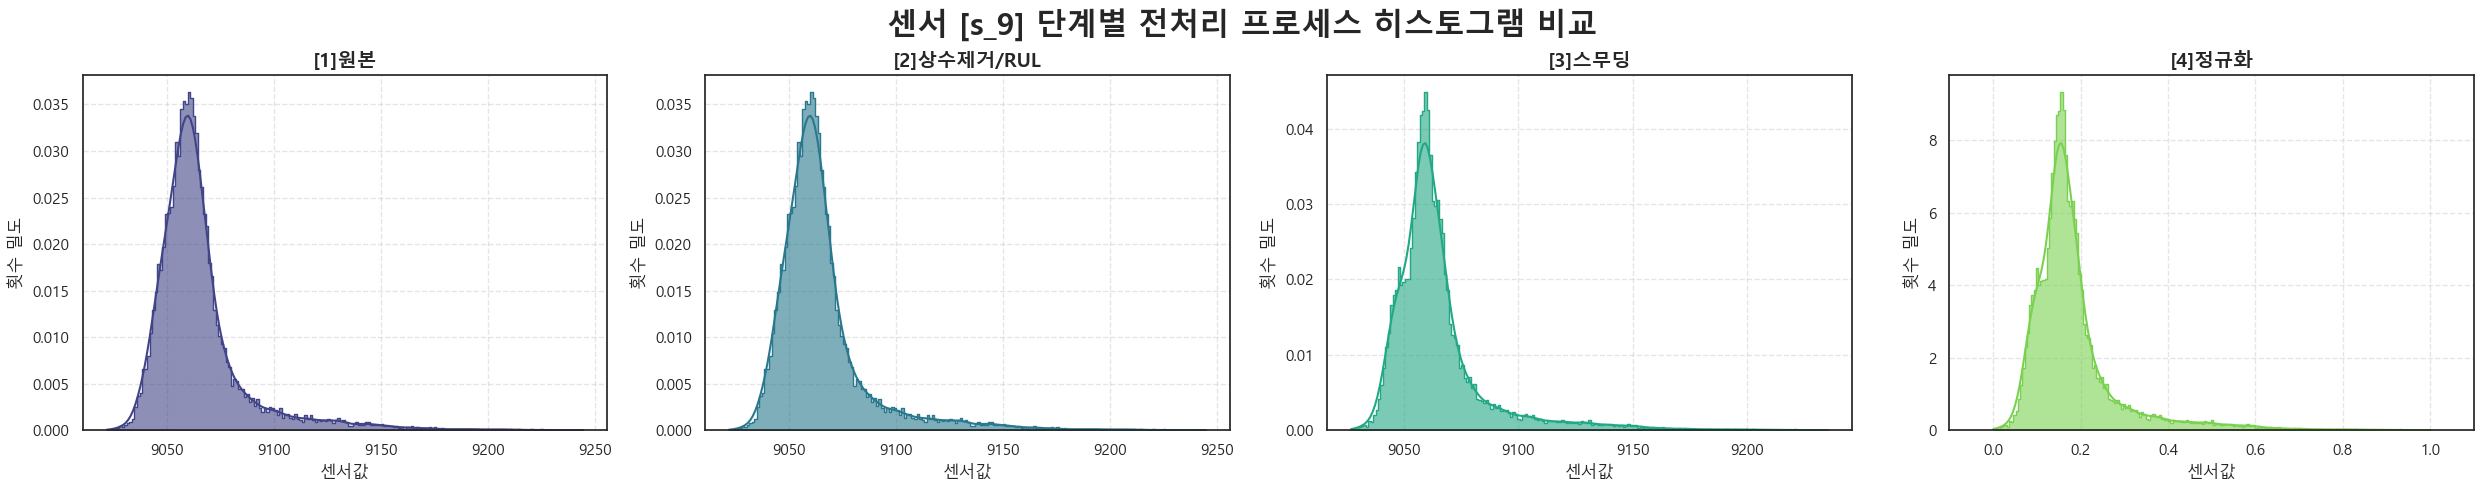

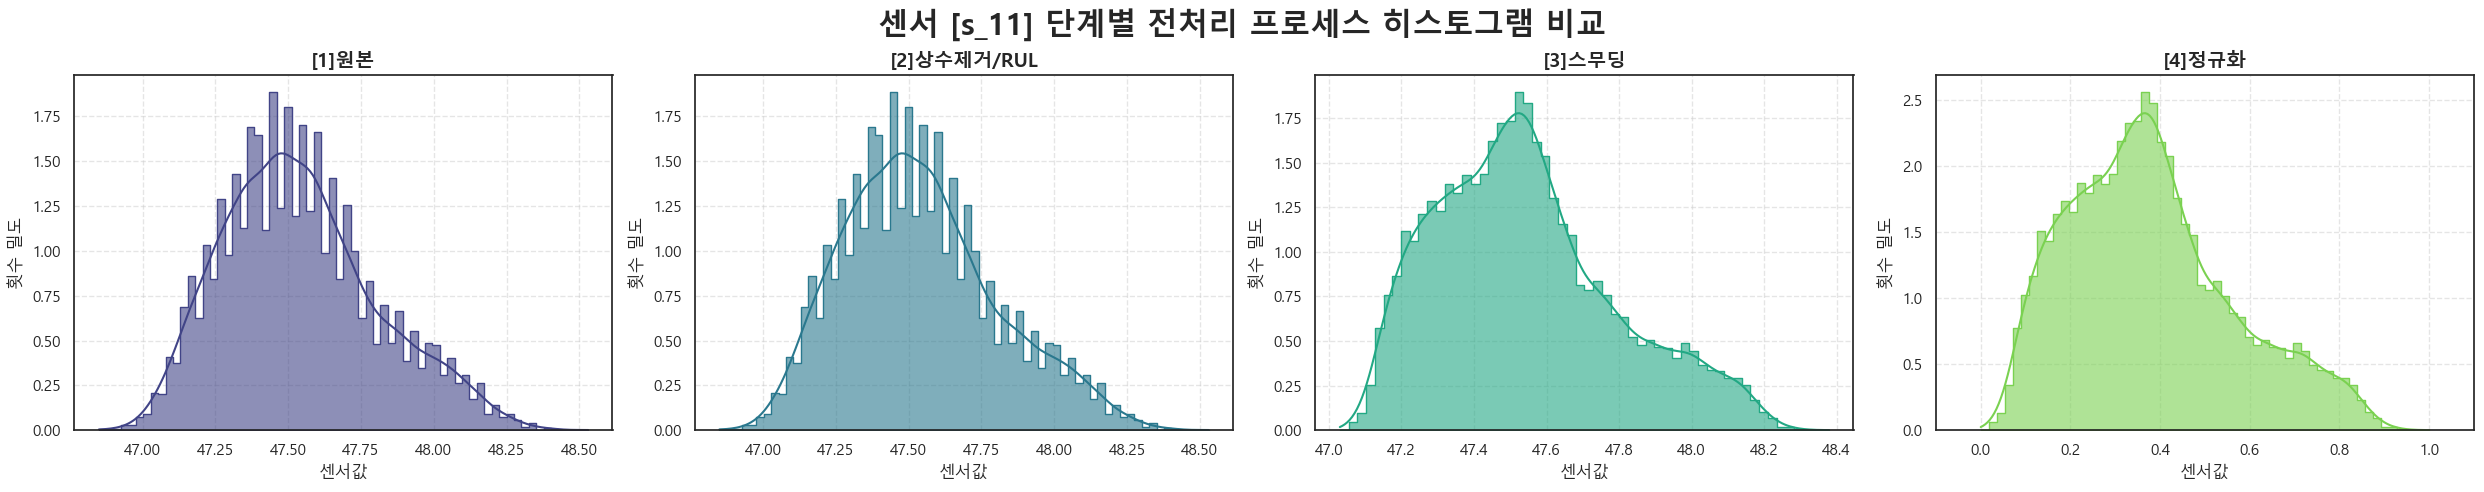

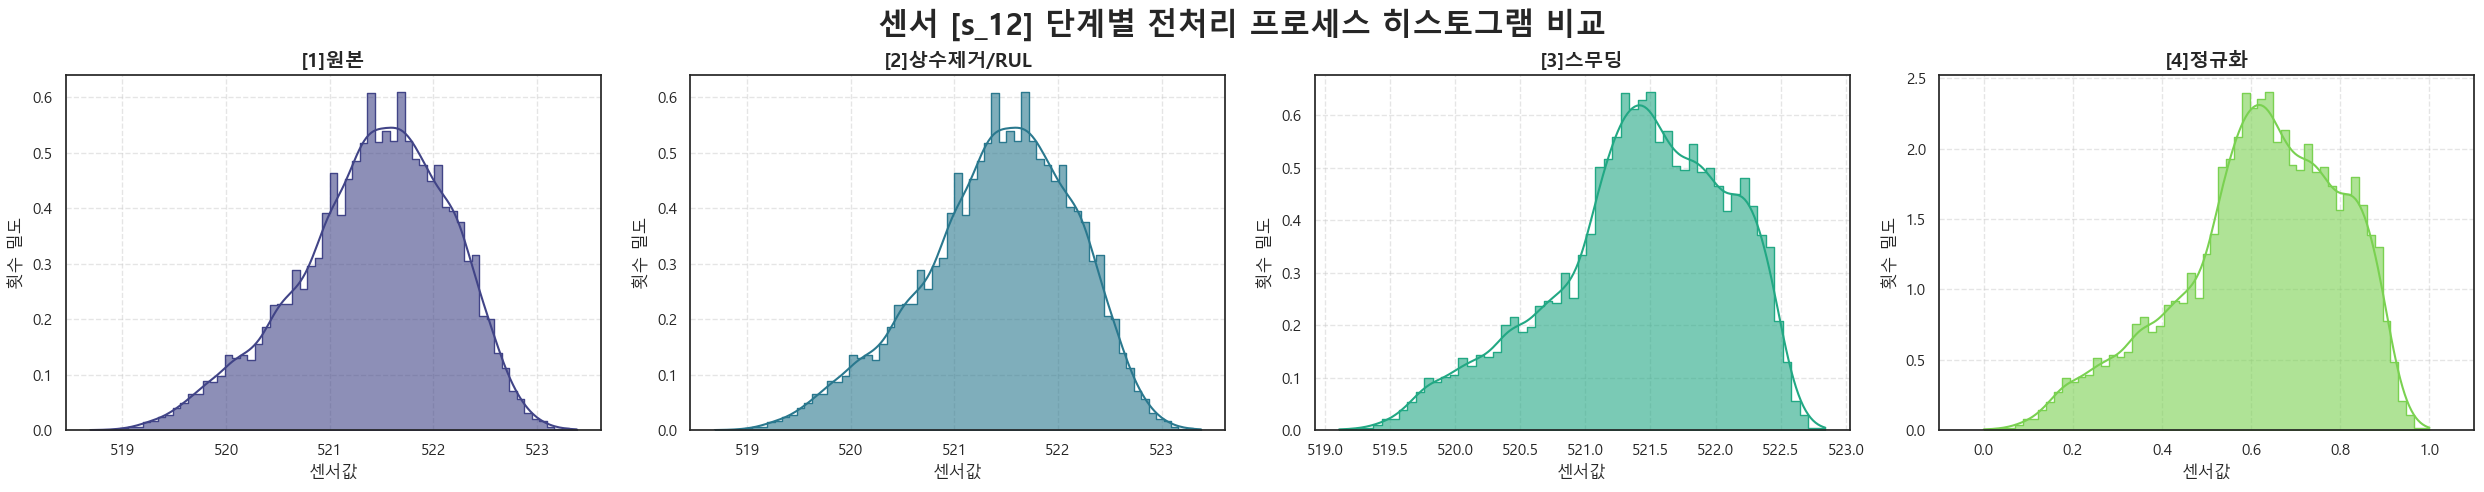

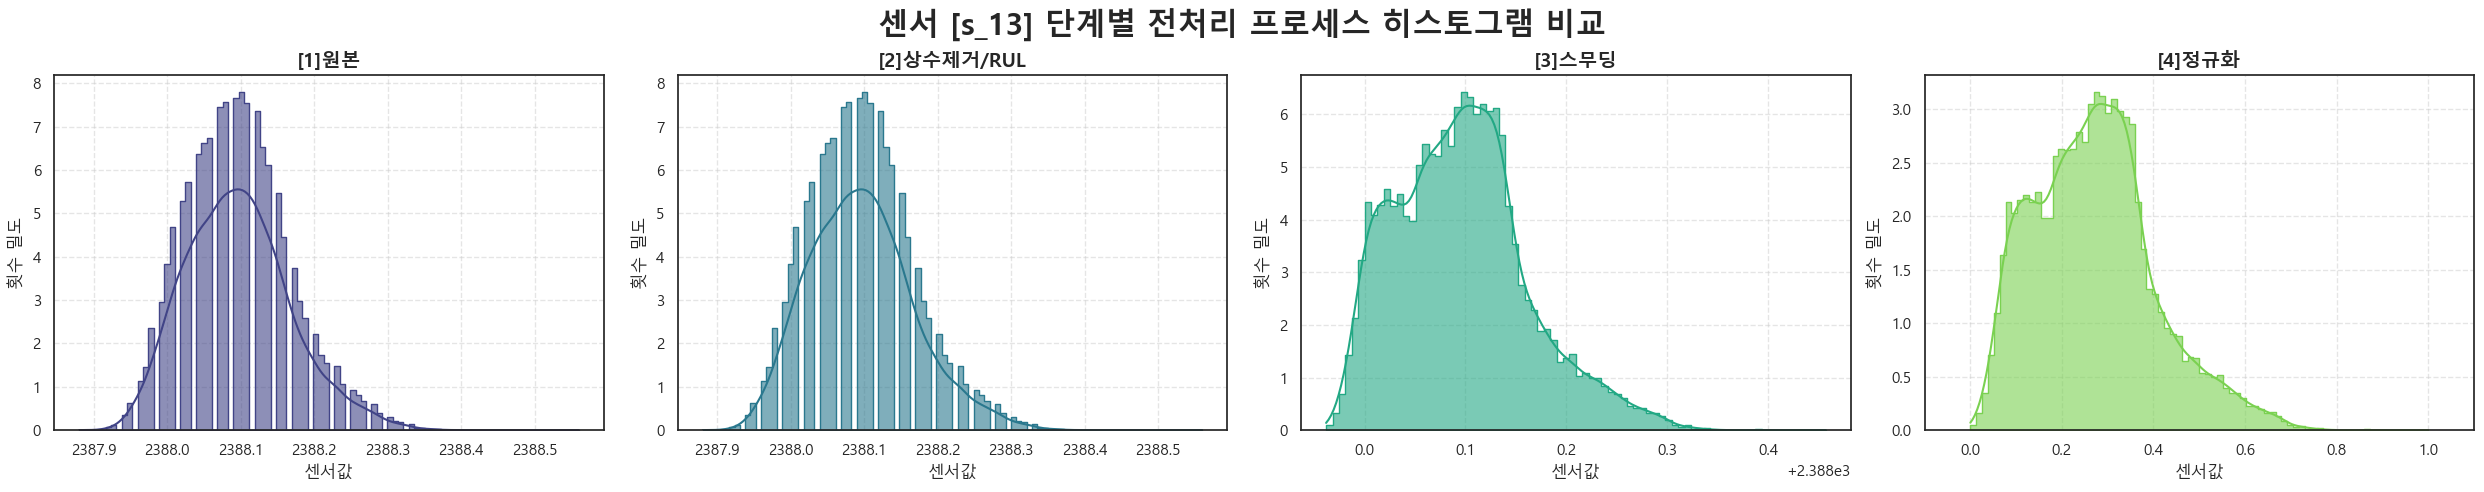

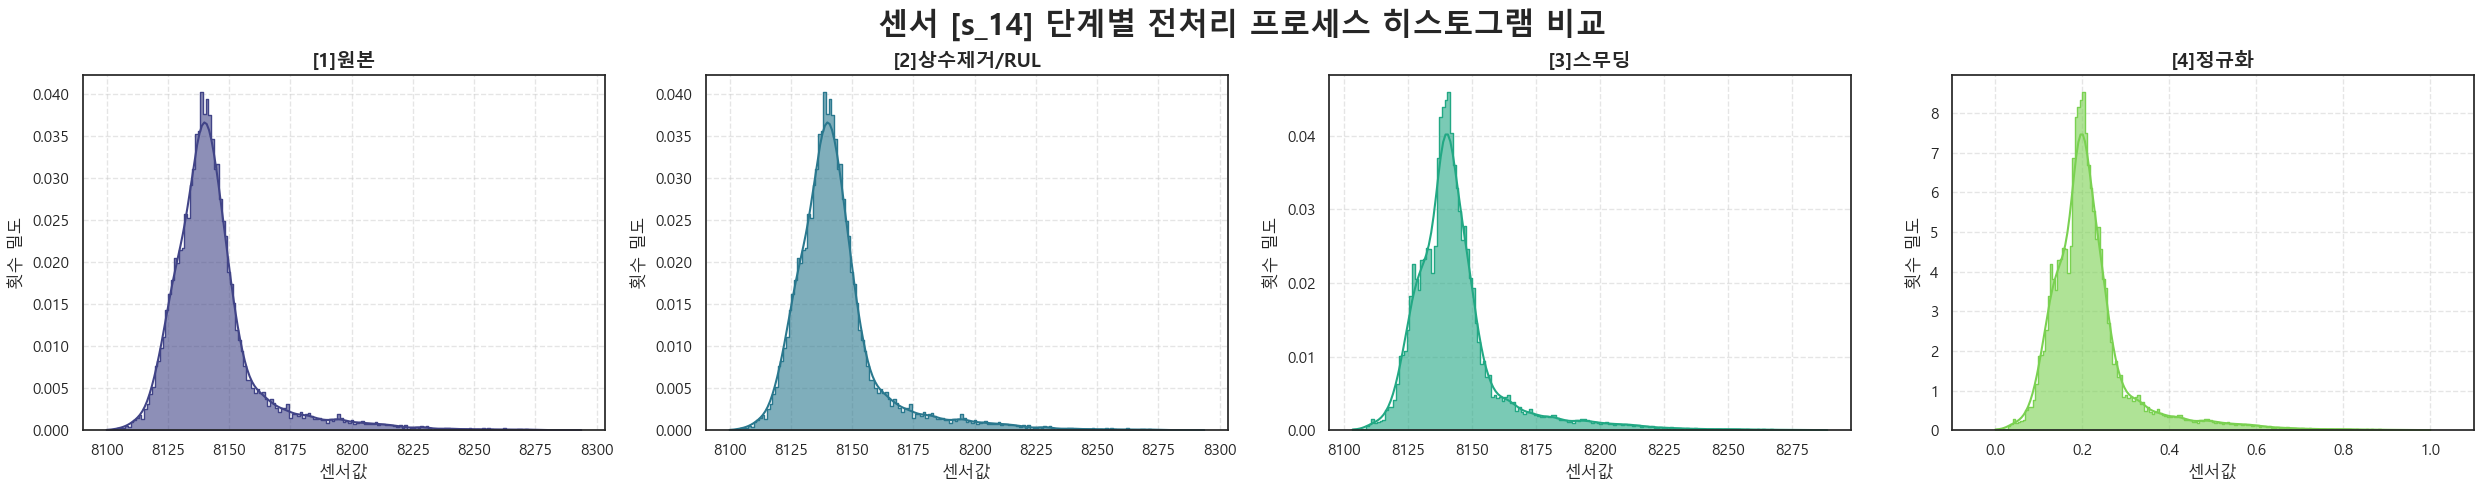

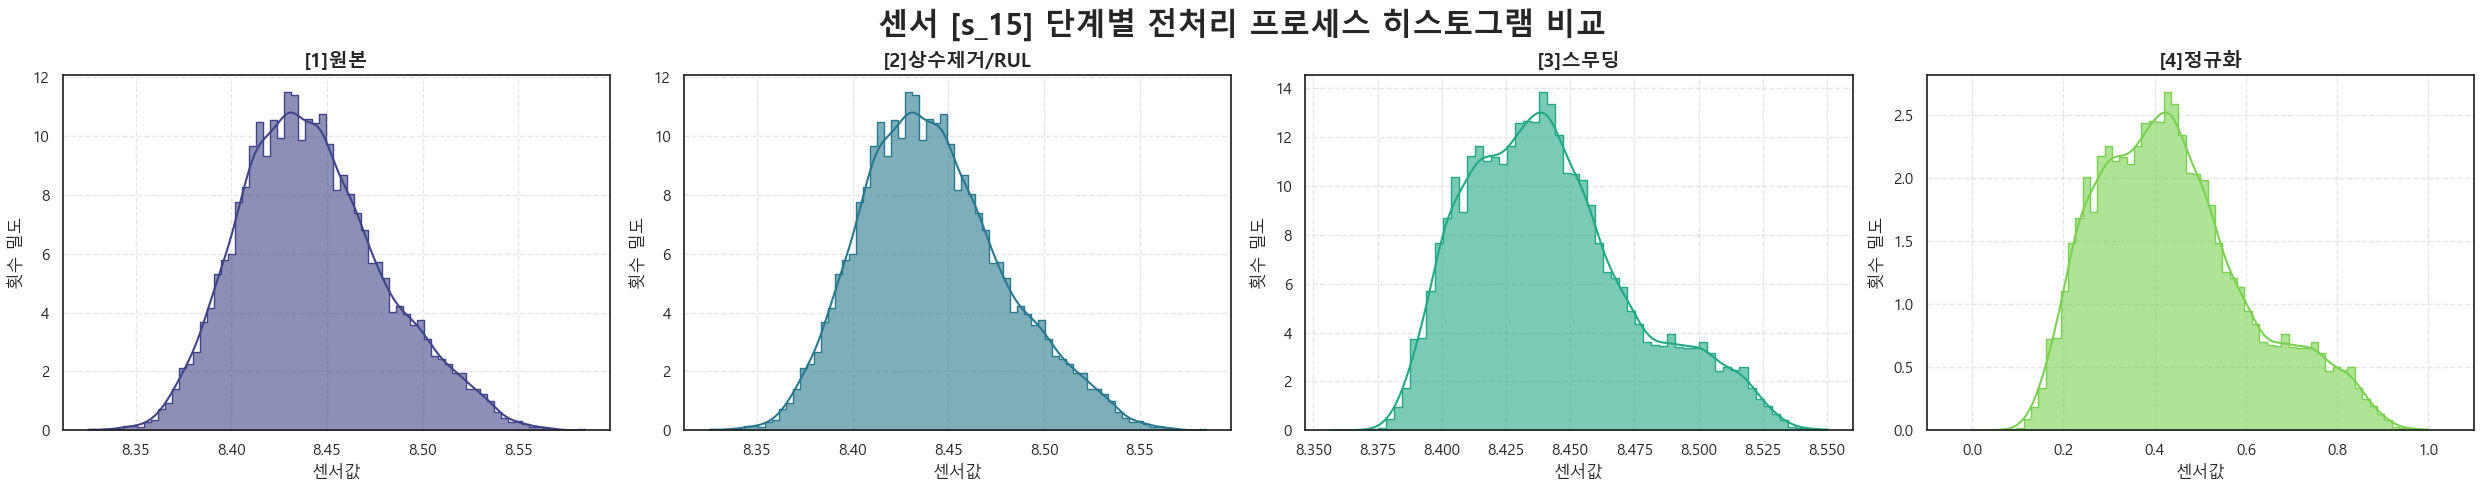

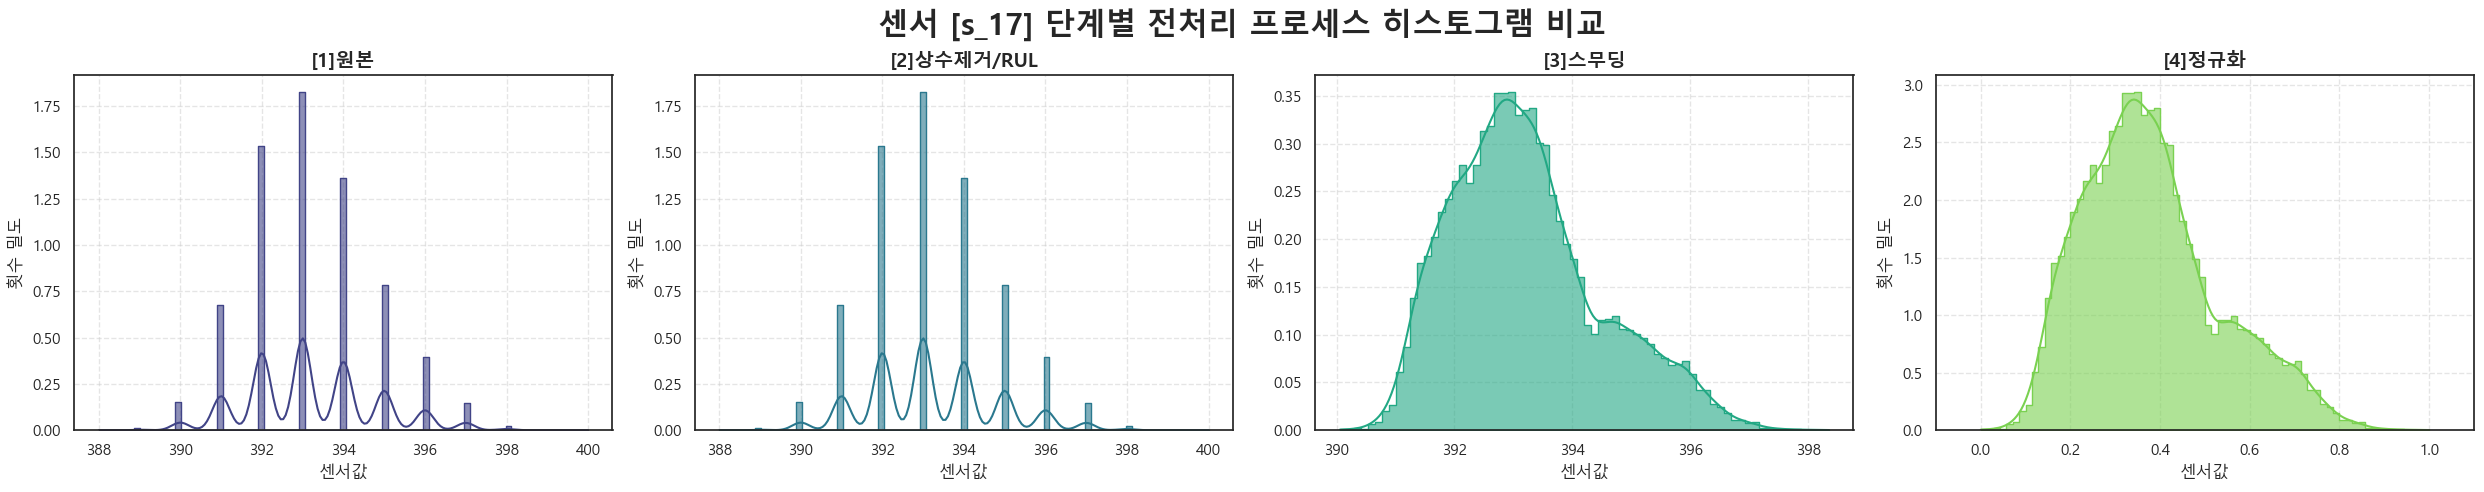

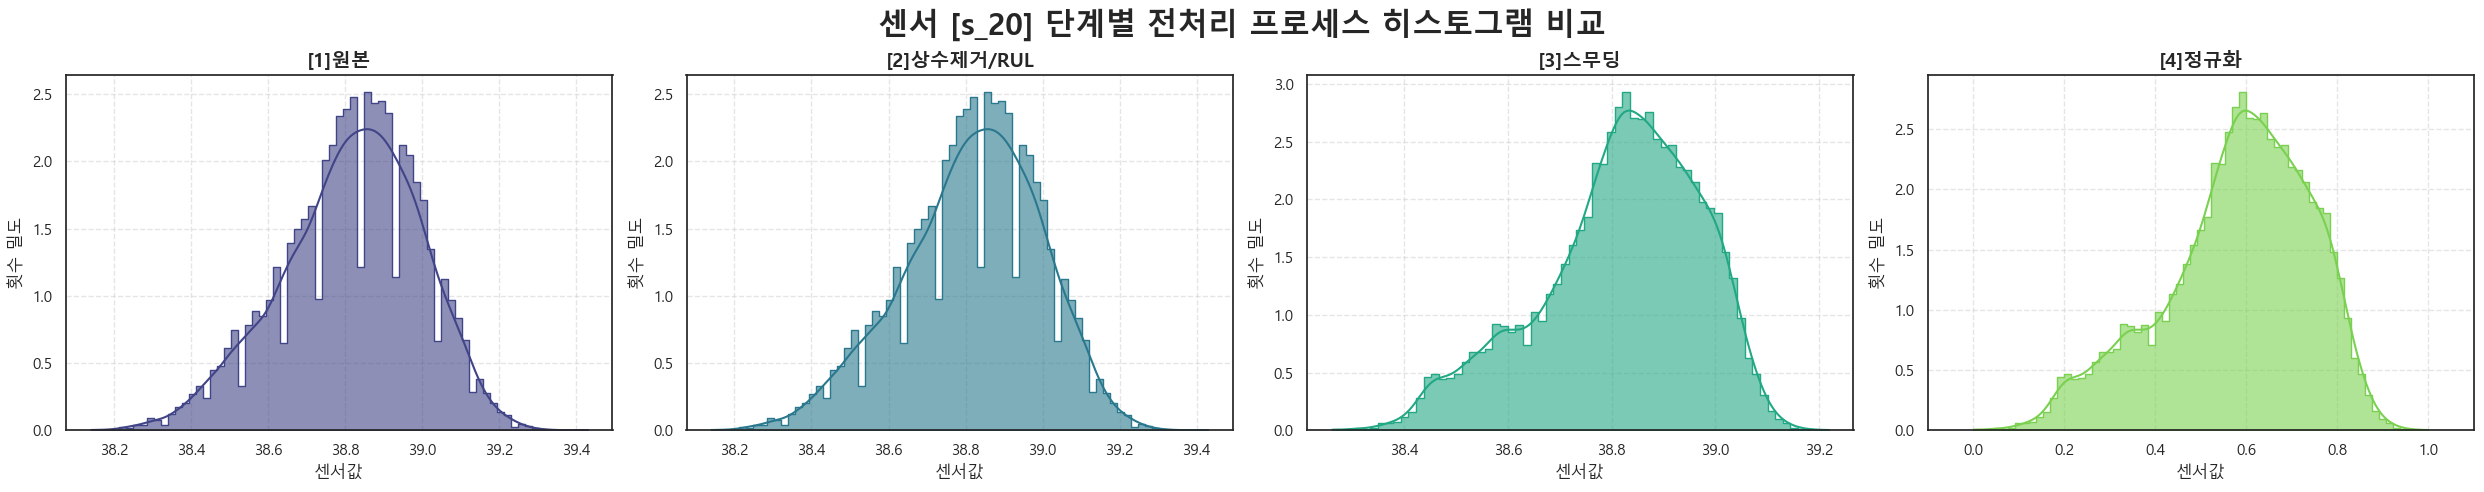

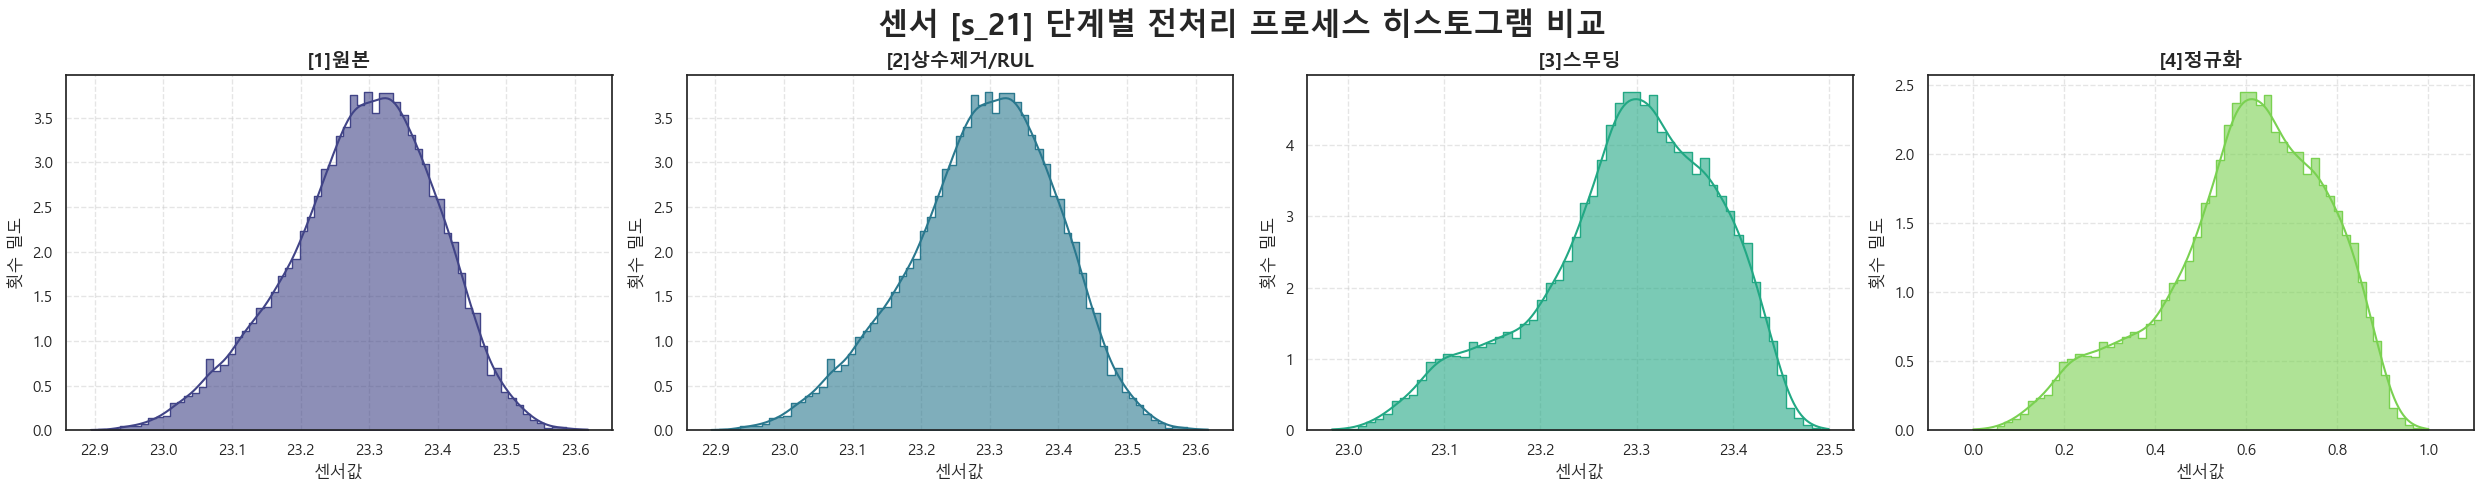

In [41]:
# ==========================================================
# 📊 [시각화] 모든 센서별 4단계 히스토그램(Density) 분포 변화 출력
# ==========================================================
# steps 리스트 길이에 맞춘 레이블 ㅋ
step_labels = ['[1]원본', '[2]상수제거/RUL', '[3]스무딩', '[4]정규화']

for sensor in sensor_names:
    fig, axes = plt.subplots(1, 4, figsize=(25, 5))
    
    for i, df_step in enumerate(steps):
        # 전체 엔진의 해당 센서값 히스토그램 + 밀도 함수(KDE) ㅋ
        # stat="density"를 써야 y축 스케일이 달라도 비교가 가능합니다! ㅋ
        sns.histplot(df_step[sensor], kde=True, ax=axes[i], 
                     color=sns.color_palette("viridis", 4)[i], 
                     stat="density", element="step", alpha=0.6)
        
        axes[i].set_title(f'{step_labels[i]}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('센서값')
        axes[i].set_ylabel('횟수 밀도')
        axes[i].grid(axis='both', linestyle='--', alpha=0.5)
        
        # 마지막 [4]정규화 단계는 0~1 사이이므로 Y축 스케일을 위해 X축 고정 ㅋ
        if i == 3:
            axes[i].set_xlim(-0.1, 1.1)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.suptitle(f'센서 [{sensor}] 단계별 전처리 프로세스 히스토그램 비교', fontsize=22, fontweight='bold')
    plt.show()

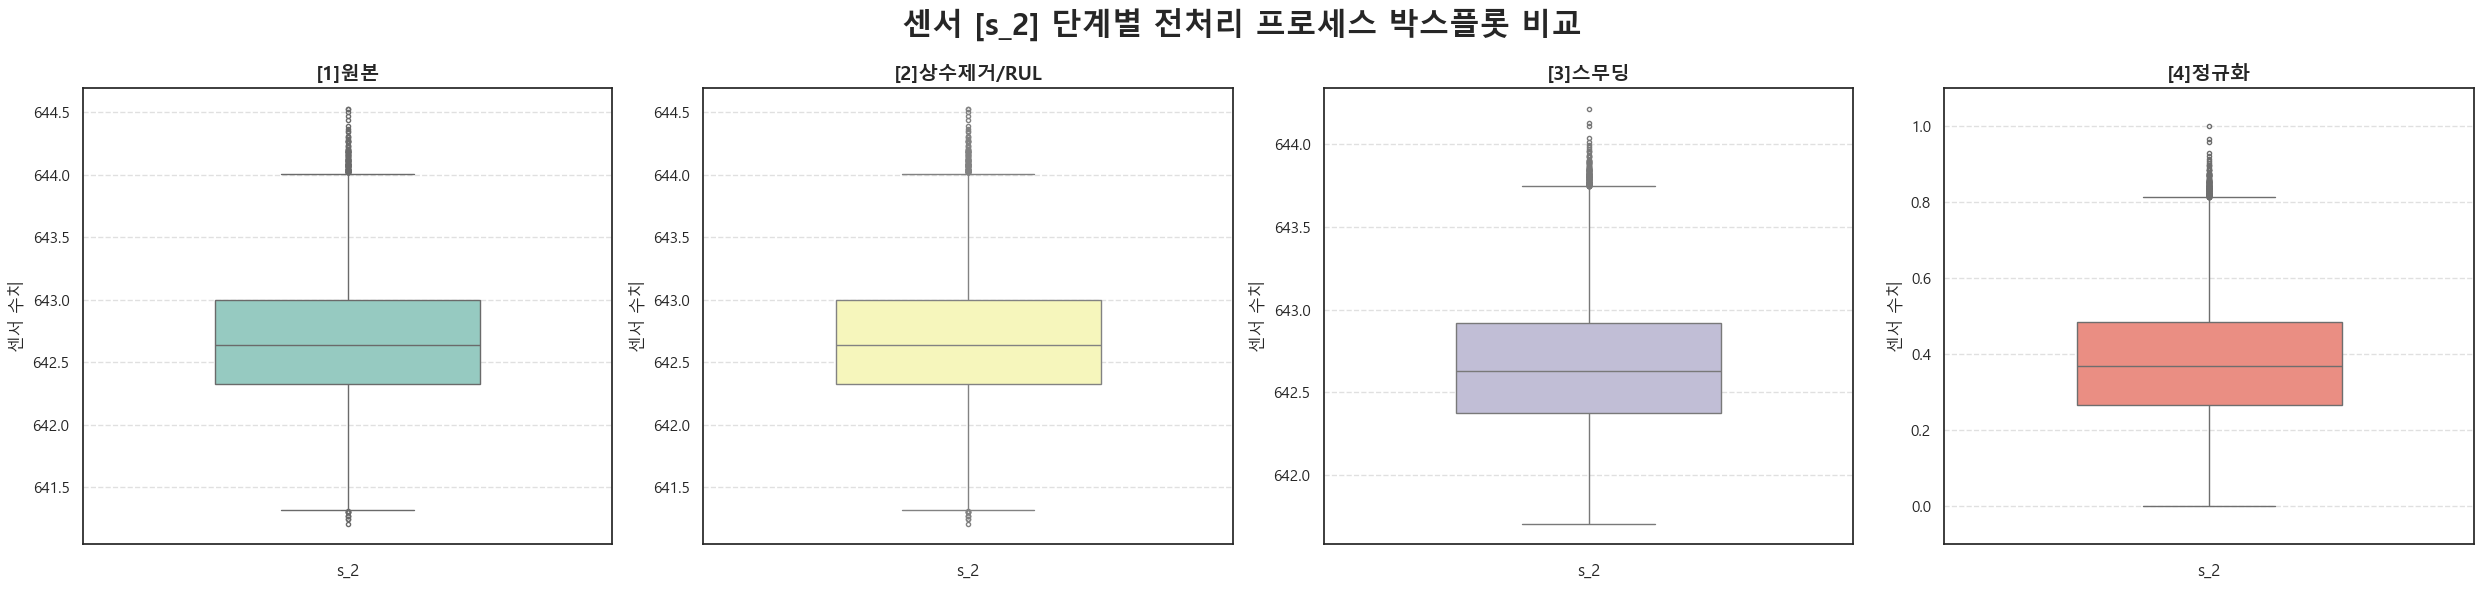

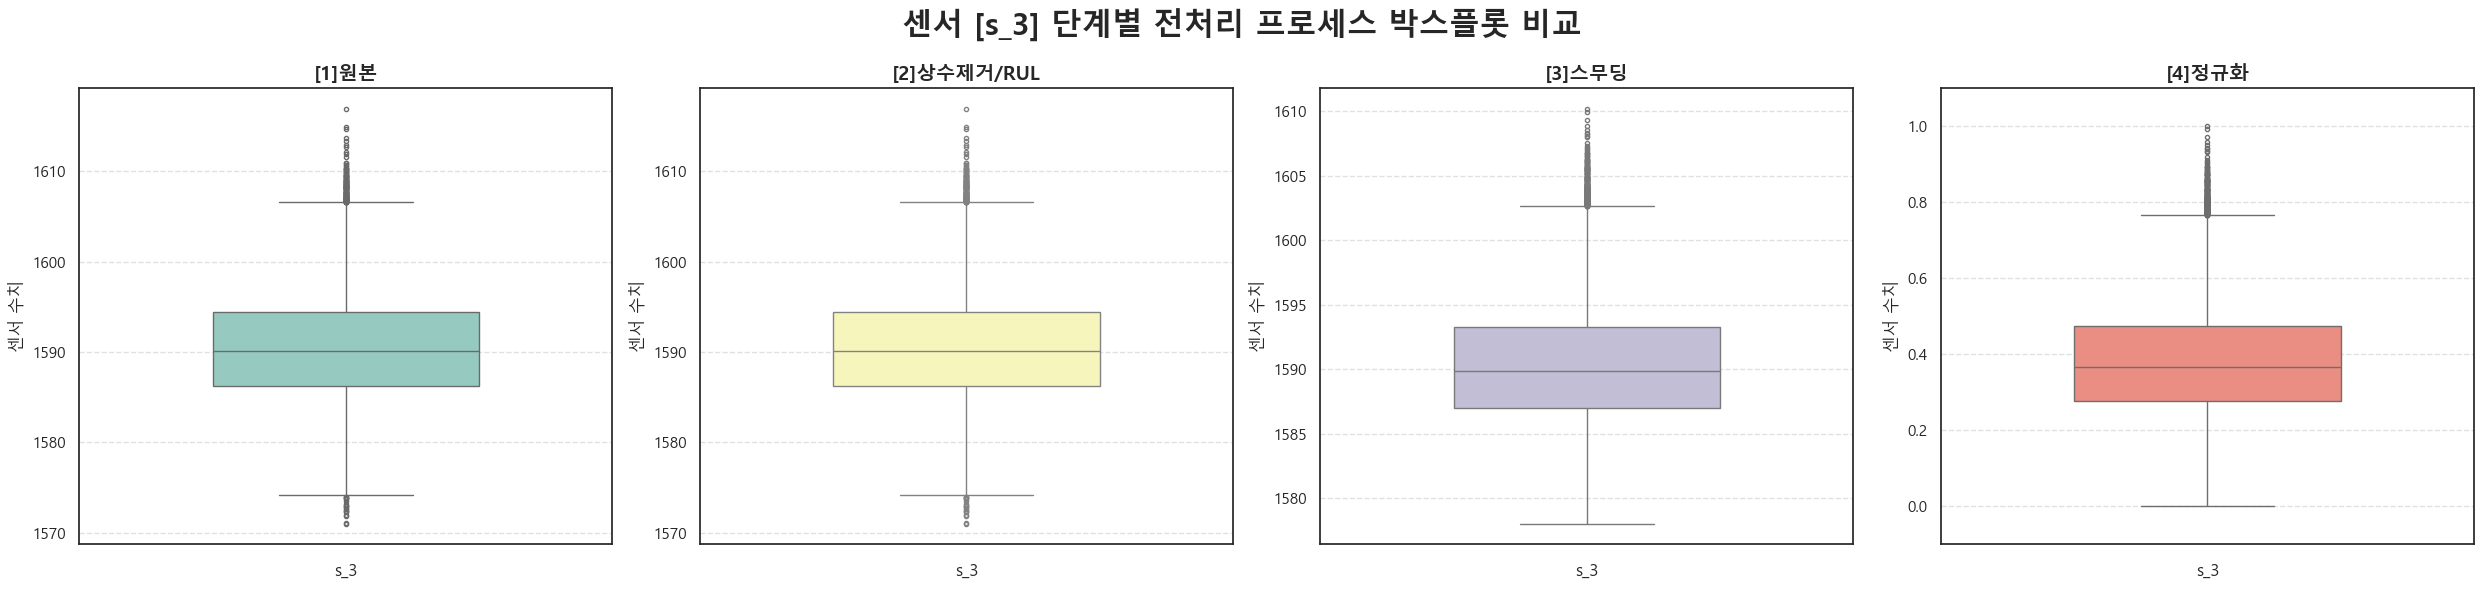

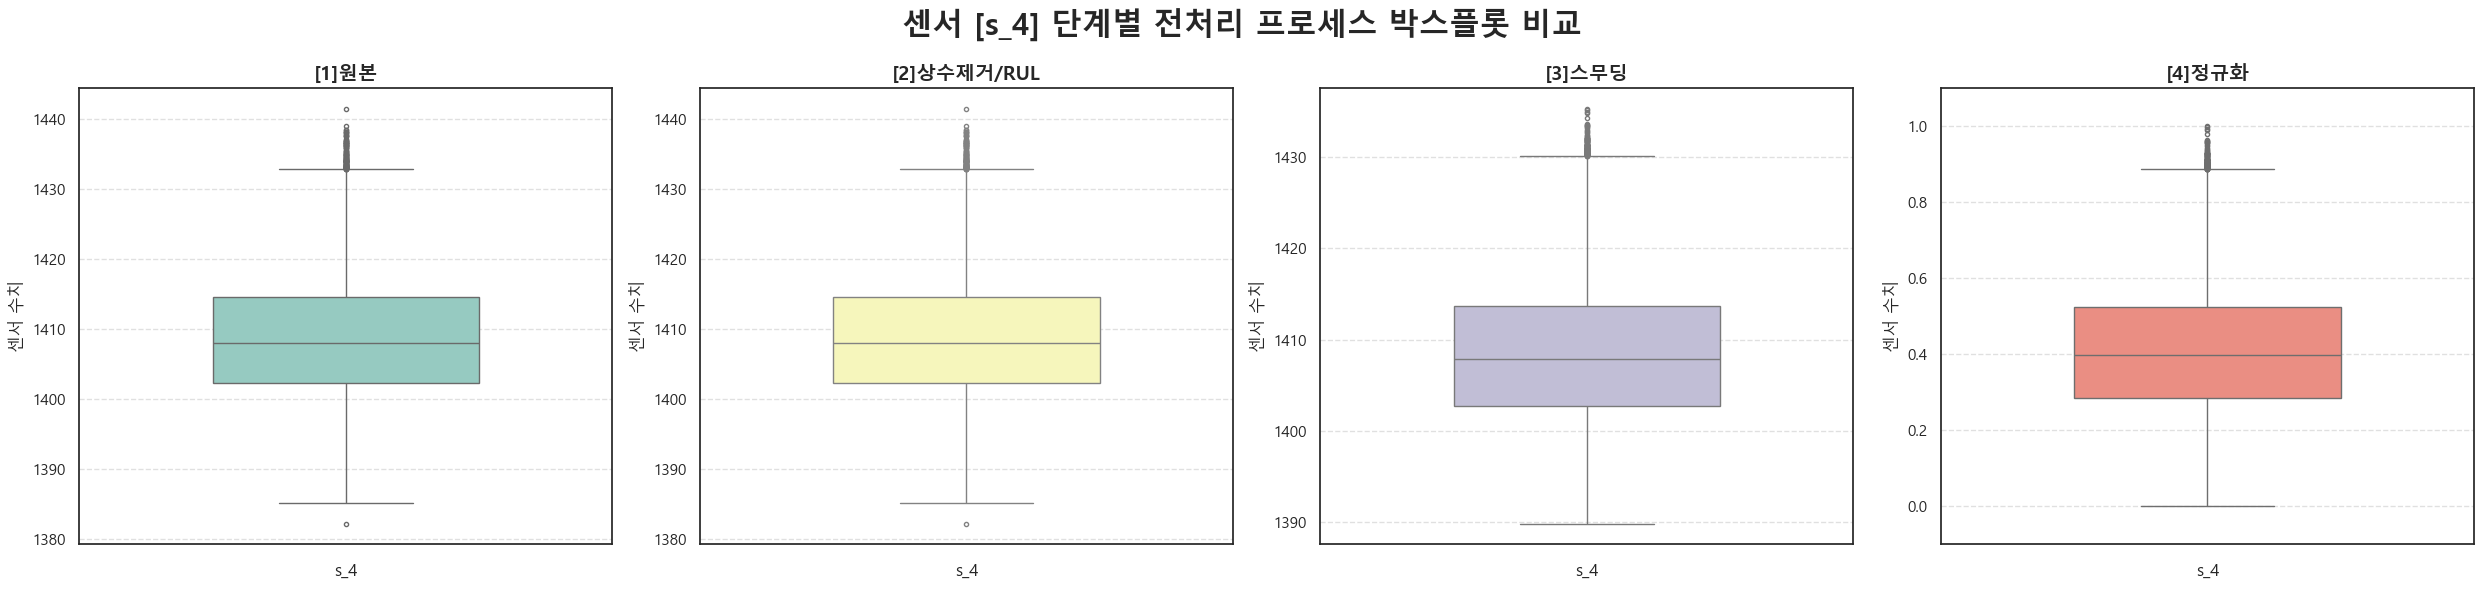

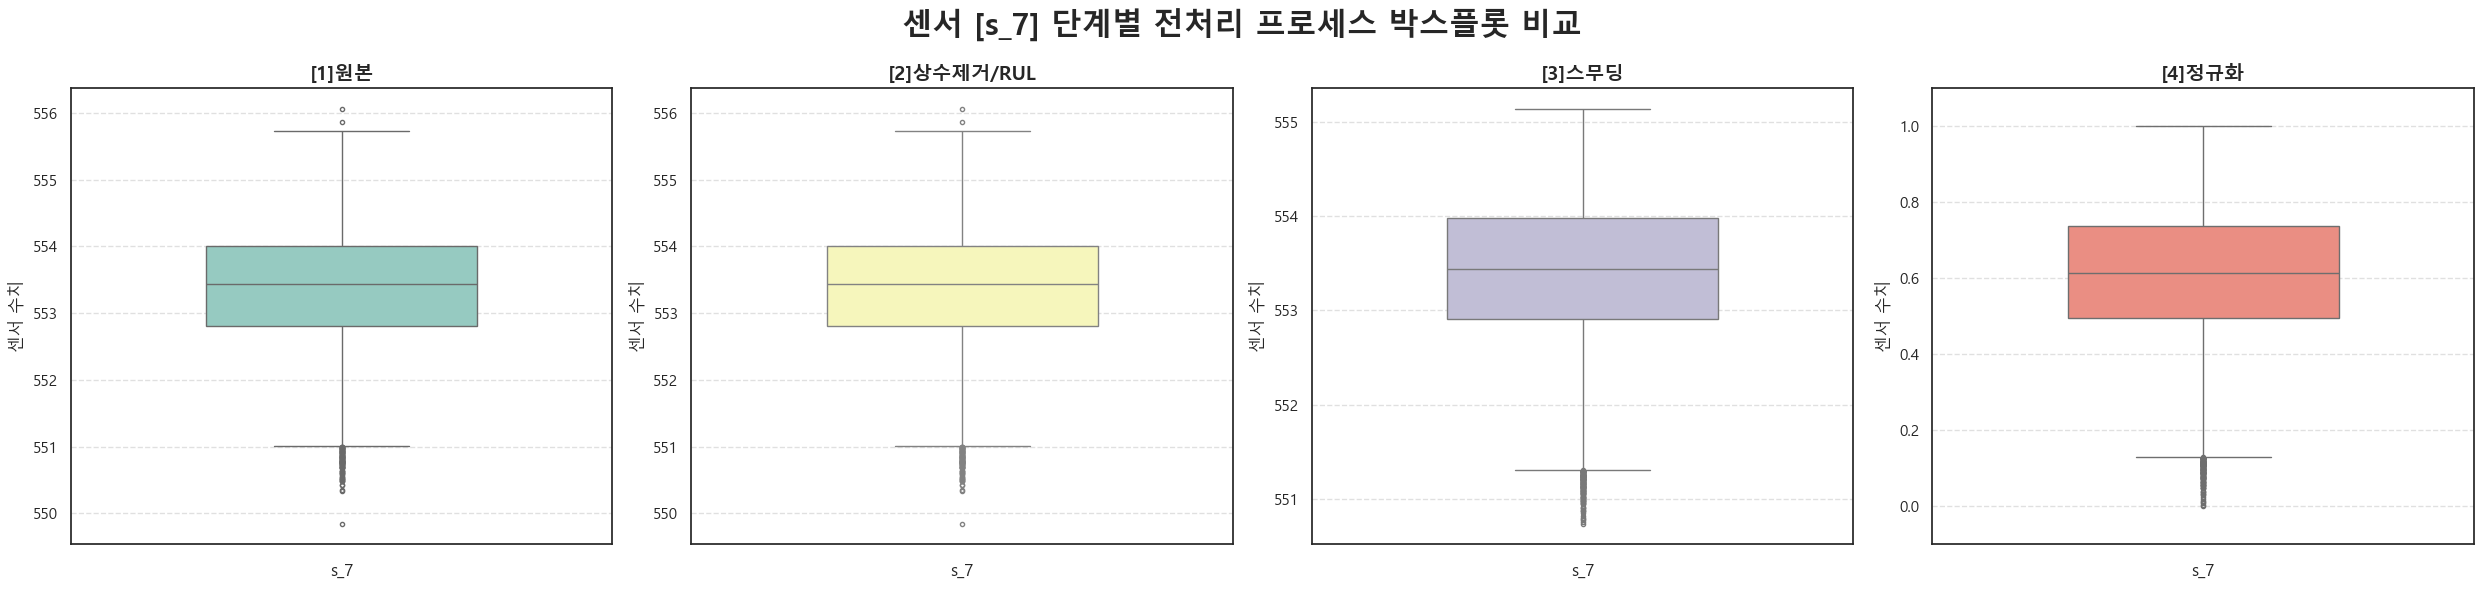

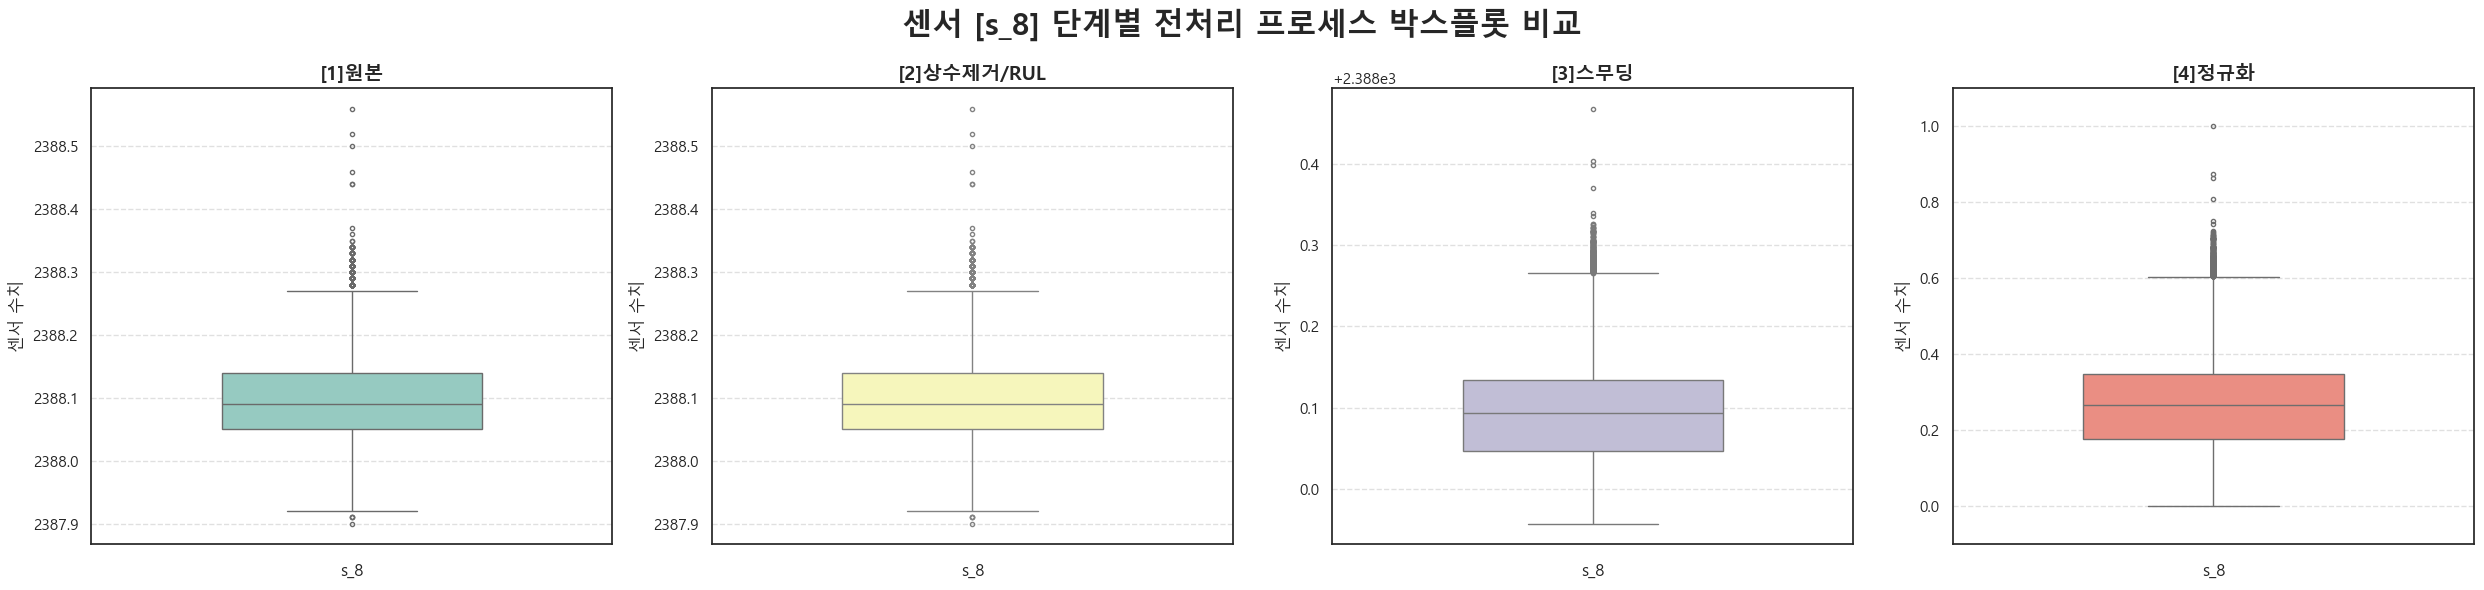

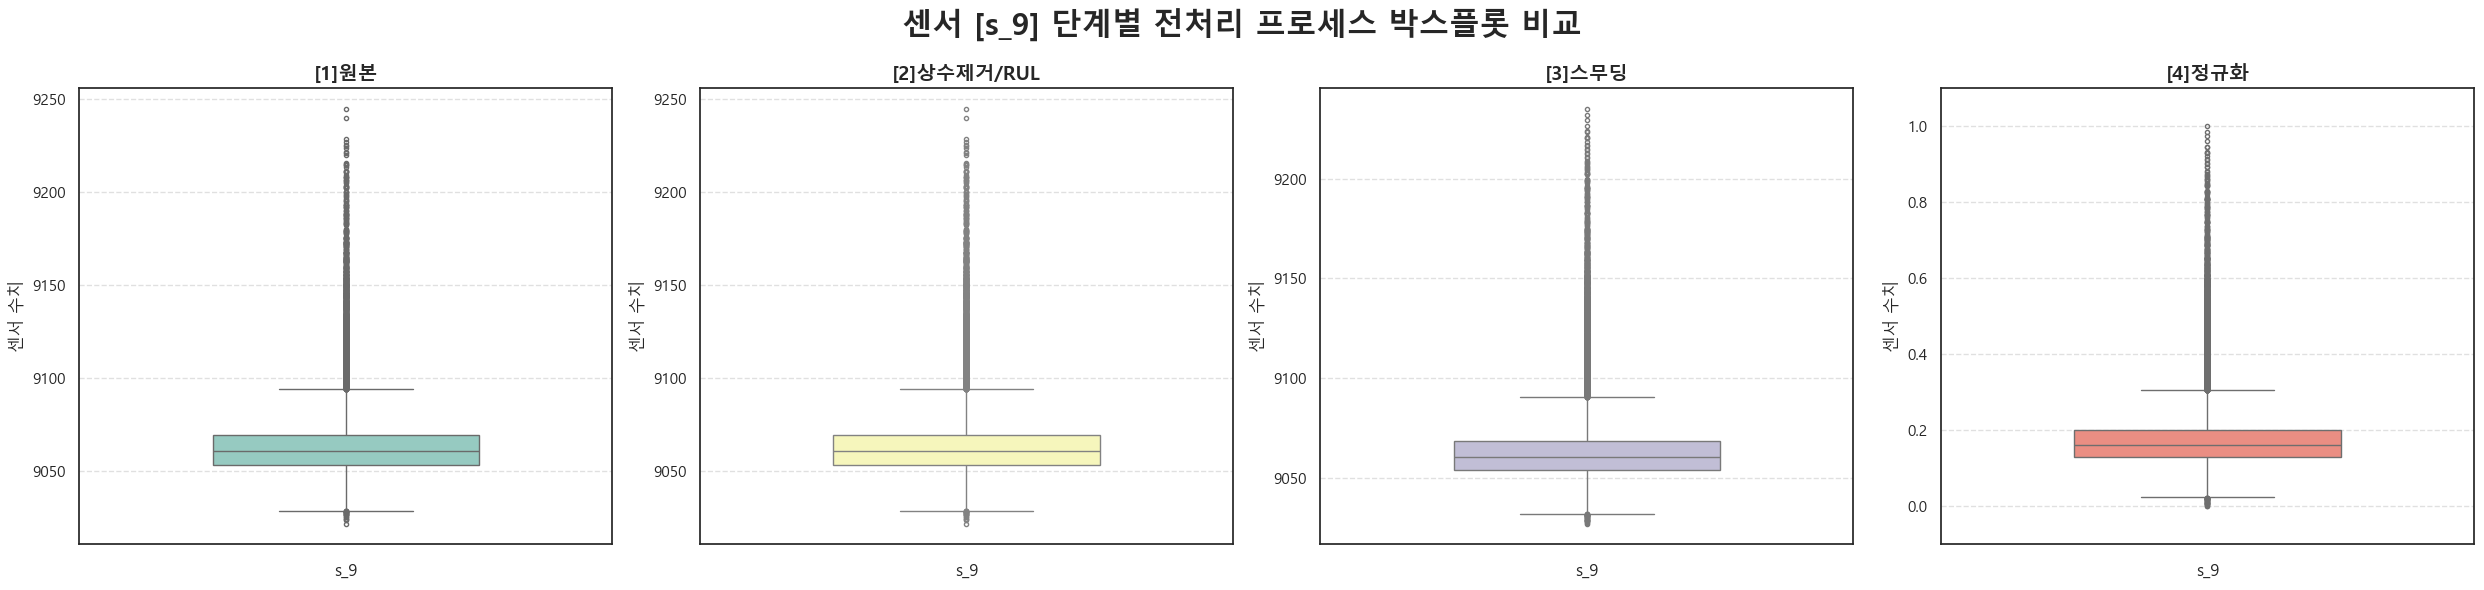

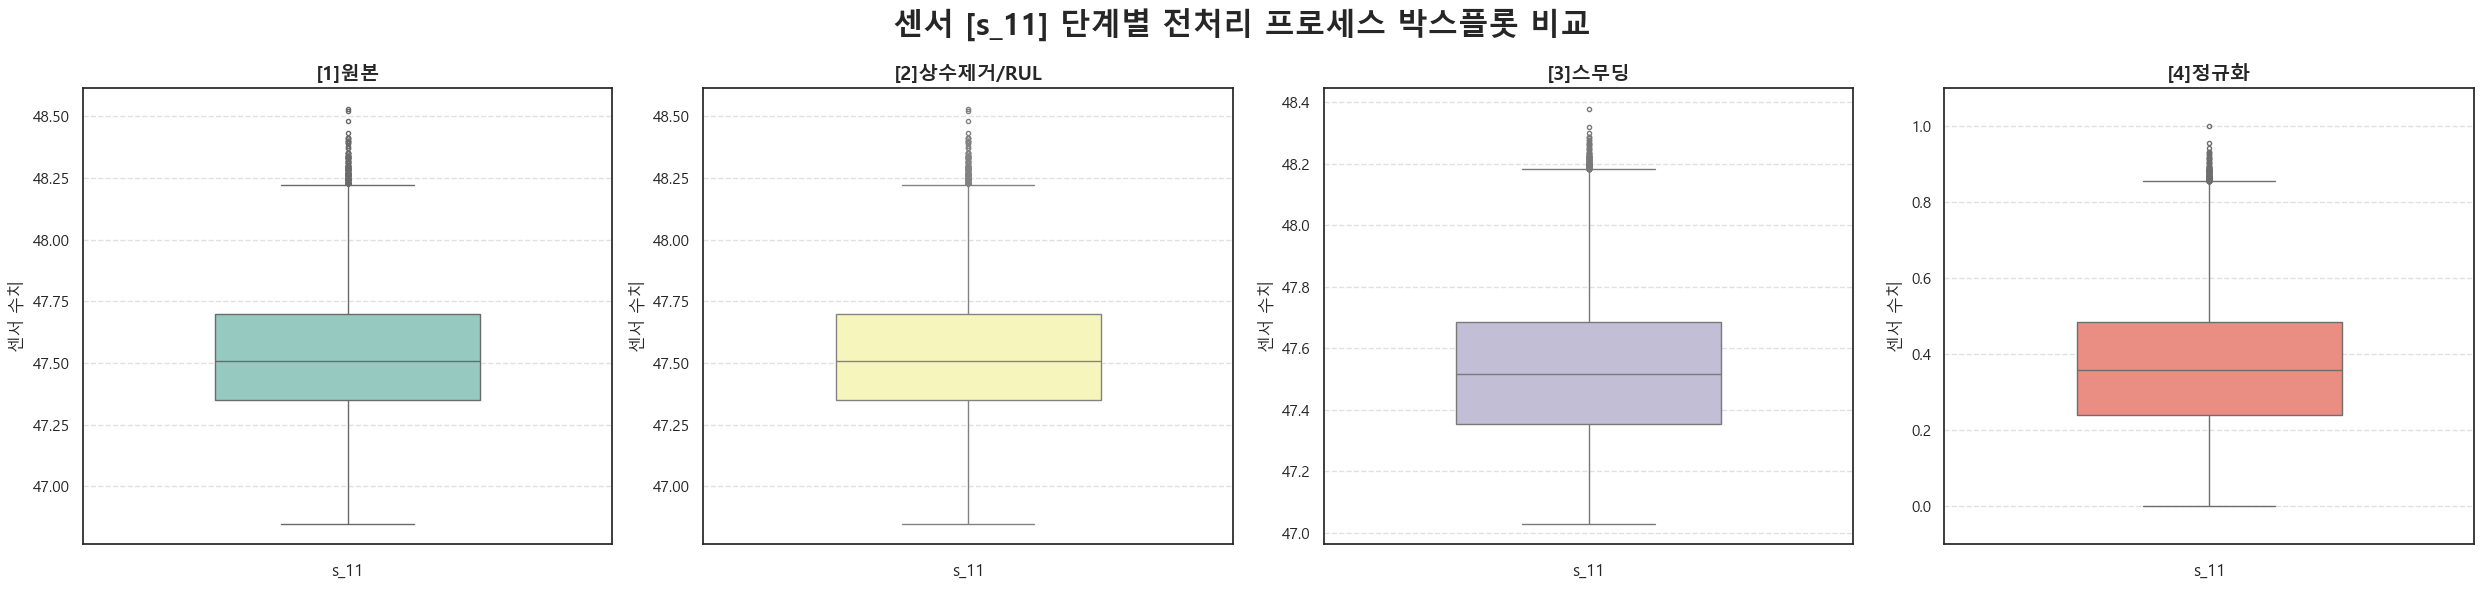

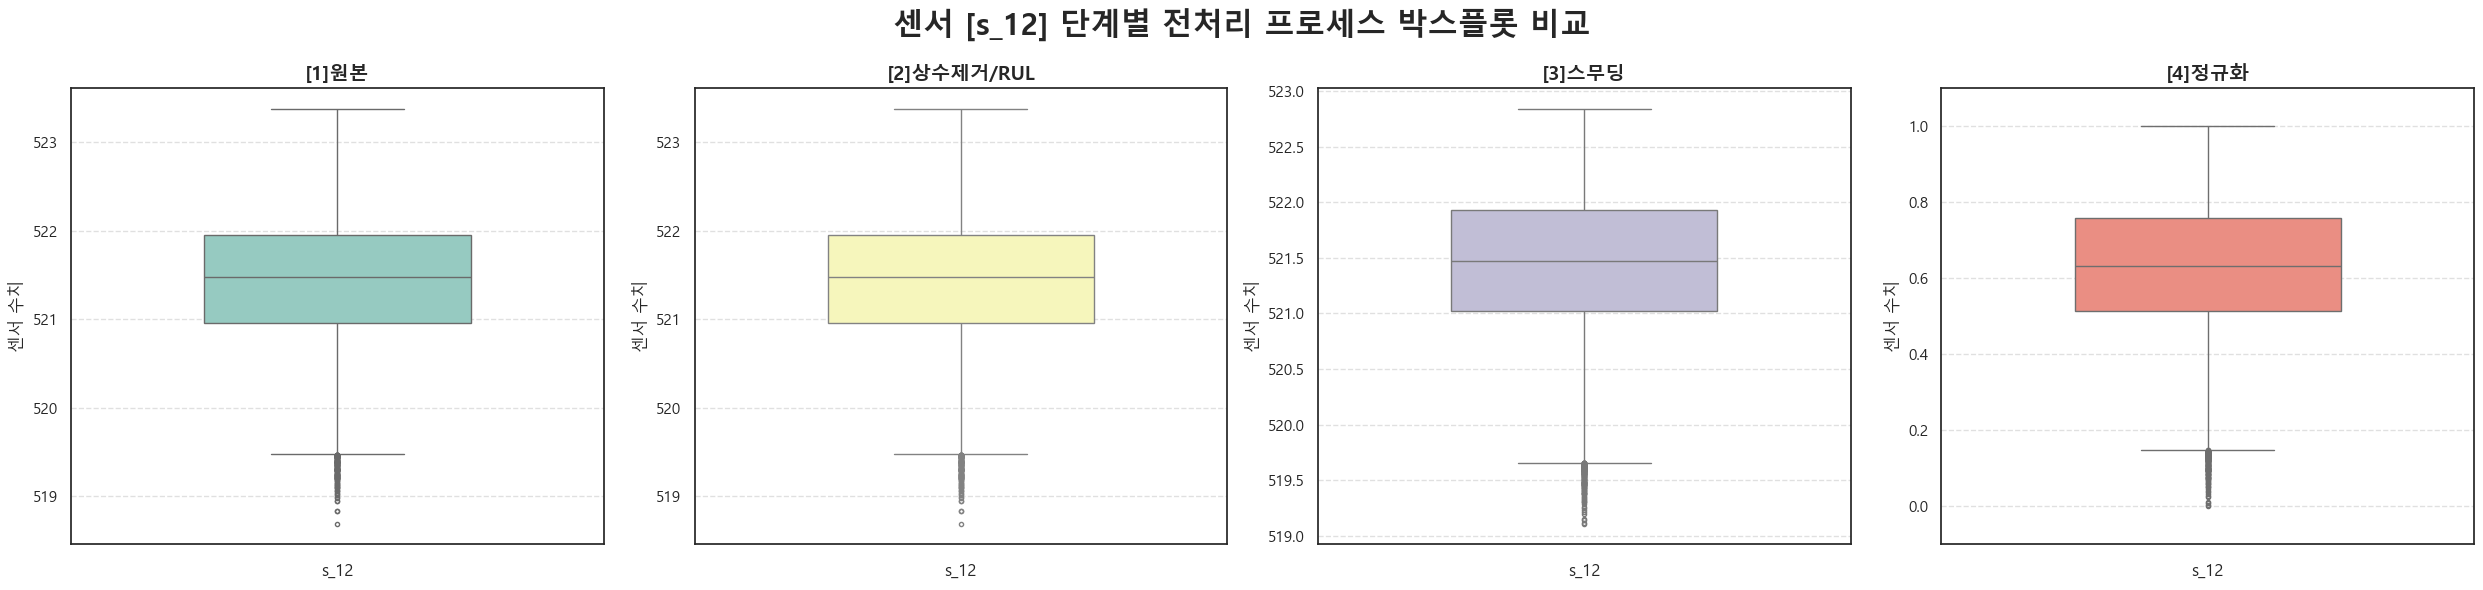

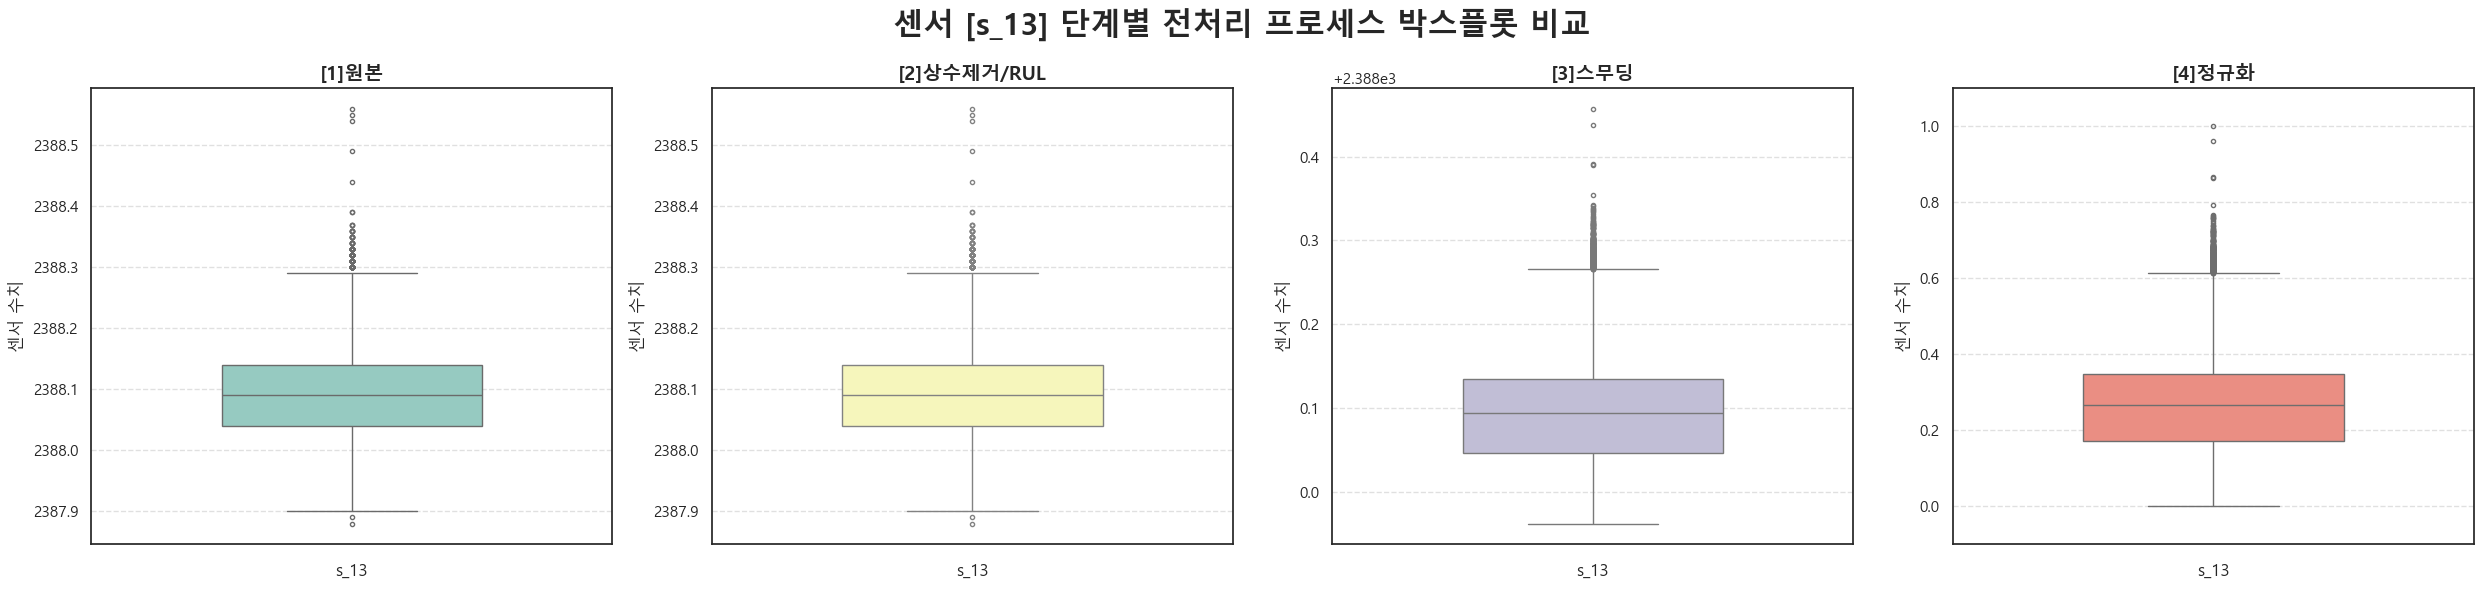

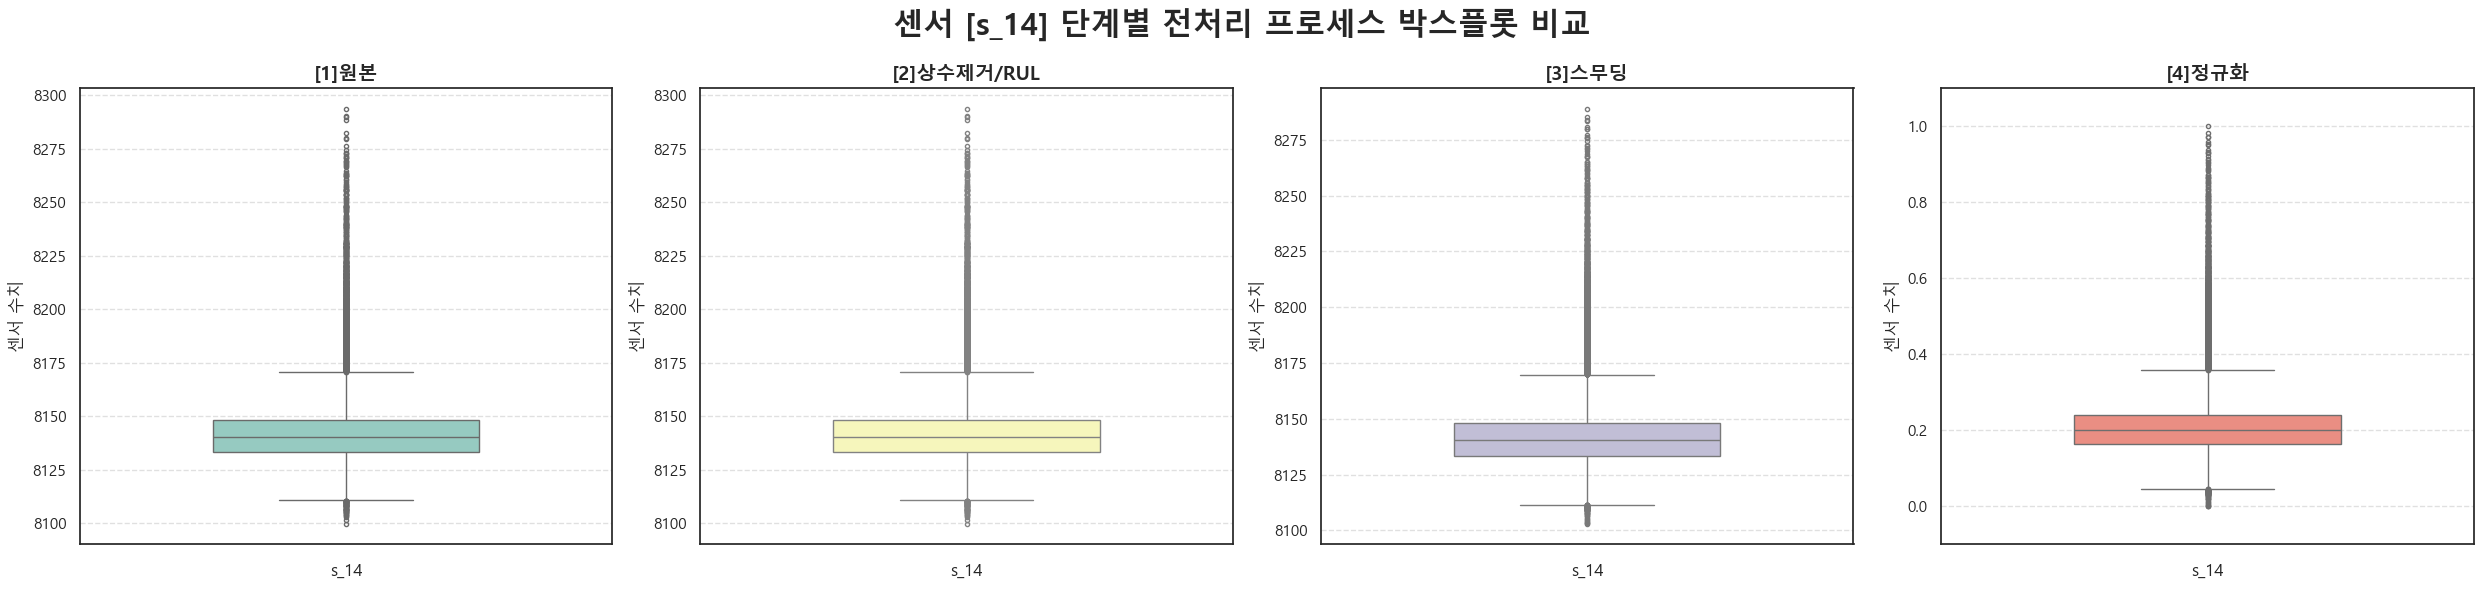

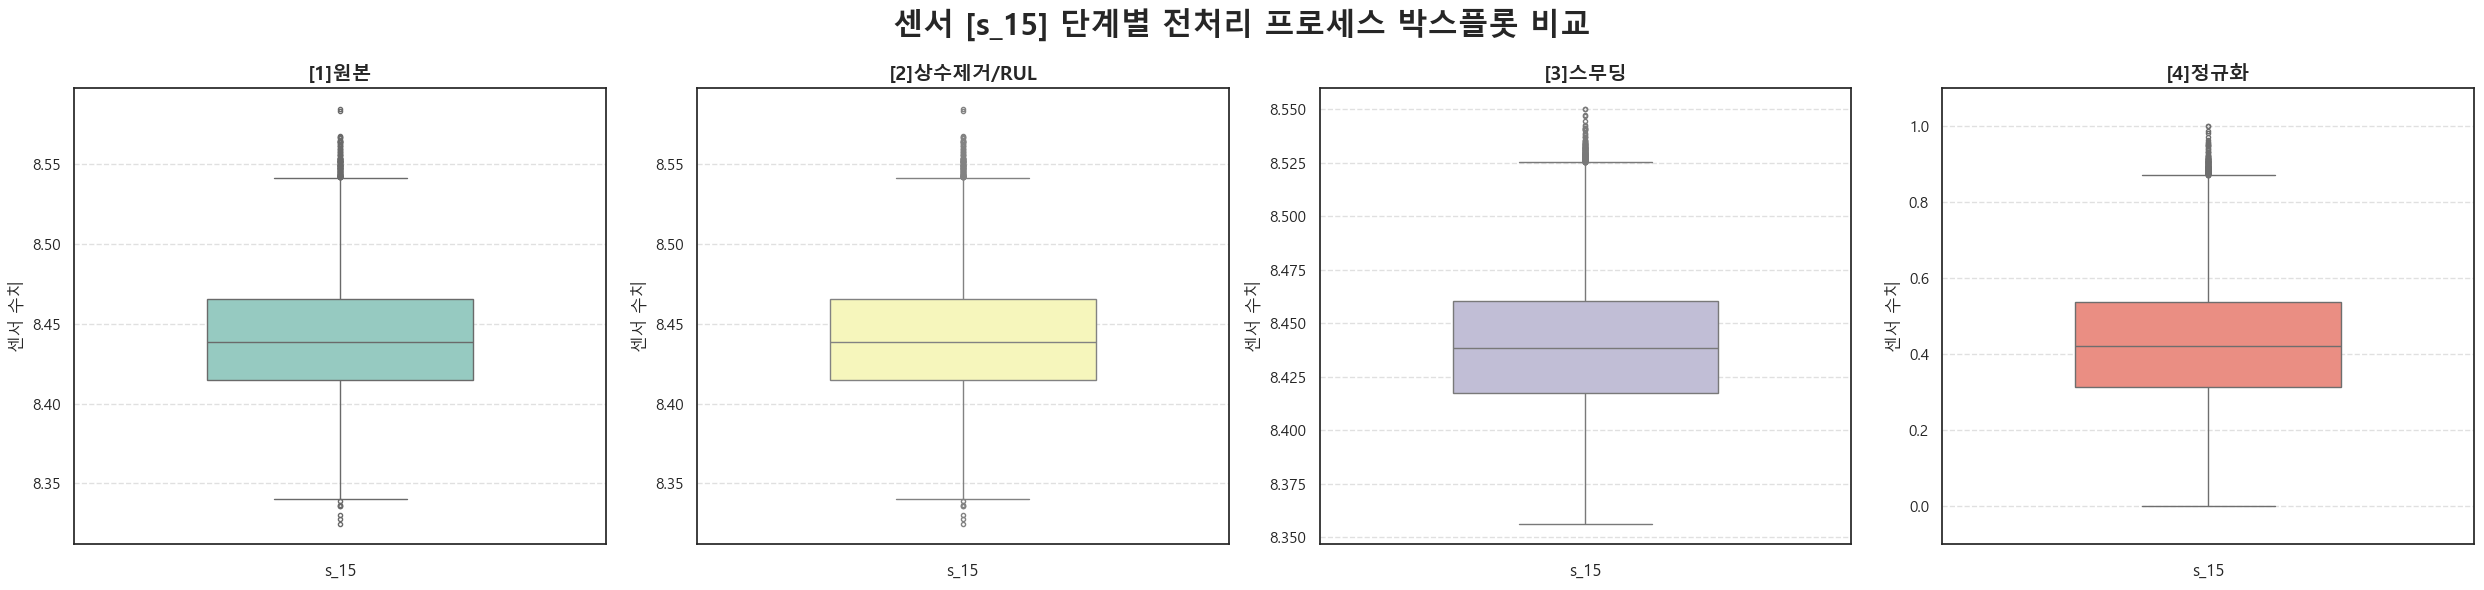

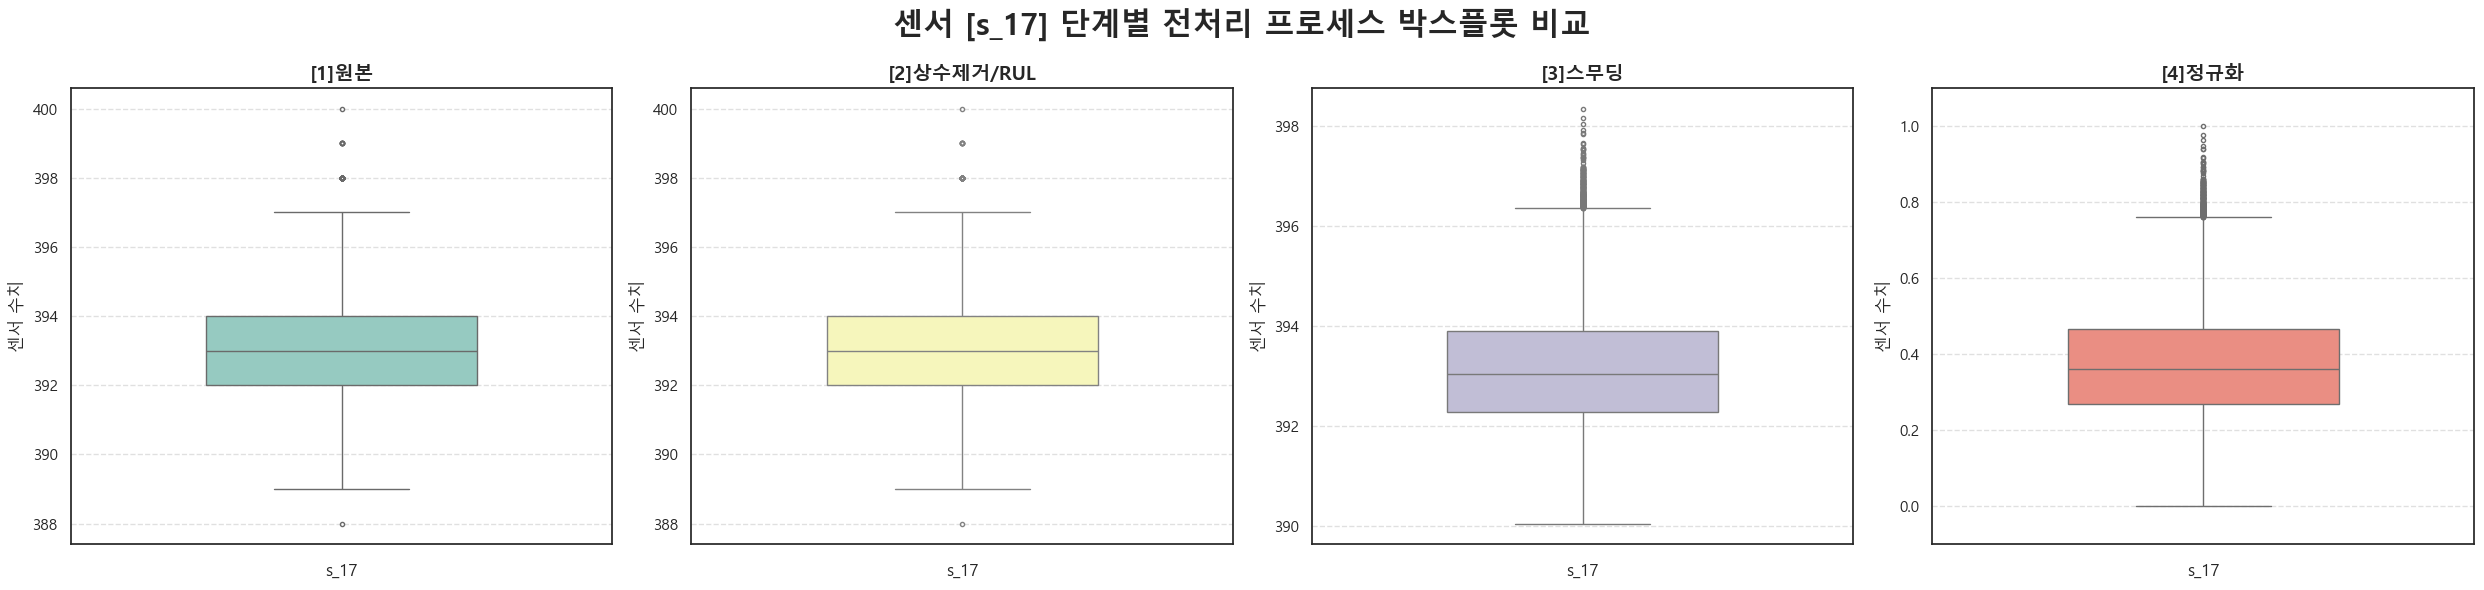

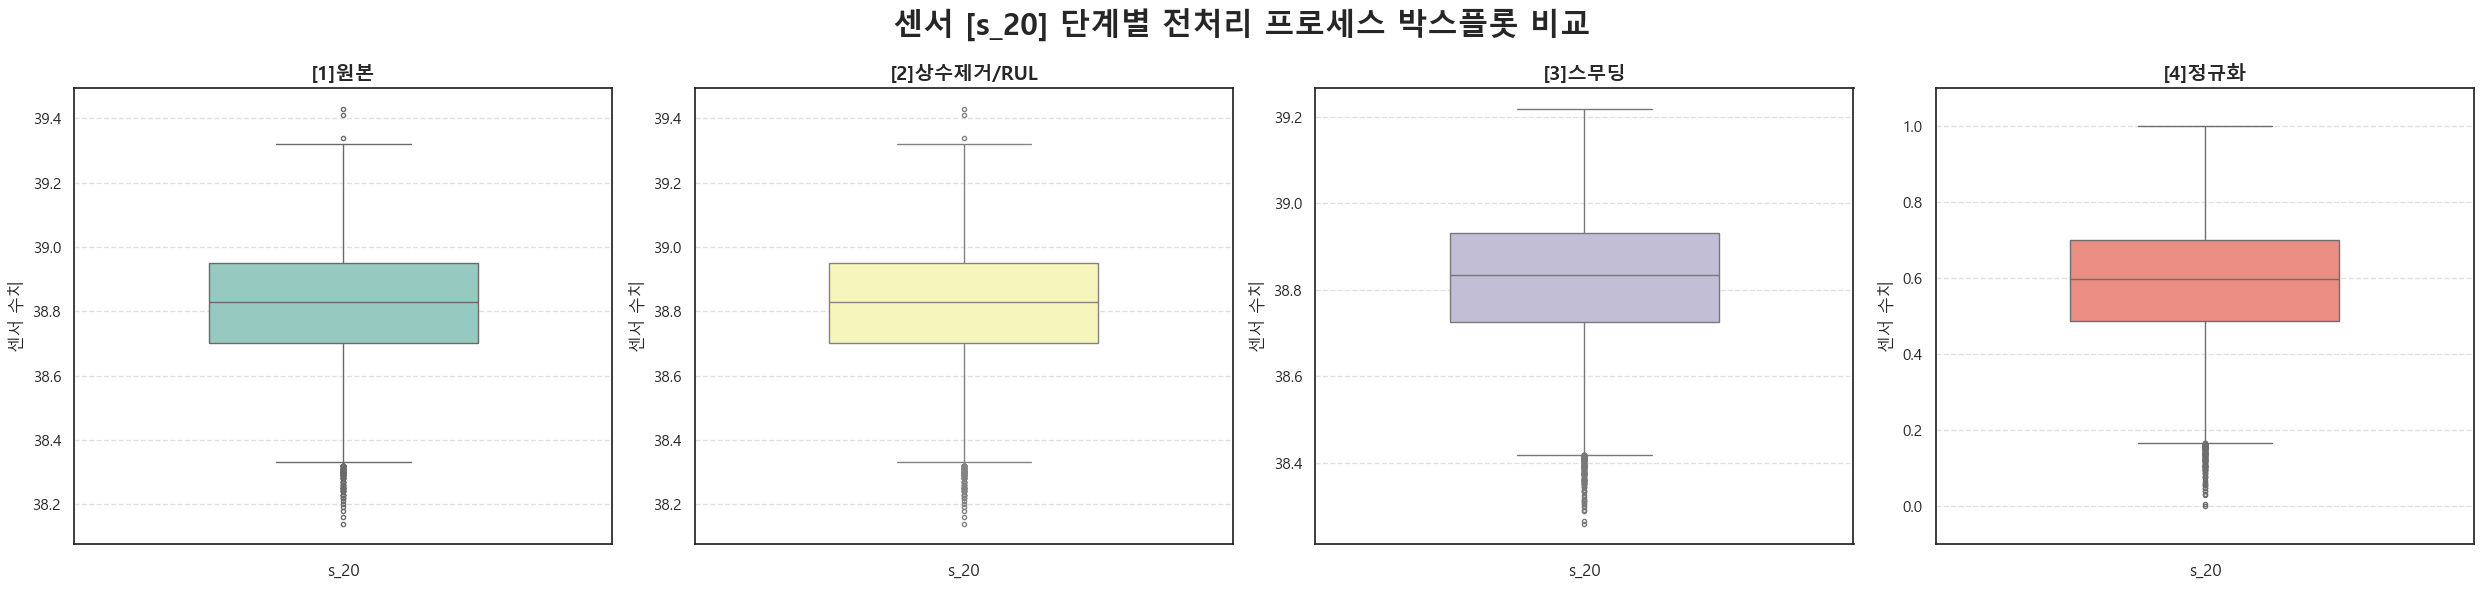

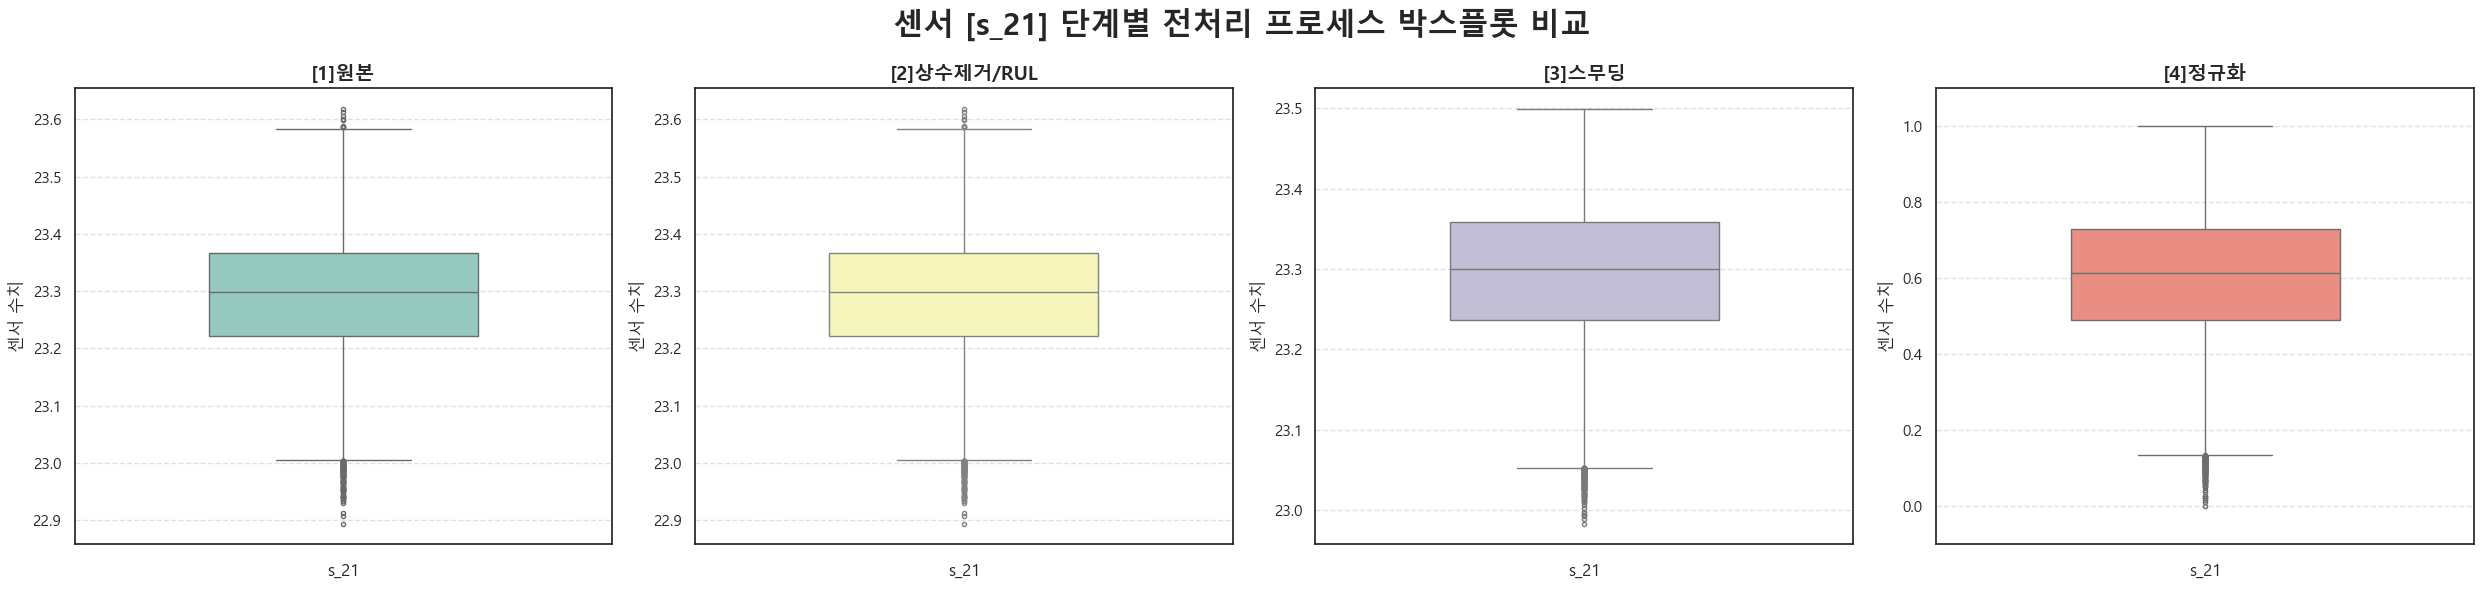

In [42]:
# ==========================================================
# 📊 [시각화] 모든 센서별 4단계 박스플롯 분포 변화 출력
# ==========================================================
step_labels = ['[1]원본', '[2]상수제거/RUL', '[3]스무딩', '[4]정규화'] # steps 리스트 길이에 맞춤 ㅋ

for sensor in sensor_names:
    fig, axes = plt.subplots(1, 4, figsize=(25, 6))
    
    for i, df_step in enumerate(steps):
        # 박스플롯 시각화 ㅋ
        sns.boxplot(y=df_step[sensor], ax=axes[i], 
                    color=sns.color_palette("Set3", 4)[i], 
                    width=0.5, fliersize=3)
        
        # 바이올린 플롯을 살짝 겹쳐서 분포의 곡선도 같이 보면 더 좋습니다 ㅋ (선택 사항)
        # sns.violinplot(y=df_step[sensor], ax=axes[i], color="white", inner=None, alpha=0.3)
        
        axes[i].set_title(f'{step_labels[i]}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('센서 수치')
        axes[i].set_xlabel(sensor)
        
        # 그리드 추가해서 수치 비교 편하게 ㅋ
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)
        
        # 마지막 [4]정규화 단계는 0~1 사이이므로 Y축 고정 ㅋ
        if i == 3:
            axes[i].set_ylim(-0.1, 1.1)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.suptitle(f'센서 [{sensor}] 단계별 전처리 프로세스 박스플롯 비교', fontsize=22, fontweight='bold')
    plt.show()

In [43]:
df_train.head()

,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,0.114655,0.346523,0.260921,0.795479,0.204102,0.096710,0.288395,0.762344,0.146973,0.178055,0.318676,0.207260,0.792210,0.820499,125
1,1,2,0.0019,-0.0003,0.153900,0.322212,0.271481,0.790024,0.208008,0.101440,0.255997,0.802551,0.159180,0.172237,0.304970,0.196136,0.766144,0.804008,125
2,1,3,-0.0043,0.0003,0.190887,0.289639,0.277344,0.790741,0.210449,0.107342,0.218735,0.834030,0.167480,0.167377,0.286991,0.191971,0.742130,0.787354,125
3,1,4,0.0007,0.0000,0.218109,0.260830,0.274076,0.795280,0.204590,0.112759,0.187069,0.846680,0.169434,0.163830,0.270885,0.195488,0.729527,0.774170,125
4,1,5,-0.0019,-0.0002,0.233643,0.248310,0.260597,0.797325,0.188477,0.115856,0.168262,0.841095,0.165039,0.160839,0.259998,0.201149,0.732887,0.765362,125


In [44]:
# s_9 값이 가장 높은 순서대로 상위 20개 행 추출 ㅋ
top_s9_values = df_train.sort_values(by='s_9', ascending=False).head(20)

# 주요 컬럼만 선택해서 보기 좋게 출력 ㅋ
print("📊 [s_9] 센서값 상위 Top 20 데이터 상황")
display(top_s9_values[['unit_nr', 'time_cycles', 's_9', 'RUL']])

# 추가 분석: 이 높은 값들이 주로 고장 직전(RUL이 작을 때)에 발생하는가? ㅋ
print(f"\n💡 상위 20개 데이터의 평균 RUL: {top_s9_values['RUL'].mean():.2f}")

📊 [s_9] 센서값 상위 Top 20 데이터 상황


,unit_nr,time_cycles,s_9,RUL
10121,51,213,1.000000,0
1913,9,201,0.984009,0
10120,51,212,0.973114,1
1912,9,200,0.959515,1
10119,51,211,0.945156,2
9495,48,231,0.944248,0
1911,9,199,0.931576,2
3775,18,195,0.929783,0
9494,48,230,0.928249,1
10118,51,210,0.920441,3



💡 상위 20개 데이터의 평균 RUL: 1.90


In [45]:
# 로그 변환 전(steps[1])과 후(steps[2])의 s_14 값 범위를 직접 비교해봅시다 ㅋ
print("--- [s_14] 로그 변환 수치 검증 ---")
print(f"변환 전 (Step 2) 최소값: {steps[1]['s_14'].min():.2f}, 최대값: {steps[1]['s_14'].max():.2f}")
print(f"변환 후 (Step 3) 최소값: {steps[2]['s_14'].min():.2f}, 최대값: {steps[2]['s_14'].max():.2f}")

# 만약 변환 후 값이 9.xx 대라면 로그가 아주 잘 먹은 겁니다! ㅋ

--- [s_14] 로그 변환 수치 검증 ---
변환 전 (Step 2) 최소값: 8099.94, 최대값: 8293.72
변환 후 (Step 3) 최소값: 8103.13, 최대값: 8288.88


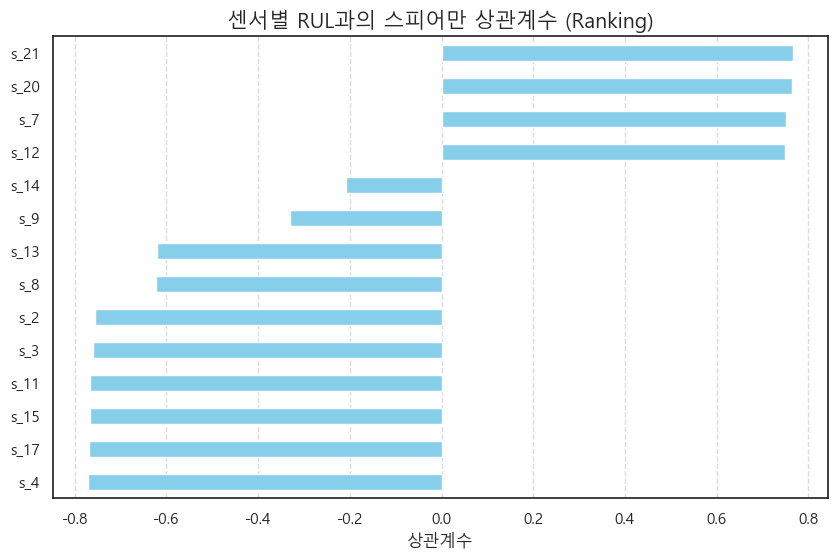

RUL과 가장 상관관계가 높은 TOP 3 센서:
s_4     0.770585
s_17    0.769105
s_15    0.767681
Name: RUL, dtype: float64


In [46]:
# 14개 센서와 RUL 사이의 스피어만 상관계수 계산 ㅋ
target_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                  's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

correlations = df_train[target_sensors + ['RUL']].corr(method='spearman')['RUL'].sort_values()

# 시각화 ㅋ
plt.figure(figsize=(10, 6))
correlations.drop('RUL').plot(kind='barh', color='skyblue')
plt.title('센서별 RUL과의 스피어만 상관계수 (Ranking)', fontsize=15)
plt.xlabel('상관계수')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("RUL과 가장 상관관계가 높은 TOP 3 센서:")
print(correlations.drop('RUL').abs().sort_values(ascending=False).head(3))

C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\2465902153.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Spearman_Corr', y='Sensor', data=res_df, palette=colors)


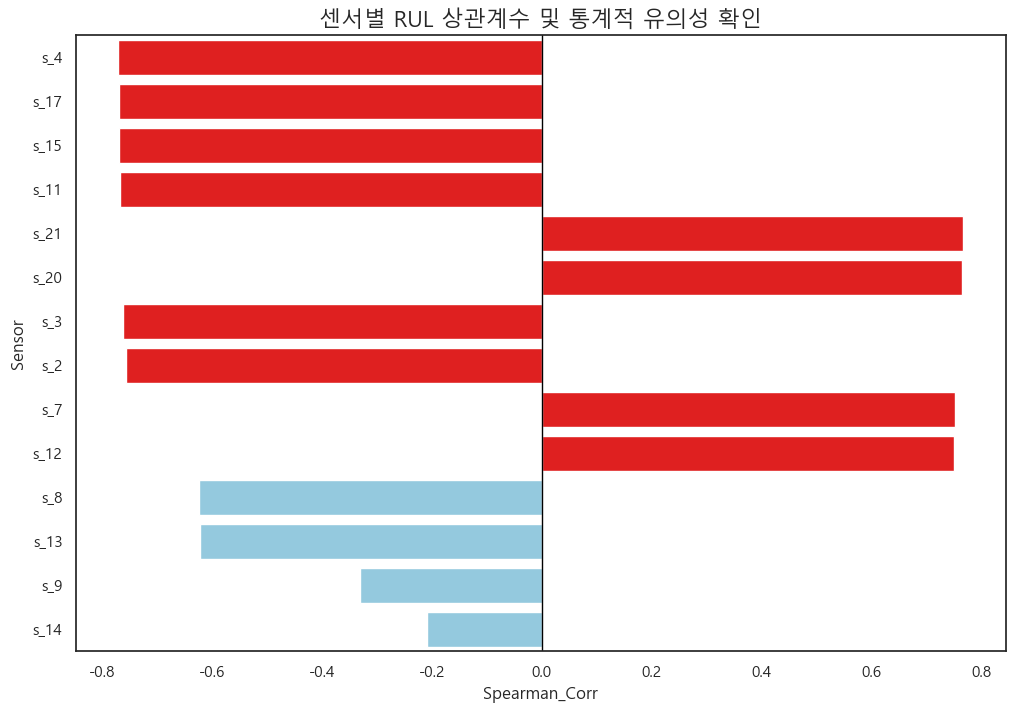

,Sensor,Spearman_Corr,P-Value,Significant
2,s_4,-0.770585,0.000000e+00,유의미
11,s_17,-0.769105,0.000000e+00,유의미
10,s_15,-0.767681,0.000000e+00,유의미
6,s_11,-0.766883,0.000000e+00,유의미
13,s_21,0.766513,0.000000e+00,유의미
12,s_20,0.764422,0.000000e+00,유의미
1,s_3,-0.761307,0.000000e+00,유의미
0,s_2,-0.756004,0.000000e+00,유의미
3,s_7,0.751092,0.000000e+00,유의미
7,s_12,0.749062,0.000000e+00,유의미


In [47]:
from scipy.stats import spearmanr

def analyze_spearman_significance(df, sensor_list):
    results = []
    
    for sensor in sensor_list:
        # 스피어만 상관계수와 p-value 계산 ㅋ
        corr, p_val = spearmanr(df[sensor], df['RUL'])
        
        results.append({
            'Sensor': sensor,
            'Spearman_Corr': corr,
            'P-Value': p_val,
            'Significant': '유의미' if p_val < 0.05 else 'No'
        })
    
    res_df = pd.DataFrame(results).sort_values(by='Spearman_Corr', key=abs, ascending=False)
    
    # 시각화 (상관계수와 유의성 표시)
    plt.figure(figsize=(12, 8))
    colors = ['red' if abs(c) > 0.7 else 'skyblue' for c in res_df['Spearman_Corr']]
    sns.barplot(x='Spearman_Corr', y='Sensor', data=res_df, palette=colors)
    
    plt.title('센서별 RUL 상관계수 및 통계적 유의성 확인', fontsize=16)
    plt.axvline(0, color='black', linewidth=1)
    plt.show()
    
    return res_df

# 실행!
spearman_report = analyze_spearman_significance(df_train, sensor_names)
display(spearman_report)

In [48]:
!pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable


🔍 [s_11] 고급 통계 분석 보고서
--------------------------------------------------
📈 Mann-Kendall 결과: increasing
   - Tau (추세 강도): 0.8655
   - P-value: 0.0000e+00
   - Slope (기울기): 0.0027


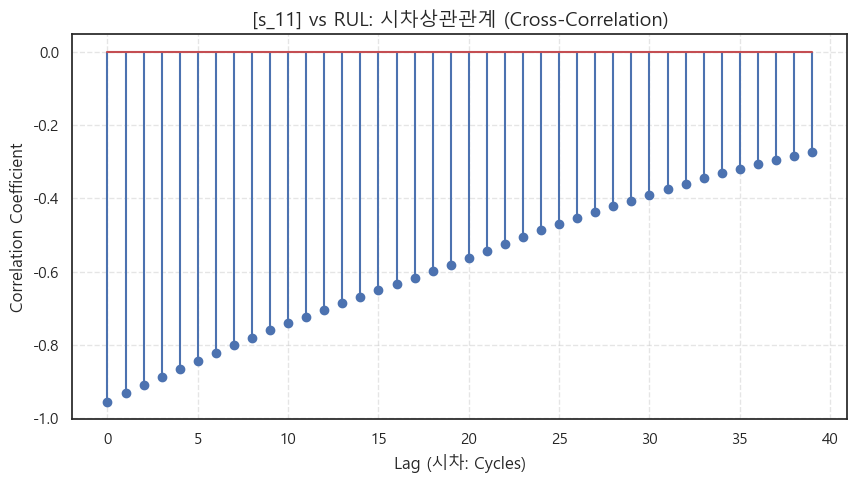

In [49]:
import pymannkendall as mk
import statsmodels.api as sm
import matplotlib.pyplot as plt

def analyze_advanced_stats(df, sensor='s_11'):
    print(f"🔍 [{sensor}] 고급 통계 분석 보고서")
    print("-" * 50)
    
    # 엔진 1번 샘플 데이터 추출 ㅋ
    unit_1_data = df[df['unit_nr'] == 1]
    sample_data = unit_1_data[sensor].values
    sample_rul = unit_1_data['RUL'].values
    
    # 1. Mann-Kendall 검정 ㅋ
    mk_res = mk.original_test(sample_data)
    
    # 객체 속성에 맞춰 출력 (버전에 따라 Tau 또는 tau ㅋ)
    print(f"📈 Mann-Kendall 결과: {mk_res.trend}")
    print(f"   - Tau (추세 강도): {mk_res.Tau:.4f}") # 대문자 Tau로 수정 ㅋ
    print(f"   - P-value: {mk_res.p:.4e}")
    print(f"   - Slope (기울기): {mk_res.slope:.4f}")

    # 2. 시차상관관계 (Cross-Correlation) ㅋ
    # statsmodels의 ccf 사용
    ccf_values = sm.tsa.stattools.ccf(sample_rul, sample_data, adjusted=False)
    
    plt.figure(figsize=(10, 5))
    # 시차(Lag) 40까지 시각화 ㅋ
    lags = range(min(len(ccf_values), 40))
    plt.stem(lags, ccf_values[:40])
    
    plt.title(f'[{sensor}] vs RUL: 시차상관관계 (Cross-Correlation)', fontsize=14)
    plt.xlabel('Lag (시차: Cycles)')
    plt.ylabel('Correlation Coefficient')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 다시 실행! ㅋ
analyze_advanced_stats(df_train, 's_11')

🚀 모든 엔진 데이터 분석 중... 잠시만 기다려주세요! ㅋ


C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\2891160609.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Tau', y='Sensor', data=summary_df, ax=ax1, palette='magma')
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\2891160609.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Max_Lag', y='Sensor', data=summary_df, ax=ax2, palette='viridis')


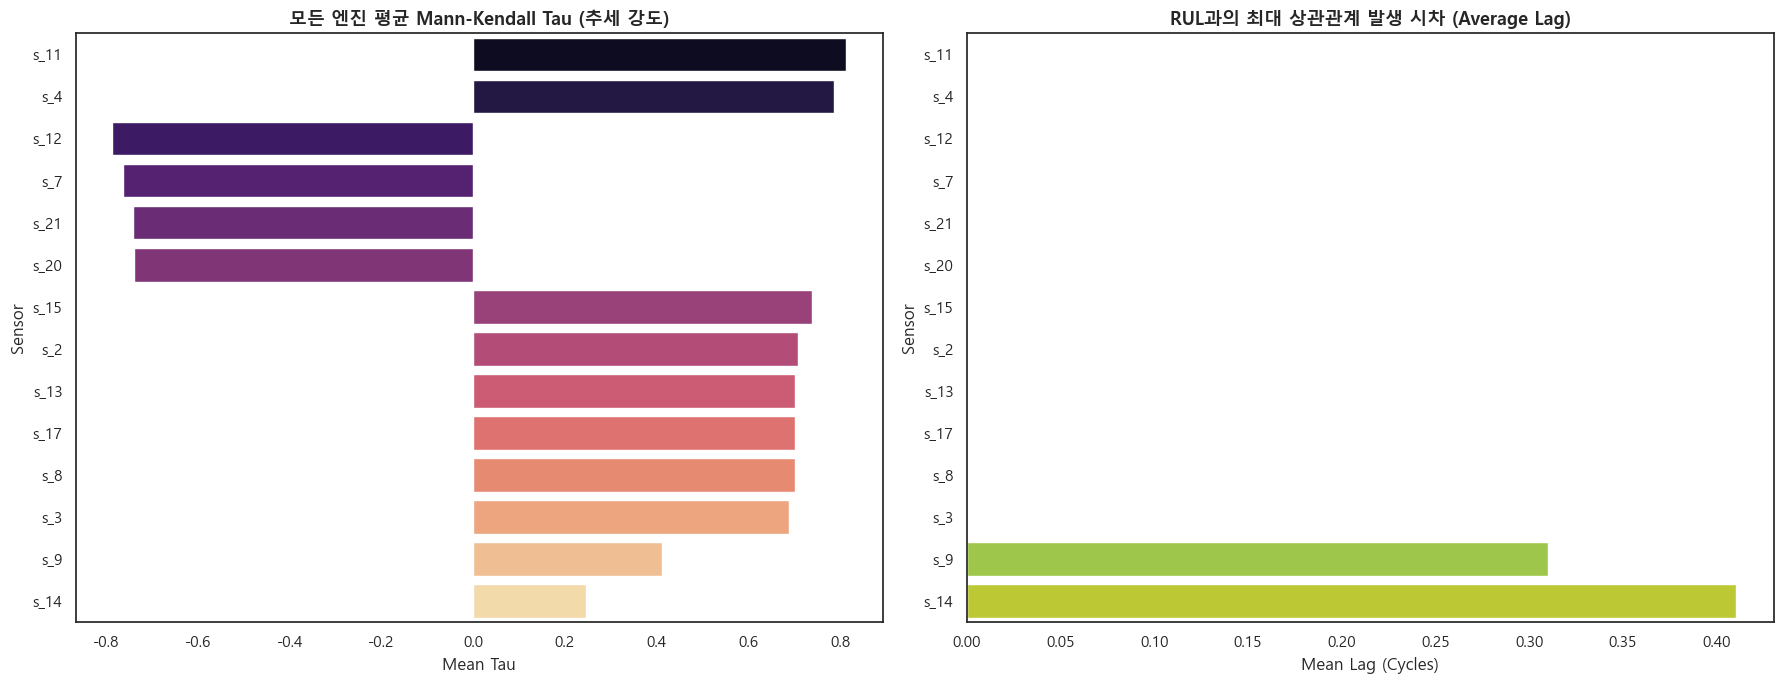

,Sensor,Avg_Tau,Avg_Max_Lag,Tau_Std
6,s_11,0.813087,0.00,0.047307
2,s_4,0.786691,0.00,0.047087
7,s_12,-0.786550,0.00,0.056882
3,s_7,-0.762570,0.00,0.067258
13,s_21,-0.740661,0.00,0.058765
12,s_20,-0.739590,0.00,0.053804
10,s_15,0.738306,0.00,0.050165
0,s_2,0.708891,0.00,0.060694
8,s_13,0.702233,0.00,0.185736
11,s_17,0.700747,0.00,0.056295


In [50]:
import pymannkendall as mk
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_all_engines_stats(df, sensor_list):
    all_res = []
    
    print("🚀 모든 엔진 데이터 분석 중... 잠시만 기다려주세요! ㅋ")
    
    for sensor in sensor_list:
        taus = []
        lags_at_max = []
        
        # 모든 엔진(unit_nr)에 대해 루프 ㅋ
        for unit in df['unit_nr'].unique():
            unit_data = df[df['unit_nr'] == unit]
            s_data = unit_data[sensor].values
            r_data = unit_data['RUL'].values
            
            # 1. Mann-Kendall Tau 계산
            try:
                mk_res = mk.original_test(s_data)
                taus.append(mk_res.Tau)
            except:
                continue # 데이터 부족 등 에러 시 패스 ㅋ
                
            # 2. 시차상관관계 (최대 상관계수가 발생하는 Lag 찾기)
            ccf_values = sm.tsa.stattools.ccf(r_data, s_data, adjusted=False)
            # 가장 상관관계가 높은(절대값 기준) 시점 찾기 ㅋ
            max_lag = np.argmax(np.abs(ccf_values[:20])) 
            lags_at_max.append(max_lag)
            
        all_res.append({
            'Sensor': sensor,
            'Avg_Tau': np.mean(taus),
            'Avg_Max_Lag': np.mean(lags_at_max),
            'Tau_Std': np.std(taus) # 엔진별 편차 확인용 ㅋ
        })
        
    summary_df = pd.DataFrame(all_res).sort_values(by='Avg_Tau', key=abs, ascending=False)
    
    # --- 시각화 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # 1. 센서별 평균 Tau (추세 일관성) ㅋ
    sns.barplot(x='Avg_Tau', y='Sensor', data=summary_df, ax=ax1, palette='magma')
    ax1.set_title('모든 엔진 평균 Mann-Kendall Tau (추세 강도)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Mean Tau')
    
    # 2. 센서별 평균 Max Lag (반응 지연 시간) ㅋ
    sns.barplot(x='Avg_Max_Lag', y='Sensor', data=summary_df, ax=ax2, palette='viridis')
    ax2.set_title('RUL과의 최대 상관관계 발생 시차 (Average Lag)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Mean Lag (Cycles)')

    plt.tight_layout()
    plt.show()
    
    return summary_df

# 실행! (시간이 조금 걸릴 수 있습니다 ㅋ)
sensor_names = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
final_report = analyze_all_engines_stats(df_train, sensor_names)
display(final_report)

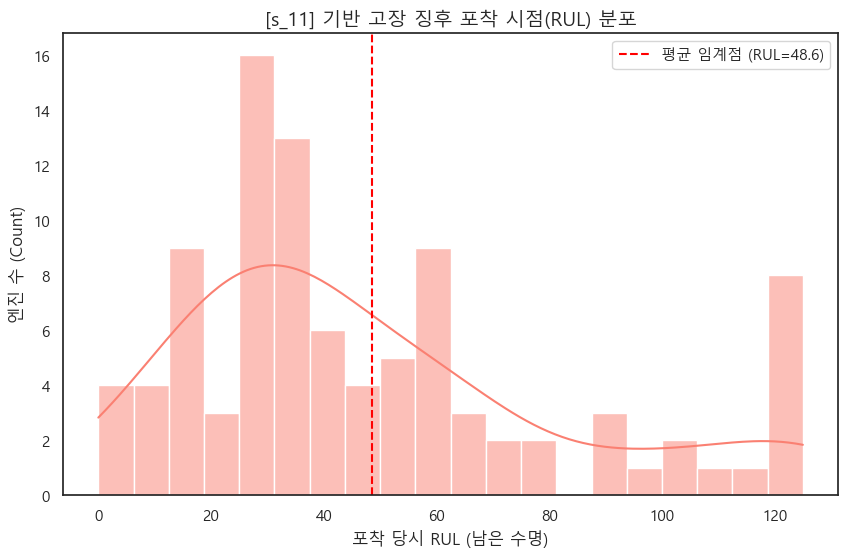

✅ 결론: 고장 징후가 통계적으로 확실해지는 시점은 평균적으로 RUL이 48.6 남았을 때입니다. ㅋ


In [51]:
import pymannkendall as mk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_rolling_threshold(df, target_sensor='s_11', window_size=30, threshold=0.8):
    breakthrough_ruls = []

    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit].copy()
        values = unit_data[target_sensor].values
        ruls = unit_data['RUL'].values
        
        # 윈도우를 밀면서 Tau 계산 ㅋ
        for i in range(len(values) - window_size + 1):
            window = values[i : i + window_size]
            res = mk.original_test(window)
            
            # Tau가 임계점을 돌파하는 첫 순간 포착 ㅋ
            if abs(res.Tau) >= threshold:
                breakthrough_ruls.append(ruls[i + window_size - 1])
                break # 해당 엔진은 포착 완료 ㅋ
    
    # 결과 시각화 ㅋ
    plt.figure(figsize=(10, 6))
    sns.histplot(breakthrough_ruls, kde=True, color='salmon', bins=20)
    avg_break = np.mean(breakthrough_ruls)
    plt.axvline(avg_break, color='red', linestyle='--', label=f'평균 임계점 (RUL={avg_break:.1f})')
    
    plt.title(f'[{target_sensor}] 기반 고장 징후 포착 시점(RUL) 분포', fontsize=14)
    plt.xlabel('포착 당시 RUL (남은 수명)')
    plt.ylabel('엔진 수 (Count)')
    plt.legend()
    plt.show()
    
    print(f"✅ 결론: 고장 징후가 통계적으로 확실해지는 시점은 평균적으로 RUL이 {avg_break:.1f} 남았을 때입니다. ㅋ")
    return breakthrough_ruls

# 실행 ㅋ
threshold_results = analyze_rolling_threshold(df_train)

⏳ 센서별 고장 임계점 산출 중...
⏳ 센서 간 반응 시차(Lag) 분석 중...


C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\2553799703.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_RUL_Threshold', y='Sensor', data=df_thresholds, palette='flare', ax=ax1)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_51028\2553799703.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Lag', y='Sensor', data=df_sequence, palette='viridis', ax=ax2)


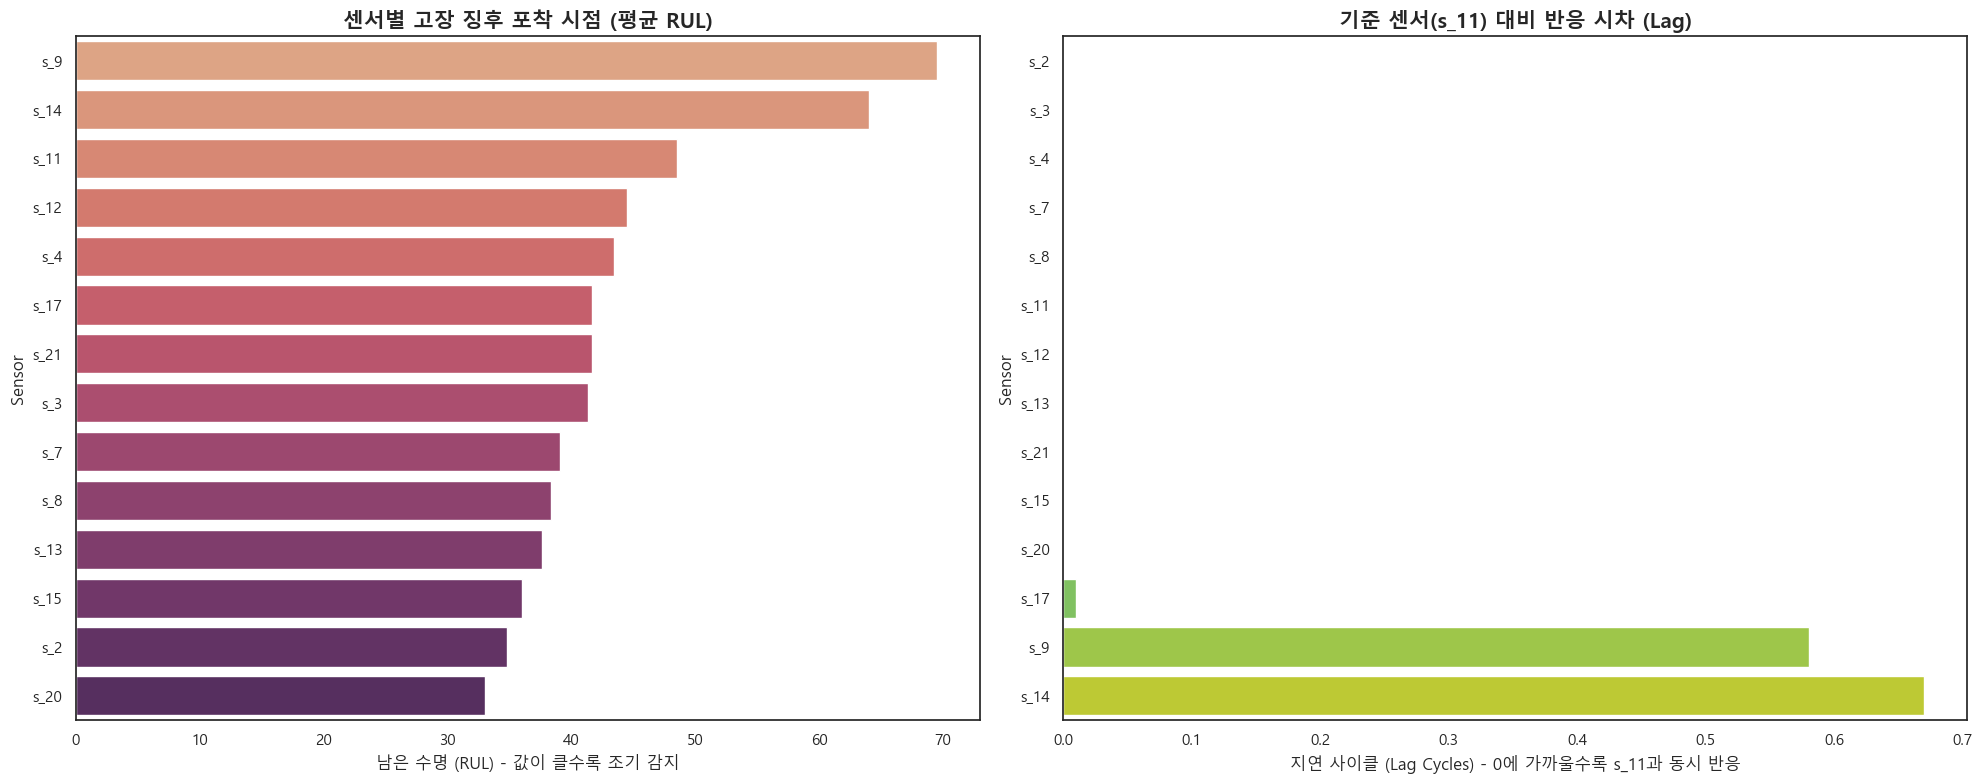

--- [최종 분석 리포트] ---


,Sensor,Avg_RUL_Threshold,Avg_Lag
0,s_9,69.484848,0.58
1,s_14,63.987500,0.67
2,s_11,48.562500,0.00
3,s_12,44.473684,0.00
4,s_4,43.434783,0.00
5,s_17,41.687500,0.01
6,s_21,41.637500,0.00
7,s_3,41.377049,0.00
8,s_7,39.054945,0.00
9,s_8,38.371795,0.00


In [52]:
import pymannkendall as mk
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 분석할 14개 핵심 센서 리스트 ㅋ
sensor_names = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

# ---------------------------------------------------------
# 1. 센서별 고장 임계점(Threshold) 분석
# ---------------------------------------------------------
def analyze_full_thresholds(df, sensors, window_size=30, threshold=0.8):
    threshold_list = []
    print("⏳ 센서별 고장 임계점 산출 중...")

    for sensor in sensors:
        breakthrough_ruls = []
        for unit in df['unit_nr'].unique():
            unit_data = df[df['unit_nr'] == unit]
            values = unit_data[sensor].values
            ruls = unit_data['RUL'].values
            
            for i in range(len(values) - window_size + 1):
                window = values[i : i + window_size]
                # 데이터 변동이 너무 적으면 에러 날 수 있으므로 예외처리 ㅋ
                try:
                    res = mk.original_test(window)
                    if abs(res.Tau) >= threshold:
                        breakthrough_ruls.append(ruls[i + window_size - 1])
                        break
                except: continue
        
        if breakthrough_ruls:
            threshold_list.append({'Sensor': sensor, 'Avg_RUL_Threshold': np.mean(breakthrough_ruls)})

    return pd.DataFrame(threshold_list).sort_values(by='Avg_RUL_Threshold', ascending=False)

# ---------------------------------------------------------
# 2. 전 센서 반응 순서 분석 (상호 시차 분석)
# ---------------------------------------------------------
def analyze_full_sequence(df, sensors, base_sensor='s_11'):
    print("⏳ 센서 간 반응 시차(Lag) 분석 중...")
    sequence_res = []
    
    for sensor in sensors:
        lags = []
        for unit in df['unit_nr'].unique():
            unit_data = df[df['unit_nr'] == unit]
            # 두 센서 간의 시차상관관계 계산 ㅋ
            ccf_values = sm.tsa.stattools.ccf(unit_data[base_sensor], unit_data[sensor], adjusted=False)
            # 최대 상관계수가 나타나는 지점을 시차로 기록 ㅋ
            max_lag = np.argmax(np.abs(ccf_values[:20])) 
            lags.append(max_lag)
        
        sequence_res.append({'Sensor': sensor, 'Avg_Lag': np.mean(lags)})

    return pd.DataFrame(sequence_res).sort_values(by='Avg_Lag')

# --- 실행 및 시각화 ---
df_thresholds = analyze_full_thresholds(df_train, sensor_names)
df_sequence = analyze_full_sequence(df_train, sensor_names)

# 📊 결과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 그래프 1: 센서별 고장 감지 시점 (어떤 센서가 가장 먼저 '눈치' 채나? ㅋ)
sns.barplot(x='Avg_RUL_Threshold', y='Sensor', data=df_thresholds, palette='flare', ax=ax1)
ax1.set_title('센서별 고장 징후 포착 시점 (평균 RUL)', fontsize=15, fontweight='bold')
ax1.set_xlabel('남은 수명 (RUL) - 값이 클수록 조기 감지')

# 그래프 2: s_11 기준 반응 순서 (누가 먼저 변하나? ㅋ)
sns.barplot(x='Avg_Lag', y='Sensor', data=df_sequence, palette='viridis', ax=ax2)
ax2.set_title('기준 센서(s_11) 대비 반응 시차 (Lag)', fontsize=15, fontweight='bold')
ax2.set_xlabel('지연 사이클 (Lag Cycles) - 0에 가까울수록 s_11과 동시 반응')

plt.tight_layout()
plt.show()

# 최종 테이블 출력 ㅋ
print("--- [최종 분석 리포트] ---")
report = pd.merge(df_thresholds, df_sequence, on='Sensor')
display(report)